# Projet 6 - Initiez-vous au MLOps

## EXPLORATORY DATA ANALYSE

Nous allons commencer par analyser les données que nous avons. D'abord nous allons étudier les df de train et de test. Nous regarderons d'abord la shape des df, nous regarderons les colonnes présentent, le type de valeurs présentent et les valeurs possibles dans ces colonnes. Nous regarderons ensuite s'il y a ou non des NaN et leur pourcentage par rapport au total de valeur de la variable. Nous regarderons ensuite si il y a des doublons. Finalement nous identifirons les variables clés qui permettront la jointure entre les df utiles du

In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)   # affiche toutes les colonnes
pd.set_option('display.max_rows', 100)        # affiche jusqu'à 100 lignes (ajuste selon besoin)
pd.set_option('display.width', None)          # n'impose pas de largeur max, s'adapte au contenu


# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

#Missing values visualisation:
import missingno as msno

In [2]:
# List files available
print(os.listdir("../data/"))

app_train = pd.read_csv('../data/application_train.csv')
app_test = pd.read_csv('../data/application_test.csv')
bureau_balance = pd.read_csv('../data/bureau_balance.csv')
bureau = pd.read_csv('../data/bureau.csv')
credit_card_balance = pd.read_csv('../data/credit_card_balance.csv')
installments_payments = pd.read_csv('../data/installments_payments.csv')
pos_cash_balance = pd.read_csv('../data/POS_CASH_balance.csv')
previous_app = pd.read_csv('../data/previous_application.csv')
sample_submission = pd.read_csv('../data/sample_submission.csv')

['application_test.csv', 'HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'application_train.csv', 'bureau.csv', 'previous_application.csv', 'bureau_balance.csv', 'sample_submission.csv']


## 1. EDA structurelle globale (9 tables)

In [3]:
dataframes = {
    "app_train": app_train,
    "app_test": app_test,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_app,
    "credit_card_balance": credit_card_balance,
    "installments_payments": installments_payments,
    "pos_cash_balance": pos_cash_balance,
    "sample_submission": sample_submission
}

for name, dataframe in dataframes.items():
    print(dataframe.shape)

(307511, 122)
(48744, 121)
(1716428, 17)
(27299925, 3)
(1670214, 37)
(3840312, 23)
(13605401, 8)
(10001358, 8)
(48744, 2)


Regardons rapidement le contenu des dfs autre que le df de train et celui de test.

In [4]:
names_to_exclude = ["app_train", "app_test"]
df_annexed = {name: df for name, df in dataframes.items() if name not in names_to_exclude}
for name, dataframe in df_annexed.items():
    print("-" * 100)
    print(f"Table : {name}")
    print("-" * 20)
    print(f'La shape est de : {dataframe.shape}')
    print("-" * 20)
    print(f'La liste des colonnes est : {list(dataframe.columns)}')
    print("-" * 20)
    print(dataframe.isnull().sum())   
    print("-" * 20)
    print(f'nombre de doublons : {dataframe.duplicated().sum()} ')  

----------------------------------------------------------------------------------------------------
Table : bureau
--------------------
La shape est de : (1716428, 17)
--------------------
La liste des colonnes est : ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']
--------------------
SK_ID_CURR                      0
SK_ID_BUREAU                    0
CREDIT_ACTIVE                   0
CREDIT_CURRENCY                 0
DAYS_CREDIT                     0
CREDIT_DAY_OVERDUE              0
DAYS_CREDIT_ENDDATE        105553
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_MAX_OVERDUE    1124488
CNT_CREDIT_PROLONG              0
AMT_CREDIT_SUM                 13
AMT_CREDIT_SUM_DEBT        257669
AMT_CREDIT_SUM

On observe déja plusieurs colonnes portant le même nom entre différents dataframe qui pourrait donc représenter de possible **clé de merge**.

Intéréssons nous maintenant au df **app_train** et **app_test**.

## app_train EDA :

In [5]:
#Training data info:
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

print(f' Duplicates number  : {app_train.duplicated().sum()}')
print('-'*100)
missing_values = missing_values_table(app_train)
with pd.option_context('display.max_rows', None):
    display(missing_values)

#Mission values visualisation:

print('-'*100)
print(app_train.describe())
print('-'*100)
app_train.dtypes.value_counts()


 Duplicates number  : 0
----------------------------------------------------------------------------------------------------
Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4


----------------------------------------------------------------------------------------------------
          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL  \
count  307511.000000  307511.000000  307511.000000      3.075110e+05   
mean   278180.518577       0.080729       0.417052      1.687979e+05   
std    102790.175348       0.272419       0.722121      2.371231e+05   
min    100002.000000       0.000000       0.000000      2.565000e+04   
25%    189145.500000       0.000000       0.000000      1.125000e+05   
50%    278202.000000       0.000000       0.000000      1.471500e+05   
75%    367142.500000       0.000000       1.000000      2.025000e+05   
max    456255.000000       1.000000      19.000000      1.170000e+08   

         AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  \
count  3.075110e+05  307499.000000     3.072330e+05   
mean   5.990260e+05   27108.573909     5.383962e+05   
std    4.024908e+05   14493.737315     3.694465e+05   
min    4.500000e+04    1615.50

float64    65
int64      41
object     16
Name: count, dtype: int64

In [7]:
for col in app_train.columns:
    print(app_train[col].value_counts())

SK_ID_CURR
100002    1
337664    1
337661    1
337660    1
337659    1
         ..
218992    1
218991    1
218990    1
218989    1
456255    1
Name: count, Length: 307511, dtype: int64
TARGET
0    282686
1     24825
Name: count, dtype: int64
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64
CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1
Name: count, dtype: int64
AMT_INCOME_TOTAL
135000.0    35750
112500.0    31019
157500.0    26556
180000.0    24719
90000.0     22483
            ...  
117324.0        1
64584.0         1
142897.5        1
109170.0        1
113062.5        1
Nam

In [8]:
app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

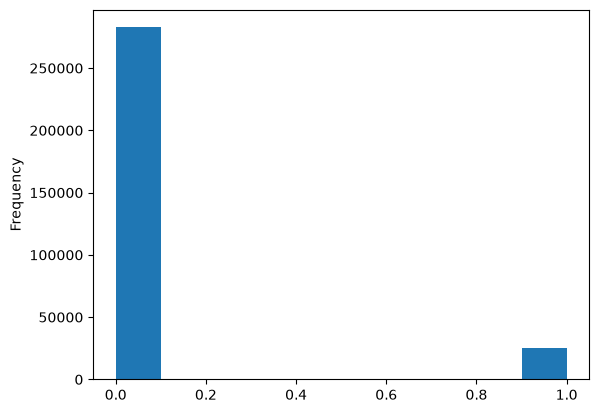

In [9]:
app_train['TARGET'].astype(int).plot.hist();

On observe, au niveau de la target, un important déséquilibre de classe de l'ordre de 1 pour 11,4.

## app_test EDA :

In [10]:
#Testing data info:
print('Training data shape: ', app_test.shape)
app_test.head()

Training data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married

In [11]:
print(f' Duplicates number  : {app_test.duplicated().sum()}')
print('-'*100)
missing_values = missing_values_table(app_test)
with pd.option_context('display.max_rows', None):
    display(missing_values)

#Mission values visualisation:
print('-'*100)
print(app_test.describe())
print('-'*100)
app_test.dtypes.value_counts()


 Duplicates number  : 0
----------------------------------------------------------------------------------------------------
Your selected dataframe has 121 columns.
There are 64 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MODE,33495,68.7
COMMONAREA_MEDI,33495,68.7
COMMONAREA_AVG,33495,68.7
NONLIVINGAPARTMENTS_MEDI,33347,68.4
NONLIVINGAPARTMENTS_AVG,33347,68.4
NONLIVINGAPARTMENTS_MODE,33347,68.4
FONDKAPREMONT_MODE,32797,67.3
LIVINGAPARTMENTS_MODE,32780,67.2
LIVINGAPARTMENTS_MEDI,32780,67.2
LIVINGAPARTMENTS_AVG,32780,67.2


----------------------------------------------------------------------------------------------------
          SK_ID_CURR  CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT  \
count   48744.000000  48744.000000      4.874400e+04  4.874400e+04   
mean   277796.676350      0.397054      1.784318e+05  5.167404e+05   
std    103169.547296      0.709047      1.015226e+05  3.653970e+05   
min    100001.000000      0.000000      2.694150e+04  4.500000e+04   
25%    188557.750000      0.000000      1.125000e+05  2.606400e+05   
50%    277549.000000      0.000000      1.575000e+05  4.500000e+05   
75%    367555.500000      1.000000      2.250000e+05  6.750000e+05   
max    456250.000000     20.000000      4.410000e+06  2.245500e+06   

         AMT_ANNUITY  AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  \
count   48720.000000     4.874400e+04                48744.000000   
mean    29426.240209     4.626188e+05                    0.021226   
std     16016.368315     3.367102e+05                    0.01

float64    65
int64      40
object     16
Name: count, dtype: int64

In [12]:
#Possible values for each column :
for col in app_test.columns:
    print(app_test[col].value_counts())

SK_ID_CURR
100001    1
336464    1
336413    1
336418    1
336426    1
         ..
217143    1
217148    1
217155    1
217162    1
456250    1
Name: count, Length: 48744, dtype: int64
NAME_CONTRACT_TYPE
Cash loans         48305
Revolving loans      439
Name: count, dtype: int64
CODE_GENDER
F    32678
M    16066
Name: count, dtype: int64
FLAG_OWN_CAR
N    32311
Y    16433
Name: count, dtype: int64
FLAG_OWN_REALTY
Y    33658
N    15086
Name: count, dtype: int64
CNT_CHILDREN
0     34685
1      9504
2      3949
3       535
4        49
5        12
8         3
6         3
11        2
7         1
20        1
Name: count, dtype: int64
AMT_INCOME_TOTAL
135000.0    5562
112500.0    4851
157500.0    4435
180000.0    4205
225000.0    3764
            ... 
114219.0       1
84717.0        1
91935.0        1
146475.0       1
161244.0       1
Name: count, Length: 606, dtype: int64
AMT_CREDIT
450000.0     2118
225000.0     1836
675000.0     1426
360000.0      839
900000.0      835
             ... 
146

## EDA des csv annexes : 

In [13]:
def summarize_table(df, name):
    """
    Résumé rapide et structuré d'une table pour l'EDA multi-tables.
    Retourne un dict avec les infos clés, affichées de façon lisible.
    """

    print(f"{'='*80}")
    print(f"TABLE : {name}")
    print(f"{'='*80}")

    # --- 1. Shape et mémoire ---
    print(f"\nShape : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
    print(f"Mémoire utilisée : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # --- 2. Types de colonnes ---
    dtype_counts = df.dtypes.value_counts()
    print(f"\nTypes de colonnes :")
    for dtype, count in dtype_counts.items():
        print(f"  - {dtype} : {count}")

    # --- 3. Granularité : quelles colonnes ID sont présentes, et sont-elles uniques ? ---
    id_cols = [col for col in df.columns if col in
               ["SK_ID_CURR", "SK_ID_PREV", "SK_ID_BUREAU"]]
    print(f"\nColonnes d'identifiants présentes : {id_cols}")
    for id_col in id_cols:
        n_unique = df[id_col].nunique()
        n_total = len(df)
        is_pk = n_unique == n_total
        print(f"  - {id_col} : {n_unique:,} valeurs uniques sur {n_total:,} lignes "
              f"({'clé primaire probable' if is_pk else 'clé étrangère (répétée)'})")
        if not is_pk:
            avg_rows = n_total / n_unique
            max_rows = df[id_col].value_counts().max()
            print(f"    -> en moyenne {avg_rows:.1f} lignes par {id_col}, max {max_rows} lignes pour un même {id_col}")

    # --- 4. Doublons de lignes complètes ---
    n_dup = df.duplicated().sum()
    print(f"\nLignes dupliquées (toutes colonnes identiques) : {n_dup:,} ({100*n_dup/len(df):.2f}%)")

    # --- 5. Valeurs manquantes ---
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    missing_df = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct.round(4)})
    missing_df = missing_df[missing_df["n_missing"] > 0].sort_values("pct_missing", ascending=False)
    print(f"\nColonnes avec valeurs manquantes ({len(missing_df)}/{df.shape[1]}) :")
    if len(missing_df) > 0:
        display(missing_df)
    else:
        print("  Aucune valeur manquante.")

    # --- 6. Colonnes catégorielles : cardinalité ---
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    print(f"\nColonnes catégorielles ({len(cat_cols)}) :")
    if len(cat_cols) > 0:
        cat_info = pd.DataFrame({
            "n_unique": [df[col].nunique() for col in cat_cols],
            "top_value": [df[col].mode()[0] if not df[col].mode().empty else None for col in cat_cols],
            "top_freq_pct": [round(100 * df[col].value_counts(normalize=True).iloc[0], 1) for col in cat_cols],
        }, index=cat_cols).sort_values("n_unique", ascending=False)
        display(cat_info)
    else:
        print("  Aucune colonne catégorielle.")

    # --- 7. Colonnes quasi-constantes (numériques ET catégorielles) ---
    quasi_constant = []
    for col in df.columns:
        freq = df[col].value_counts(normalize=True, dropna=True)
        if len(freq) > 0 and freq.iloc[0] >= 0.99:
            quasi_constant.append(col)
    print(f"\nColonnes quasi-constantes (>99% même valeur) : {quasi_constant if quasi_constant else 'aucune'}")

    # --- 8. Colonnes numériques avec valeurs négatives suspectes (souvent DAYS_*) ---
    days_cols = [col for col in df.columns if "DAYS" in col.upper()]
    if days_cols:
        print(f"\nColonnes temporelles (DAYS_*) à vérifier pour anomalies :")
        for col in days_cols:
            print(f"  - {col} : min={df[col].min()}, max={df[col].max()}")

    print()
    return {
        "shape": df.shape,
        "id_cols": id_cols,
        "n_duplicates": n_dup,
        "missing_summary": missing_df,
        "cat_summary": cat_info if len(cat_cols) > 0 else None,
        "quasi_constant_cols": quasi_constant,
    }

In [14]:
dataframes = {
    "app_train": app_train,
    "app_test": app_test,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_app,
    "credit_card_balance": credit_card_balance,
    "installments_payments": installments_payments,
    "pos_cash_balance": pos_cash_balance,
    "sample_submission": sample_submission
}
summaries = {}
for name, df in dataframes.items():
    summaries[name] = summarize_table(df, name)

TABLE : app_train

Shape : 307,511 lignes x 122 colonnes
Mémoire utilisée : 504.99 MB

Types de colonnes :
  - float64 : 65
  - int64 : 41
  - object : 16

Colonnes d'identifiants présentes : ['SK_ID_CURR']
  - SK_ID_CURR : 307,511 valeurs uniques sur 307,511 lignes (clé primaire probable)

Lignes dupliquées (toutes colonnes identiques) : 0 (0.00%)

Colonnes avec valeurs manquantes (67/122) :


,n_missing,pct_missing
COMMONAREA_MEDI,214865,69.8723
COMMONAREA_AVG,214865,69.8723
COMMONAREA_MODE,214865,69.8723
NONLIVINGAPARTMENTS_MEDI,213514,69.4330
NONLIVINGAPARTMENTS_MODE,213514,69.4330
NONLIVINGAPARTMENTS_AVG,213514,69.4330
FONDKAPREMONT_MODE,210295,68.3862
LIVINGAPARTMENTS_MODE,210199,68.3550
LIVINGAPARTMENTS_MEDI,210199,68.3550
LIVINGAPARTMENTS_AVG,210199,68.3550



Colonnes catégorielles (16) :


,n_unique,top_value,top_freq_pct
ORGANIZATION_TYPE,58,Business Entity Type 3,22.1
OCCUPATION_TYPE,18,Laborers,26.1
NAME_INCOME_TYPE,8,Working,51.6
NAME_TYPE_SUITE,7,Unaccompanied,81.2
WEEKDAY_APPR_PROCESS_START,7,TUESDAY,17.5
WALLSMATERIAL_MODE,7,Panel,43.7
NAME_FAMILY_STATUS,6,Married,63.9
NAME_HOUSING_TYPE,6,House / apartment,88.7
NAME_EDUCATION_TYPE,5,Secondary / secondary special,71.0
FONDKAPREMONT_MODE,4,reg oper account,75.9



Colonnes quasi-constantes (>99% même valeur) : ['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY']

Colonnes temporelles (DAYS_*) à vérifier pour anomalies :
  - DAYS_BIRTH : min=-25229, max=-7489
  - DAYS_EMPLOYED : min=-17912, max=365243
  - DAYS_REGISTRATION : min=-24672.0, max=0.0
  - DAYS_ID_PUBLISH : min=-7197, max=0
  - DAYS_LAST_PHONE_CHANGE : min=-4292.0, max=0.0

TABLE : app_test

Shape : 48,744 lignes x 121 colonnes
Mémoire utilisée : 79.69 MB

Types de colonnes :
  - float64 : 65
  - int64 : 40
  - object : 16

Colonnes d'identifiants présentes : ['SK_ID_CURR']
  - SK_ID_CURR : 48,744 valeurs uniques sur 48,744 lignes (cl

...


Colonnes catégorielles (0) :
  Aucune colonne catégorielle.

Colonnes quasi-constantes (>99% même valeur) : aucune

Colonnes temporelles (DAYS_*) à vérifier pour anomalies :
  - DAYS_INSTALMENT : min=-2922.0, max=-1.0
  - DAYS_ENTRY_PAYMENT : min=-4921.0, max=-1.0

TABLE : pos_cash_balance

Shape : 10,001,358 lignes x 8 colonnes
Mémoire utilisée : 1060.95 MB

Types de colonnes :
  - int64 : 5
  - float64 : 2
  - object : 1

Colonnes d'identifiants présentes : ['SK_ID_PREV', 'SK_ID_CURR']
  - SK_ID_PREV : 936,325 valeurs uniques sur 10,001,358 lignes (clé étrangère (répétée))
    -> en moyenne 10.7 lignes par SK_ID_PREV, max 96 lignes pour un même SK_ID_PREV
  - SK_ID_CURR : 337,252 valeurs uniques sur 10,001,358 lignes (clé étrangère (répétée))
    -> en moyenne 29.7 lignes par SK_ID_CURR, max 295 lignes pour un même SK_ID_CURR

Lignes dupliquées (toutes colonnes identiques) : 0 (0.00%)

Colonnes avec valeurs manquantes (2/8) :


,n_missing,pct_missing
CNT_INSTALMENT_FUTURE,26087,0.2608
CNT_INSTALMENT,26071,0.2607



Colonnes catégorielles (1) :


,n_unique,top_value,top_freq_pct
NAME_CONTRACT_STATUS,9,Active,91.5



Colonnes quasi-constantes (>99% même valeur) : aucune

TABLE : sample_submission

Shape : 48,744 lignes x 2 colonnes
Mémoire utilisée : 0.74 MB

Types de colonnes :
  - int64 : 1
  - float64 : 1

Colonnes d'identifiants présentes : ['SK_ID_CURR']
  - SK_ID_CURR : 48,744 valeurs uniques sur 48,744 lignes (clé primaire probable)

Lignes dupliquées (toutes colonnes identiques) : 0 (0.00%)

Colonnes avec valeurs manquantes (0/2) :
  Aucune valeur manquante.

Colonnes catégorielles (0) :
  Aucune colonne catégorielle.

Colonnes quasi-constantes (>99% même valeur) : ['TARGET']



## 3. Visualisation des patterns de valeurs manquantes (missingno)

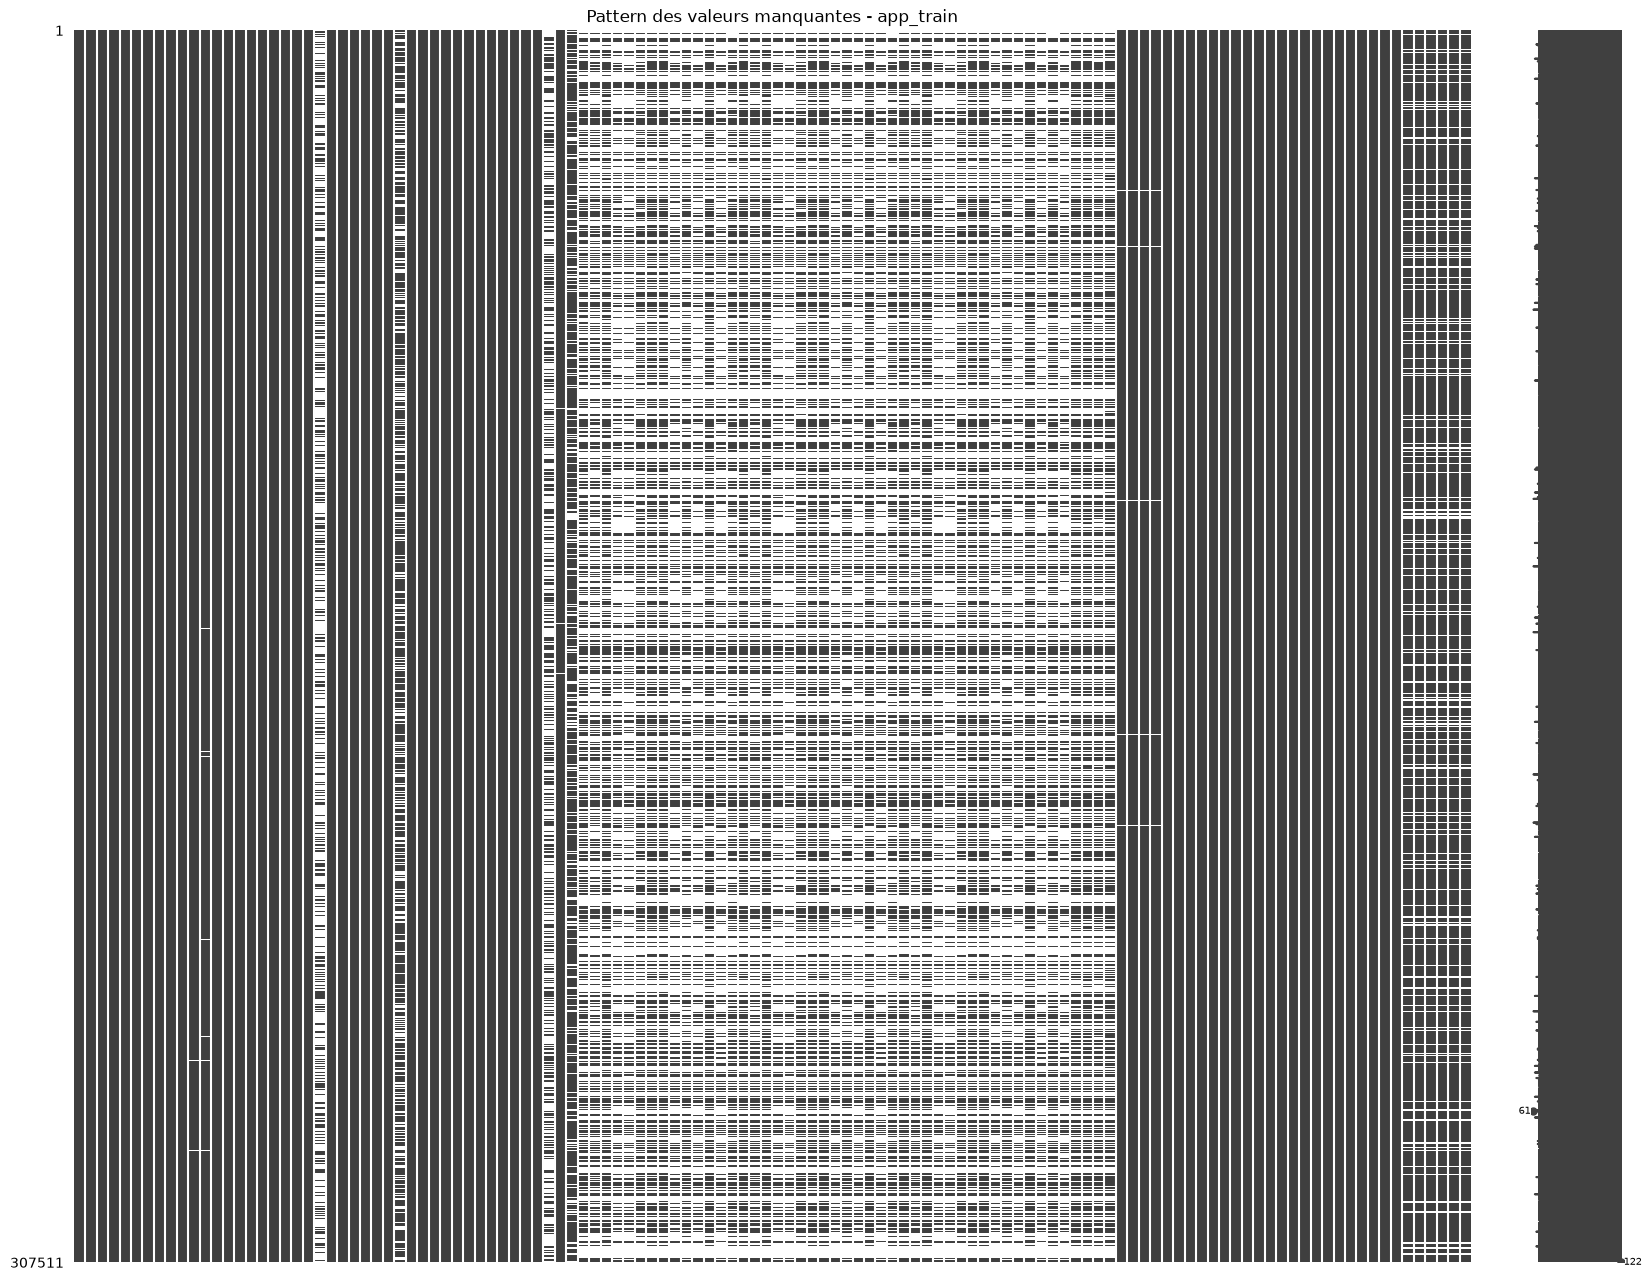

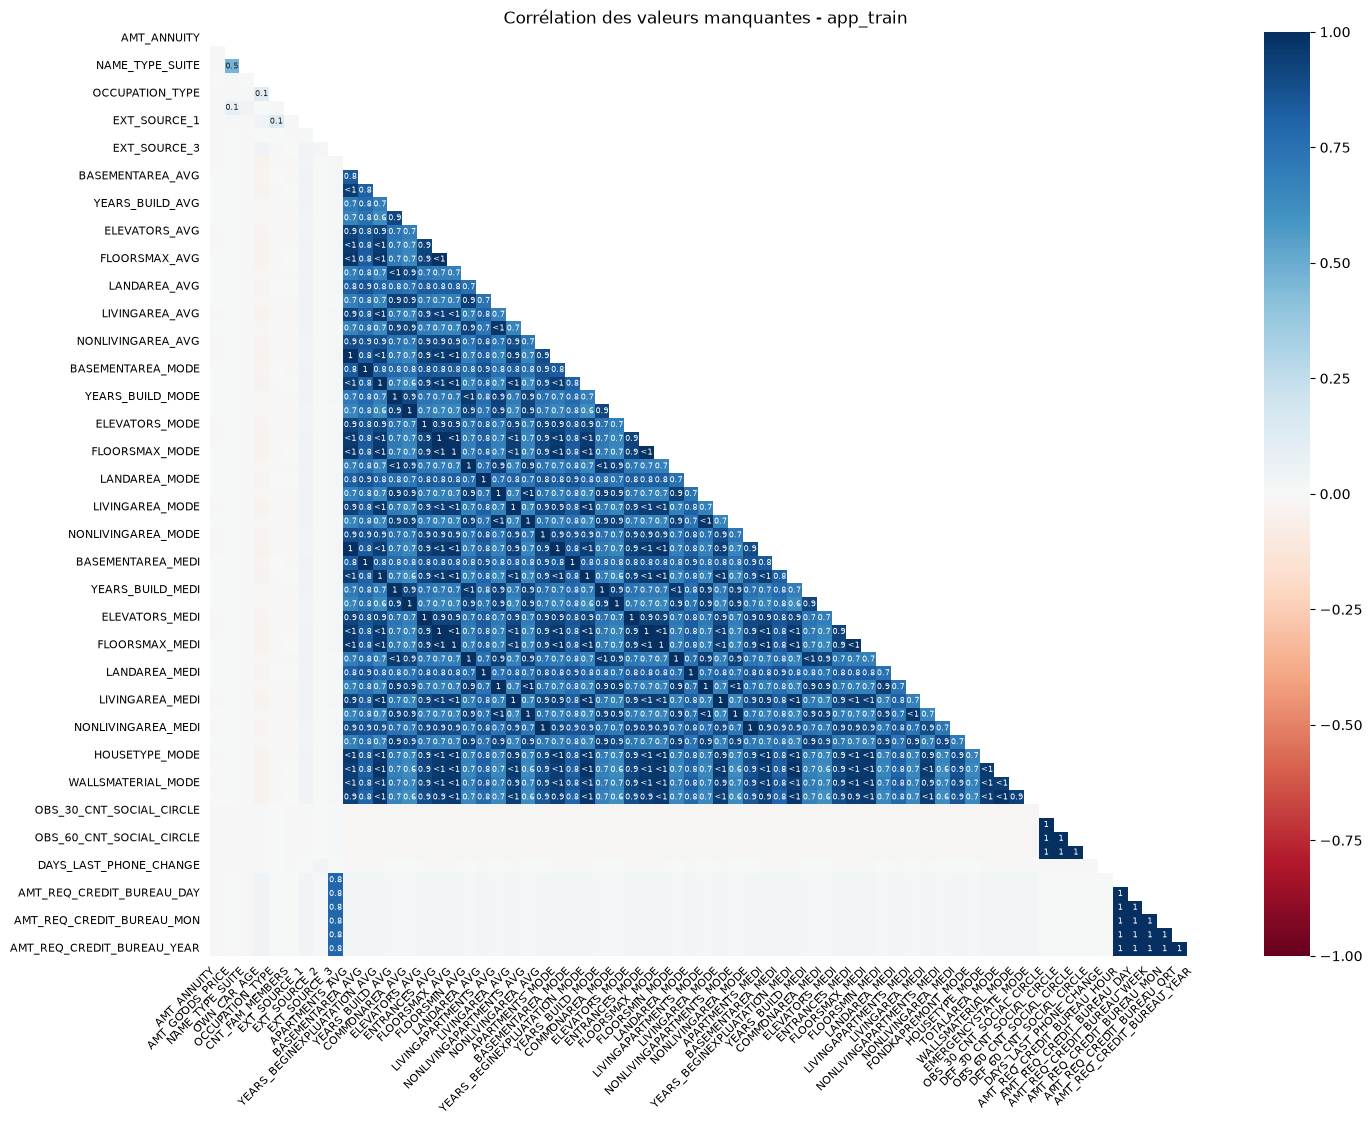

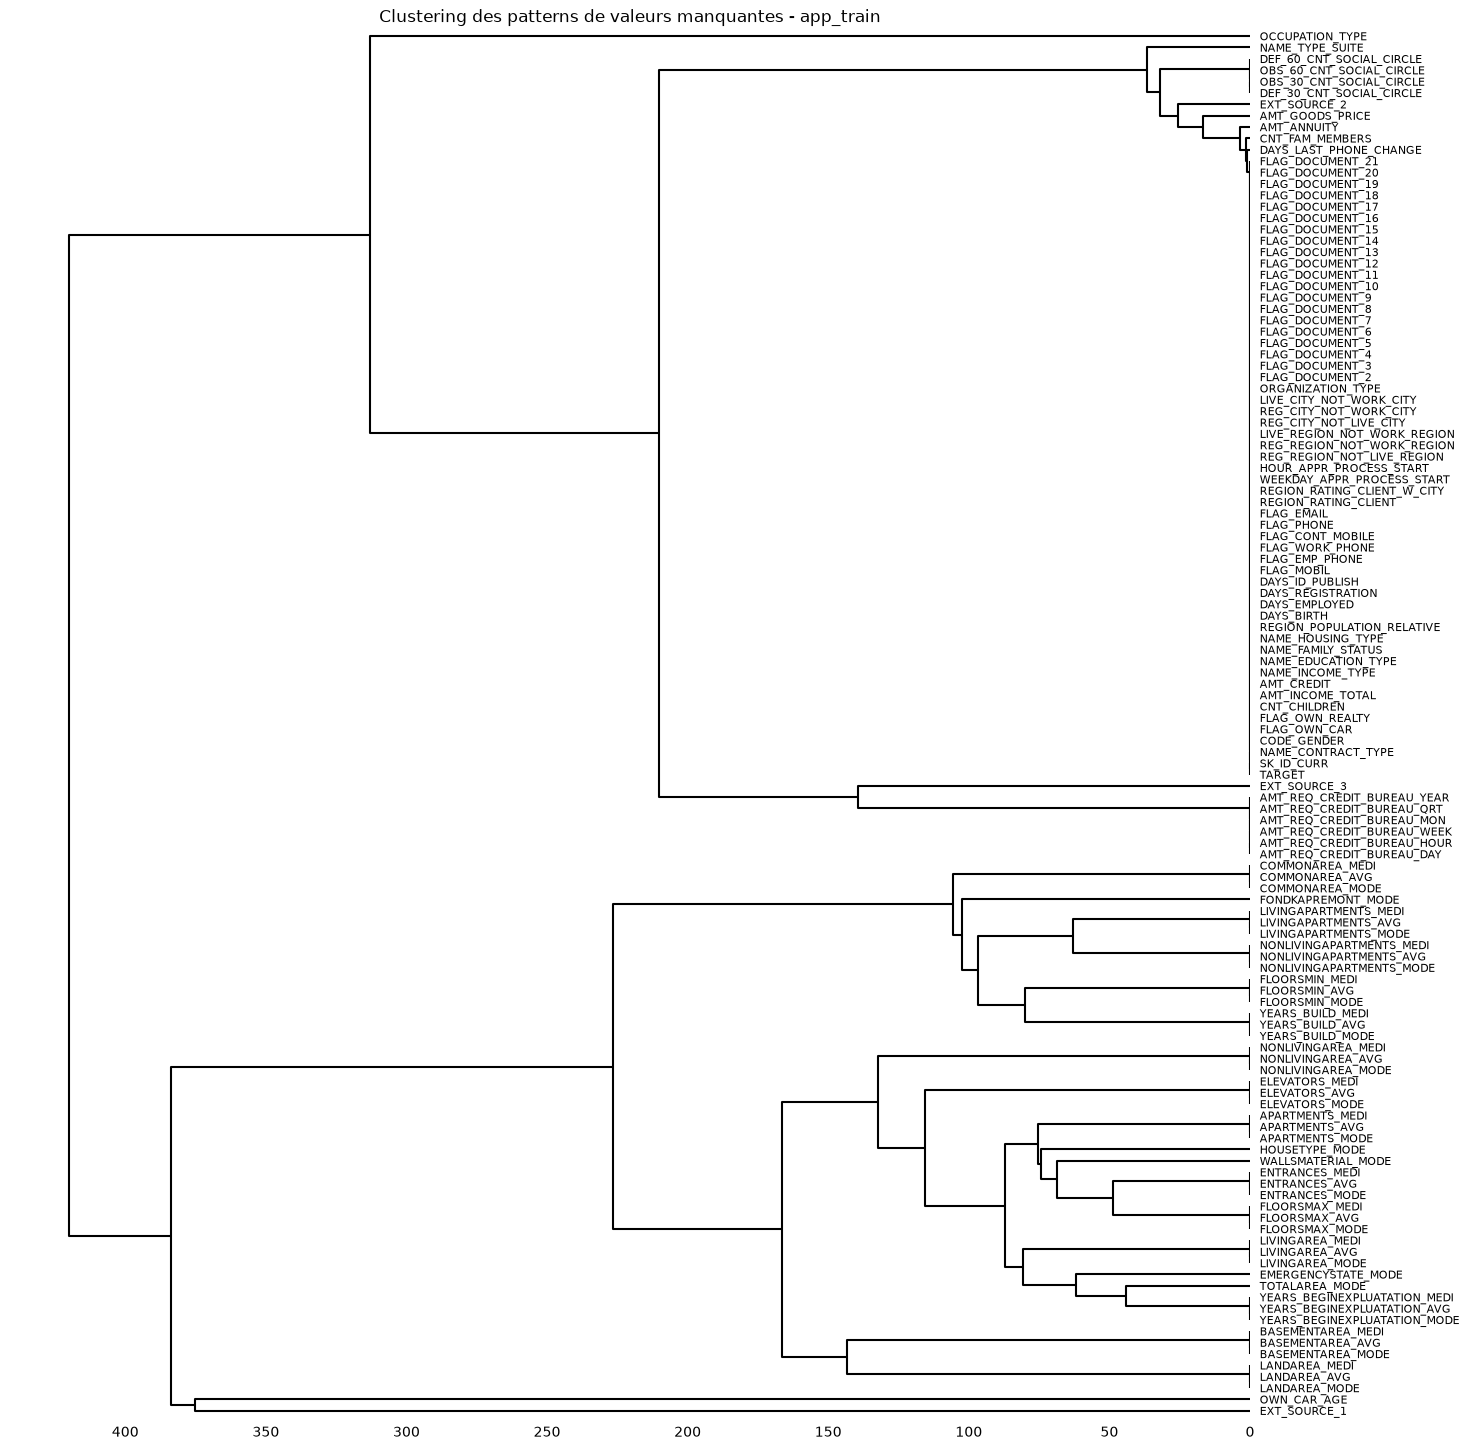

In [15]:
# --- 1. Matrix : vue d'ensemble ligne par ligne ---
# Chaque ligne blanche = une valeur manquante à cette position
# Utile pour repérer si les NaN sont répartis aléatoirement ou par blocs
msno.matrix(app_train, figsize=(20, 16), fontsize=8)
plt.title("Pattern des valeurs manquantes - app_train")
plt.show()

# --- 2. Heatmap : corrélation entre les NaN de différentes colonnes ---
# Une corrélation proche de 1 entre deux colonnes = elles sont manquantes ensemble
msno.heatmap(app_train, figsize=(16, 12), fontsize=8)
plt.title("Corrélation des valeurs manquantes - app_train")
plt.show()

# --- 3. Dendrogram : clustering hiérarchique des colonnes selon leur pattern de missing ---
# Regroupe les colonnes qui partagent exactement le même pattern de NaN
msno.dendrogram(app_train, figsize=(16, 18), fontsize=8)
plt.title("Clustering des patterns de valeurs manquantes - app_train")
plt.show()

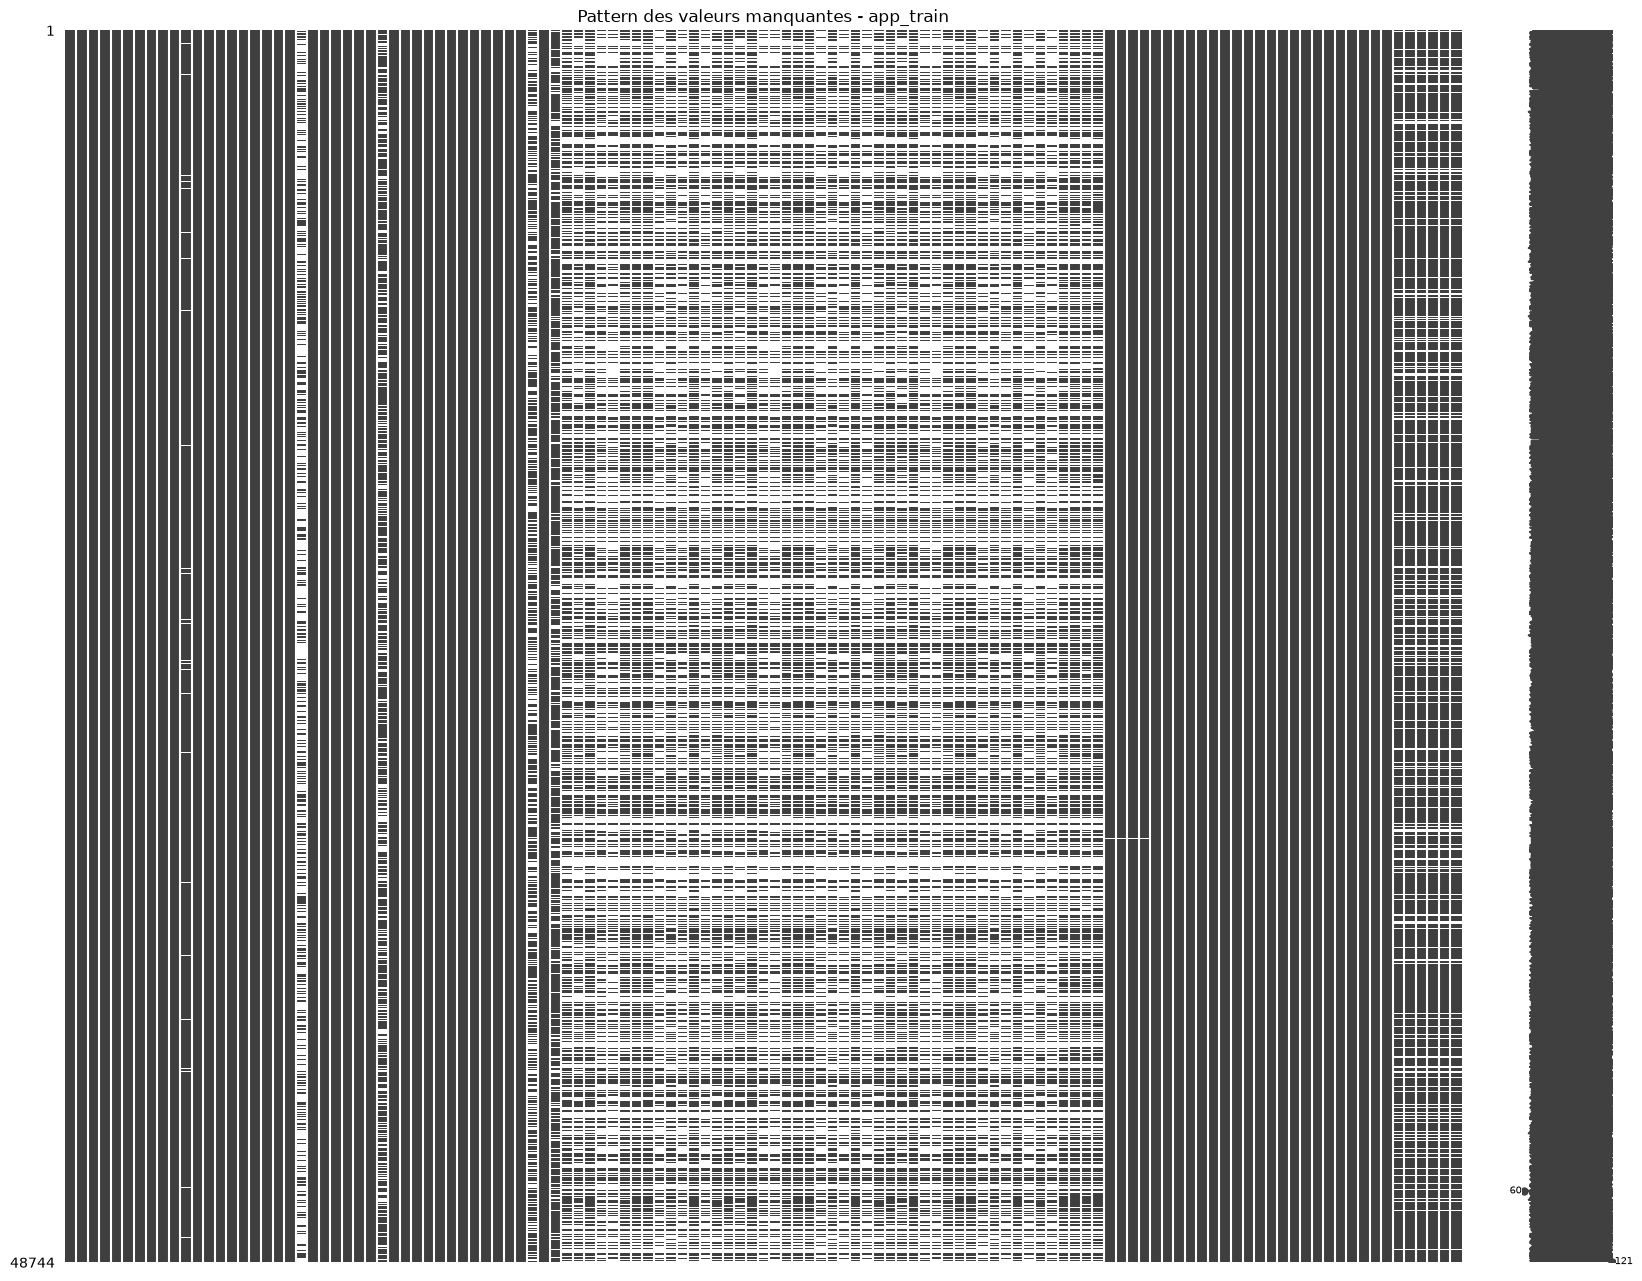

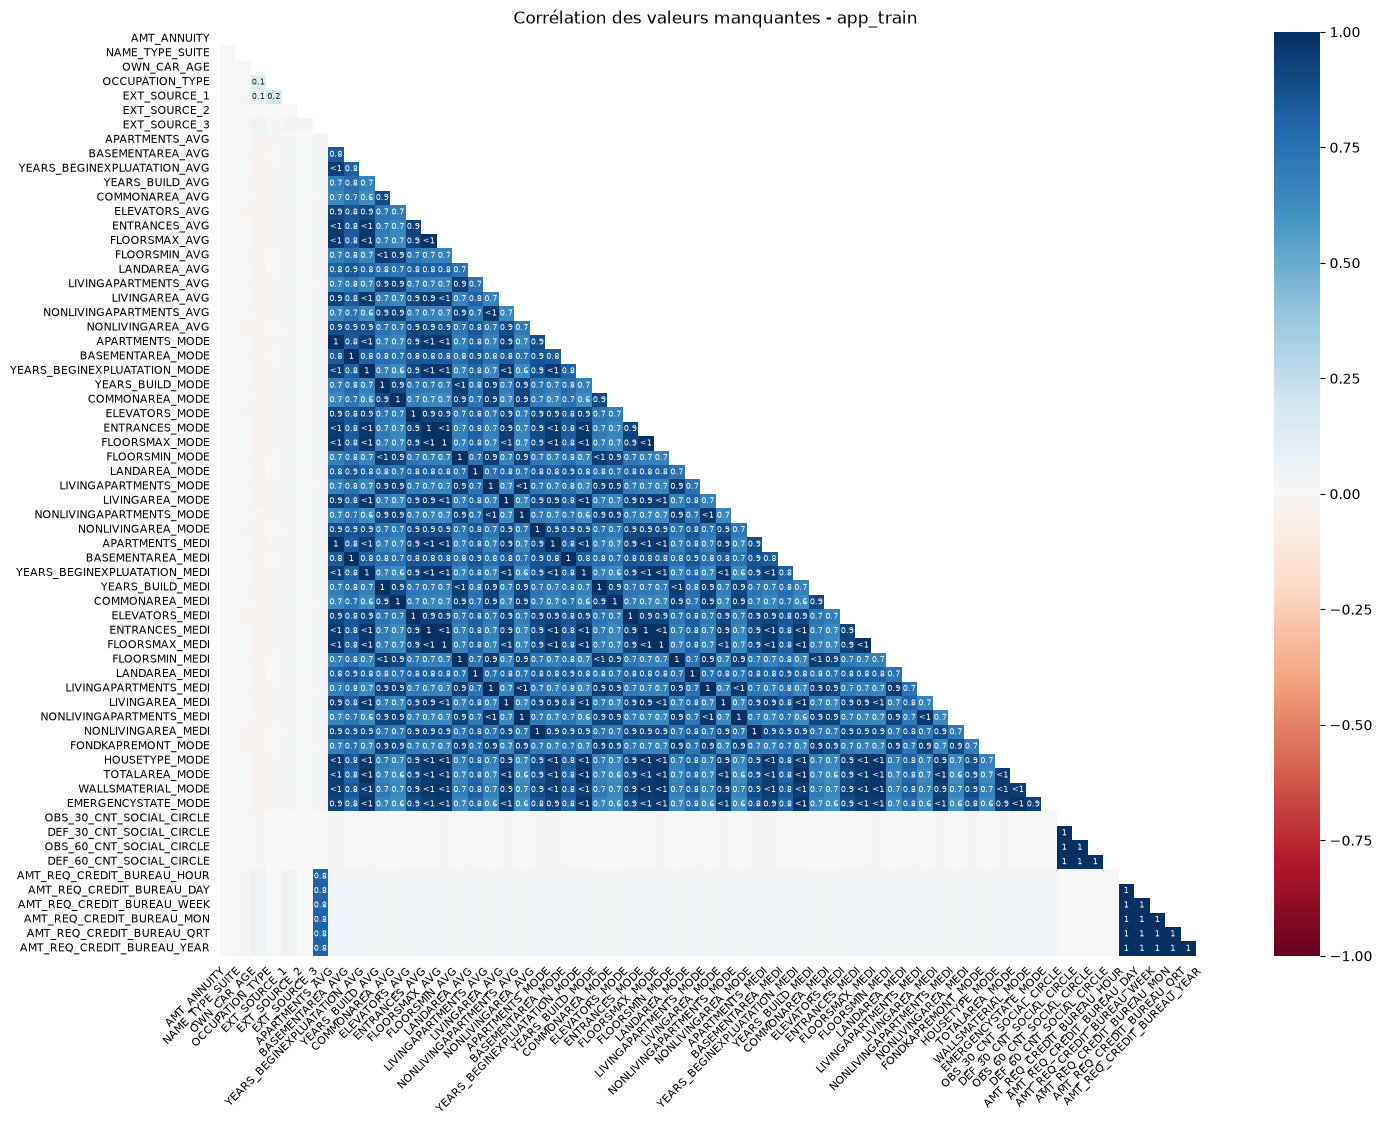

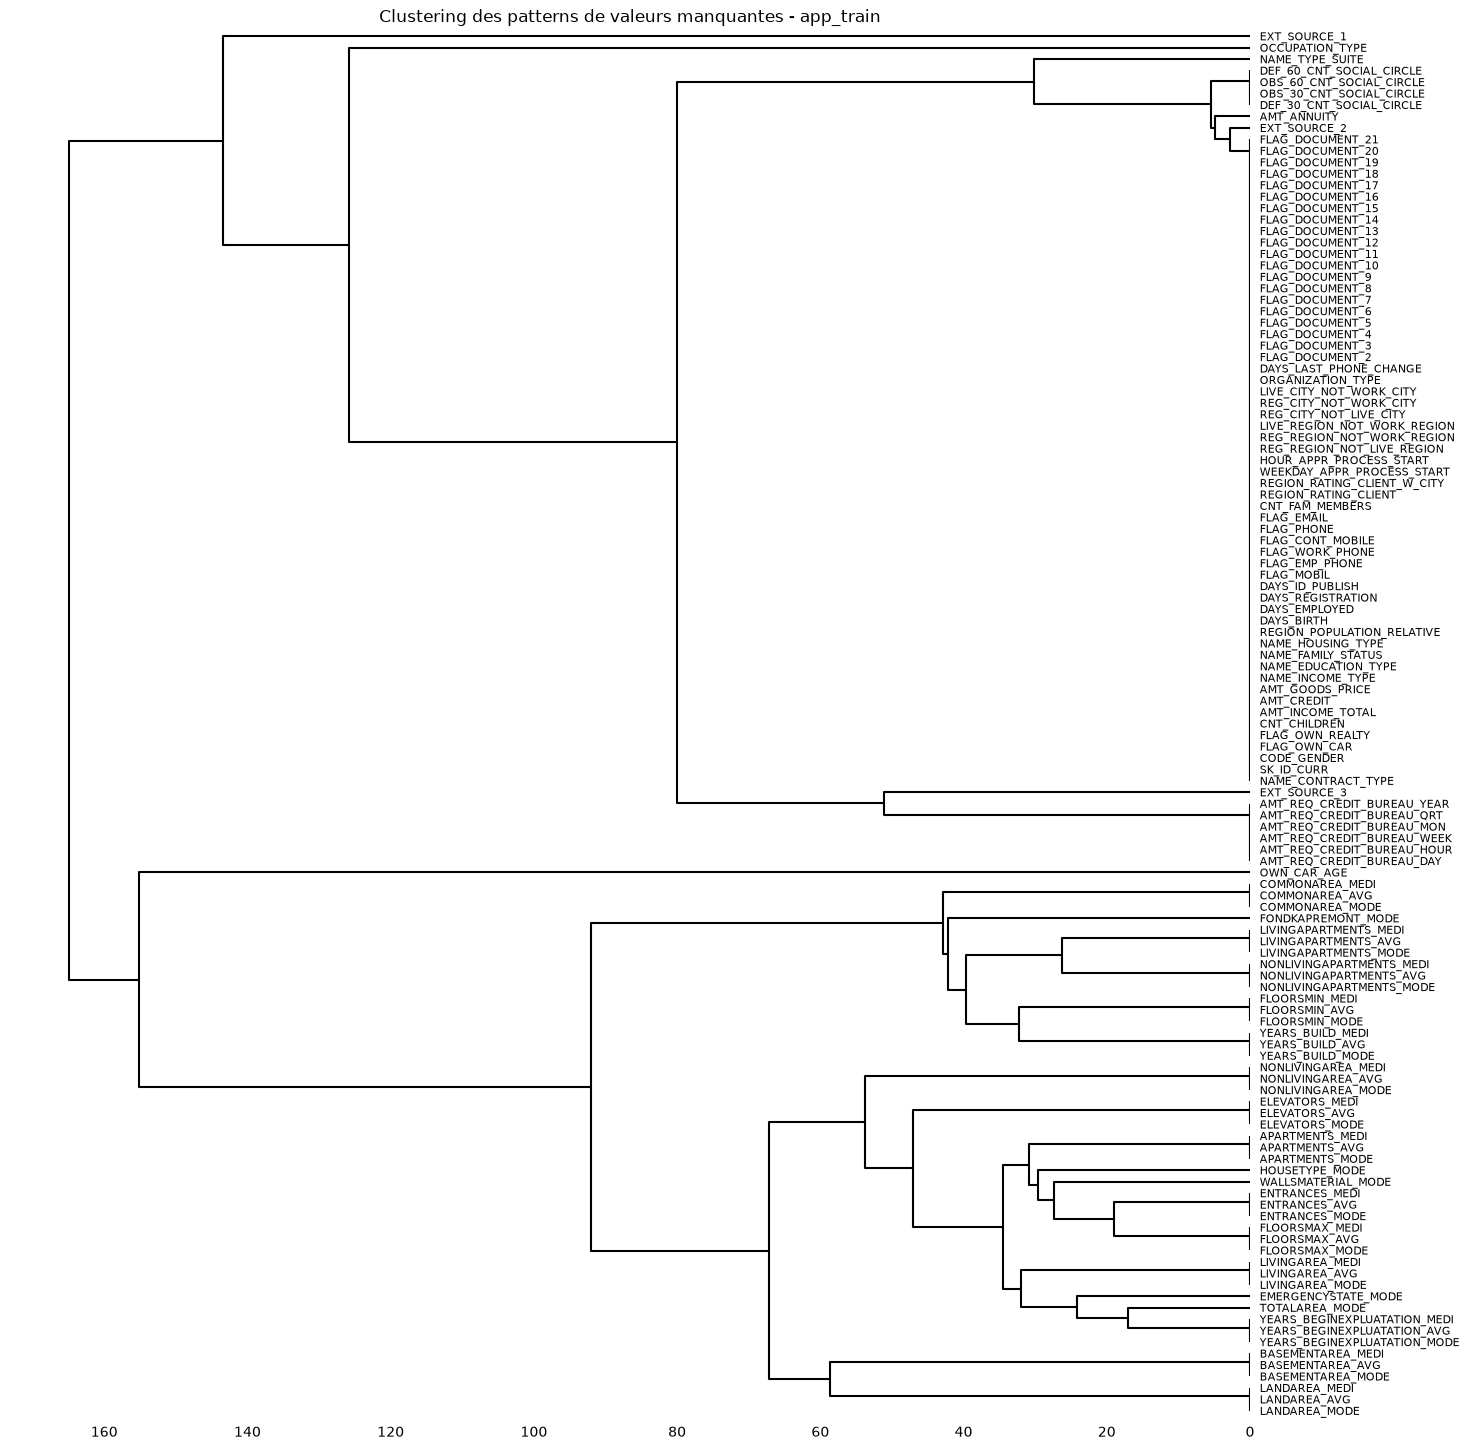

In [16]:
# --- 1. Matrix : vue d'ensemble ligne par ligne ---
# Chaque ligne blanche = une valeur manquante à cette position
# Utile pour repérer si les NaN sont répartis aléatoirement ou par blocs
msno.matrix(app_test, figsize=(20, 16), fontsize=8)
plt.title("Pattern des valeurs manquantes - app_train")
plt.show()

# --- 2. Heatmap : corrélation entre les NaN de différentes colonnes ---
# Une corrélation proche de 1 entre deux colonnes = elles sont manquantes ensemble
msno.heatmap(app_test, figsize=(16, 12), fontsize=8)
plt.title("Corrélation des valeurs manquantes - app_train")
plt.show()

# --- 3. Dendrogram : clustering hiérarchique des colonnes selon leur pattern de missing ---
# Regroupe les colonnes qui partagent exactement le même pattern de NaN
msno.dendrogram(app_test, figsize=(16, 18), fontsize=8)
plt.title("Clustering des patterns de valeurs manquantes - app_train")
plt.show()

## Bloc 2 : Détection et traitement des anomalies

Démarche suivie pour chaque colonne suspecte repérée :
1. **Détecter** (scan statistique automatique)
2. **Comprendre** (investigation manuelle : code sentinelle répété ? outlier légitime ?)
3. **Traiter** (flag + NaN si code sentinelle, capping/rien si outlier statistique légitime)


### 2.1 Scan systématique (détection statistique automatique)

In [17]:
def scan_anomalies(df, iqr_multiplier=3, modified_z_threshold=3.5,
                    constant_threshold=0.99, missing_threshold=0.4):
    """
    Scanne un DataFrame pour détecter automatiquement :
    - les colonnes numériques avec des valeurs extrêmes (IQR + Z-score modifié robuste)
    - un comparatif des lignes détectées comme outliers par les deux méthodes simultanément
    - les colonnes quasi-constantes
    - les colonnes avec un taux de valeurs manquantes élevé

    Le Z-score modifié (Iglewicz & Hoaglin) est basé sur la médiane et la MAD
    plutôt que sur la moyenne et l'écart-type, ce qui le rend robuste
    aux valeurs extrêmes qui faussent le Z-score classique.
    """

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    outlier_report = []
    constant_report = []
    missing_report = []
    row_level_flags = {}

    for col in df.columns:

        # --- Missing values ---
        missing_rate = df[col].isnull().mean()
        if missing_rate > missing_threshold:
            missing_report.append({
                "column": col,
                "missing_rate": round(missing_rate, 3),
                "n_missing": df[col].isnull().sum()
            })

        # --- Quasi-constant ---
        value_counts = df[col].value_counts(normalize=True, dropna=True)
        if len(value_counts) > 0:
            dominant_freq = value_counts.iloc[0]
            if dominant_freq >= constant_threshold:
                constant_report.append({
                    "column": col,
                    "dominant_value": value_counts.index[0],
                    "dominant_freq": round(dominant_freq, 4),
                    "n_unique": df[col].nunique()
                })

        # --- Outliers : IQR + Z-score modifié (robuste) ---
        if col in numeric_cols:
            series = df[col].dropna()
            if series.nunique() <= 2:
                continue  # colonnes binaires déjà couvertes par le check "quasi-constant"

            # IQR
            q1, q3 = series.quantile(0.25), series.quantile(0.75)
            iqr = q3 - q1
            if iqr == 0:
                continue
            lower_bound = q1 - iqr_multiplier * iqr
            upper_bound = q3 + iqr_multiplier * iqr
            mask_iqr = (series < lower_bound) | (series > upper_bound)

            # Z-score modifié (médiane + MAD)
            median = series.median()
            mad = np.median(np.abs(series - median))
            if mad == 0:
                mask_mod_z = pd.Series(False, index=series.index)
            else:
                modified_z = 0.6745 * (series - median) / mad
                mask_mod_z = np.abs(modified_z) > modified_z_threshold

            # Comparatif : lignes détectées par les deux méthodes à la fois
            mask_both = mask_iqr & mask_mod_z
            n_both = mask_both.sum()

            if mask_iqr.sum() > 0 or mask_mod_z.sum() > 0:
                outlier_report.append({
                    "column": col,
                    "n_outliers_iqr": mask_iqr.sum(),
                    "n_outliers_modified_z": mask_mod_z.sum(),
                    "n_outliers_both_methods": n_both,
                    "pct_agreement": round(100 * n_both / max(mask_iqr.sum(), mask_mod_z.sum(), 1), 1),
                    "min": series.min(),
                    "max": series.max(),
                })

            row_level_flags[col] = {"iqr": mask_iqr, "modified_z": mask_mod_z, "both": mask_both}

    results = {
        "outliers": pd.DataFrame(outlier_report).sort_values("n_outliers_both_methods", ascending=False) if outlier_report else pd.DataFrame(),
        "quasi_constant": pd.DataFrame(constant_report).sort_values("dominant_freq", ascending=False) if constant_report else pd.DataFrame(),
        "high_missing": pd.DataFrame(missing_report).sort_values("missing_rate", ascending=False) if missing_report else pd.DataFrame(),
        "row_level_flags": row_level_flags,
    }

    return results


def get_flagged_rows(df, results, column, method="both"):
    """
    Extrait les lignes du DataFrame original flaggées comme outliers pour une colonne donnée.
    method: 'iqr', 'modified_z', ou 'both' (intersection des deux méthodes)
    """
    mask = results["row_level_flags"][column][method]
    return df.loc[mask.index[mask]]

In [18]:
results_app_train = scan_anomalies(app_train)
results_app_test = scan_anomalies(app_test)
results_bureau = scan_anomalies(bureau)
results_previous = scan_anomalies(previous_app)
results_bureau_balance = scan_anomalies(bureau_balance)
results_credit_card_balance = scan_anomalies(credit_card_balance)
results_installments_payments = scan_anomalies(installments_payments)
results_pos_cash_balance = scan_anomalies(pos_cash_balance)



print("=== app_train ===")
display(results_app_train["outliers"])

print("=== bureau ===")
display(results_bureau["outliers"])

print("=== previous_application ===")
display(results_previous["outliers"])

print("=== bureau_balance ===")
display(results_bureau_balance["outliers"])

print("=== credit_card_balance ===")
display(results_credit_card_balance["outliers"])

print("=== installments_payments ===")
display(results_installments_payments["outliers"])

print("=== pos_cash_balance ===")
display(results_pos_cash_balance["outliers"])


=== app_train ===


,column,n_outliers_iqr,n_outliers_modified_z,n_outliers_both_methods,pct_agreement,min,max
6,DAYS_EMPLOYED,59624,70122,59624,85.0,-17912.00000,3.652430e+05
36,NONLIVINGAREA_MODE,11328,53064,11328,21.3,0.00000,1.000000e+00
49,NONLIVINGAREA_MEDI,9389,40518,9389,23.2,0.00000,1.000000e+00
23,NONLIVINGAREA_AVG,8625,38593,8625,22.3,0.00000,1.000000e+00
34,LIVINGAREA_MODE,5279,10819,5279,48.8,0.00000,1.000000e+00
47,LIVINGAREA_MEDI,5015,10819,5015,46.4,0.00000,1.000000e+00
21,LIVINGAREA_AVG,4750,10681,4750,44.5,0.00000,1.000000e+00
50,TOTALAREA_MODE,4305,11542,4305,37.3,0.00000,1.000000e+00
41,COMMONAREA_MEDI,3780,8662,3780,43.6,0.00000,1.000000e+00
28,COMMONAREA_MODE,3763,8790,3763,42.8,0.00000,1.000000e+00


=== bureau ===


,column,n_outliers_iqr,n_outliers_modified_z,n_outliers_both_methods,pct_agreement,min,max
2,AMT_CREDIT_SUM,116592,229422,116592,50.8,0.00,585000000.0
0,DAYS_CREDIT_ENDDATE,67882,73843,67882,91.9,-42060.00,31199.0
4,DAYS_CREDIT_UPDATE,95,46415,95,0.2,-41947.00,372.0
1,DAYS_ENDDATE_FACT,1,1,1,100.0,-42023.00,0.0
3,AMT_CREDIT_SUM_DEBT,219502,0,0,0.0,-4705600.32,170100000.0
5,AMT_ANNUITY,18992,0,0,0.0,0.00,118453423.5


=== previous_application ===


...

,column,n_outliers_iqr,n_outliers_modified_z,n_outliers_both_methods,pct_agreement,min,max
3,AMT_PAYMENT_CURRENT,141892,359862,141892,39.4,0.000,4289207.445
1,AMT_CREDIT_LIMIT_ACTUAL,106975,138613,106975,77.2,0.000,1350000.000
8,CNT_INSTALMENT_MATURE_CUM,10,26707,10,0.0,0.000,120.000
0,AMT_BALANCE,114070,0,0,0.0,-420250.185,1505902.185
2,AMT_INST_MIN_REGULARITY,23962,0,0,0.0,0.000,202882.005
4,AMT_PAYMENT_TOTAL_CURRENT,155929,0,0,0.0,0.000,4278315.690
5,AMT_RECEIVABLE_PRINCIPAL,115045,0,0,0.0,-423305.820,1472316.795
6,AMT_RECIVABLE,113668,0,0,0.0,-420250.185,1493338.185
7,AMT_TOTAL_RECEIVABLE,113640,0,0,0.0,-420250.185,1493338.185


=== installments_payments ===


,column,n_outliers_iqr,n_outliers_modified_z,n_outliers_both_methods,pct_agreement,min,max
1,NUM_INSTALMENT_NUMBER,1120850,2239897,1120850,50.0,1.0,277.000
4,AMT_PAYMENT,528060,1030896,528060,51.2,0.0,3771487.845
3,AMT_INSTALMENT,498832,1026509,498832,48.6,0.0,3771487.845
0,NUM_INSTALMENT_VERSION,125279,0,0,0.0,0.0,178.000
2,DAYS_ENTRY_PAYMENT,0,1,0,0.0,-4921.0,-1.000


=== pos_cash_balance ===


,column,n_outliers_iqr,n_outliers_modified_z,n_outliers_both_methods,pct_agreement,min,max
1,CNT_INSTALMENT_FUTURE,160783,605599,160783,26.5,0.0,85.0
0,CNT_INSTALMENT,1536,499822,1536,0.3,1.0,92.0


### 2.2 Traitement des codes sentinelles `DAYS_*` (valeur 365243)

Valeur physiquement impossible dans une colonne `DAYS_*` (censée être négative ou nulle) : signe d'un code système ("non applicable"), pas d'une vraie mesure.

In [19]:
def handle_days_anomaly(df, columns, anomaly_value=365243):
    """
    Pour chaque colonne DAYS_* fournie :
    - crée un flag booléen indiquant si la valeur était le code sentinelle
    - remplace le code sentinelle par NaN
    """
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            continue
        flag_col = f"{col}_ANOM"
        df[flag_col] = df[col] == anomaly_value
        df[col] = df[col].replace({anomaly_value: np.nan})
    return df

In [20]:
# app_train et app_test : uniquement DAYS_EMPLOYED
app_train = handle_days_anomaly(app_train, columns=["DAYS_EMPLOYED"])
app_test = handle_days_anomaly(app_test, columns=["DAYS_EMPLOYED"])

# previous_application : 5 colonnes concernées
previous_days_cols = [
    "DAYS_FIRST_DRAWING",
    "DAYS_FIRST_DUE",
    "DAYS_LAST_DUE_1ST_VERSION",
    "DAYS_LAST_DUE",
    "DAYS_TERMINATION",
]
previous_app = handle_days_anomaly(previous_app, columns=previous_days_cols)

# Vérification rapide
for col in previous_days_cols:
    print(f"{col}_ANOM : {previous_app[f'{col}_ANOM'].sum()} anomalies détectées")

DAYS_FIRST_DRAWING_ANOM : 934444 anomalies détectées
DAYS_FIRST_DUE_ANOM : 40645 anomalies détectées
DAYS_LAST_DUE_1ST_VERSION_ANOM : 93864 anomalies détectées
DAYS_LAST_DUE_ANOM : 211221 anomalies détectées
DAYS_TERMINATION_ANOM : 225913 anomalies détectées


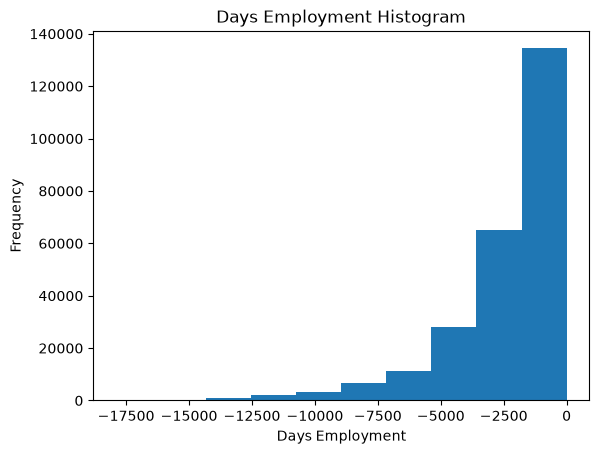

In [21]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

#### Investigation : `previous_application` — pourquoi 365243 apparaît-il ?

In [22]:
# 2. Vérification de l'hypothèse : l'anomalie est-elle liée au statut du contrat ?
anom_cols = [f"{col}_ANOM" for col in previous_days_cols]

for col in anom_cols:
    print(f"\n--- {col} ---")
    print(previous_app.groupby('NAME_CONTRACT_STATUS')[col].mean())


--- DAYS_FIRST_DRAWING_ANOM ---
NAME_CONTRACT_STATUS
Approved        0.901294
Canceled        0.000000
Refused         0.000000
Unused offer    0.000000
Name: DAYS_FIRST_DRAWING_ANOM, dtype: float64

--- DAYS_FIRST_DUE_ANOM ---
NAME_CONTRACT_STATUS
Approved        0.039203
Canceled        0.000000
Refused         0.000000
Unused offer    0.000000
Name: DAYS_FIRST_DUE_ANOM, dtype: float64

--- DAYS_LAST_DUE_1ST_VERSION_ANOM ---
NAME_CONTRACT_STATUS
Approved        0.090534
Canceled        0.000000
Refused         0.000000
Unused offer    0.000000
Name: DAYS_LAST_DUE_1ST_VERSION_ANOM, dtype: float64

--- DAYS_LAST_DUE_ANOM ---
NAME_CONTRACT_STATUS
Approved        0.203728
Canceled        0.000000
Refused         0.000000
Unused offer    0.000000
Name: DAYS_LAST_DUE_ANOM, dtype: float64

--- DAYS_TERMINATION_ANOM ---
NAME_CONTRACT_STATUS
Approved        0.217898
Canceled        0.000000
Refused         0.000000
Unused offer    0.000000
Name: DAYS_TERMINATION_ANOM, dtype: float64


In [23]:
# Croisement avec le type de contrat, sur les prêts approuvés uniquement
approved = previous_app[previous_app['NAME_CONTRACT_STATUS'] == 'Approved']

pd.crosstab(
    approved['NAME_CONTRACT_TYPE'],
    approved['DAYS_FIRST_DRAWING_ANOM'],
    normalize='index'
)

DAYS_FIRST_DRAWING_ANOM,False,True
NAME_CONTRACT_TYPE,,
Cash loans,0.076019,0.923981
Consumer loans,0.018941,0.981059
Revolving loans,0.682329,0.317671


In [24]:
for col in ["DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION", "DAYS_LAST_DUE", "DAYS_TERMINATION"]:
    print(f"\n--- {col}_ANOM par type de contrat ---")
    display(pd.crosstab(
        approved['NAME_CONTRACT_TYPE'],
        approved[f'{col}_ANOM'],
        normalize='index'
    ))


--- DAYS_FIRST_DUE_ANOM par type de contrat ---


DAYS_FIRST_DUE_ANOM,False,True
NAME_CONTRACT_TYPE,,
Cash loans,0.998563,0.001437
Consumer loans,0.988959,0.011041
Revolving loans,0.659623,0.340377



--- DAYS_LAST_DUE_1ST_VERSION_ANOM par type de contrat ---


DAYS_LAST_DUE_1ST_VERSION_ANOM,False,True
NAME_CONTRACT_TYPE,,
Cash loans,0.999990,0.000010
Consumer loans,0.999837,0.000163
Revolving loans,0.041035,0.958965



--- DAYS_LAST_DUE_ANOM par type de contrat ---


DAYS_LAST_DUE_ANOM,False,True
NAME_CONTRACT_TYPE,,
Cash loans,0.776553,0.223447
Consumer loans,0.885653,0.114347
Revolving loans,0.286598,0.713402



--- DAYS_TERMINATION_ANOM par type de contrat ---


DAYS_TERMINATION_ANOM,False,True
NAME_CONTRACT_TYPE,,
Cash loans,0.773200,0.226800
Consumer loans,0.881571,0.118429
Revolving loans,0.173201,0.826799


**Conclusion** : deux mécanismes distincts derrière ces 5 colonnes (voir tableau de synthèse en fin de bloc) :
- `DAYS_FIRST_DRAWING` / `DAYS_FIRST_DUE` / `DAYS_LAST_DUE_1ST_VERSION` → lié au **type de contrat** (non applicable aux crédits revolving)
- `DAYS_LAST_DUE` / `DAYS_TERMINATION` → lié au **statut du crédit** (pas encore clôturé)

### 2.3 Investigation : `bureau` — `DAYS_CREDIT_ENDDATE`

In [25]:
# Vérifier si une valeur précise revient anormalement souvent (code sentinelle)
# ou si c'est une distribution continue (outlier statistique légitime)
display(bureau['DAYS_CREDIT_ENDDATE'].value_counts().head(10))
display(bureau['DAYS_CREDIT_ENDDATE'].sort_values(ascending=False).head(20))


DAYS_CREDIT_ENDDATE
 0.0     883
 3.0     845
-7.0     837
 1.0     830
-14.0    787
-10.0    782
 4.0     777
-2.0     772
-1.0     771
-42.0    768
Name: count, dtype: int64

1168469    31199.0
384847     31198.0
1668173    31198.0
1452769    31198.0
1452767    31198.0
1668033    31198.0
1353000    31198.0
91086      31198.0
385112     31198.0
1453614    31198.0
1667908    31198.0
385088     31198.0
1296987    31198.0
1453602    31198.0
1453708    31198.0
965950     31198.0
385064     31198.0
952707     31198.0
1452628    31198.0
682780     31198.0
Name: DAYS_CREDIT_ENDDATE, dtype: float64

In [26]:
# Combien de lignes sont concernées par cette valeur exacte (31198) ?
print(bureau['DAYS_CREDIT_ENDDATE'].value_counts().get(31198.0, 0))

# Est-ce lié à un type de crédit particulier ?
bureau[bureau['DAYS_CREDIT_ENDDATE'] >= 30000]['CREDIT_TYPE'].value_counts()

# Est-ce lié à CREDIT_ACTIVE (actif vs clos) ?
bureau[bureau['DAYS_CREDIT_ENDDATE'] >= 30000]['CREDIT_ACTIVE'].value_counts()

89


CREDIT_ACTIVE
Active    23508
Closed     6712
Sold         20
Name: count, dtype: int64

**Conclusion** : outlier statistique légitime, pas un code sentinelle (seulement 89 lignes concernées, majoritairement des crédits longue durée encore **actifs**). Aucun traitement nécessaire (LightGBM est robuste à ce type de distribution).

### 2.4 Traitement : capping de `AMT_INCOME_TOTAL`

In [27]:
rows = get_flagged_rows(app_train, results_app_train, "AMT_INCOME_TOTAL", method="both")
display(rows[["SK_ID_CURR", "TARGET", "AMT_INCOME_TOTAL"]].sort_values("AMT_INCOME_TOTAL", ascending=False))

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL
12840,114967,1,117000000.0
203693,336147,0,18000090.0
246858,385674,0,13500000.0
77768,190160,0,9000000.0
131127,252084,0,6750000.0
...,...,...,...
77742,190131,0,477000.0
285984,431218,0,477000.0
251577,391095,0,477000.0
153980,278459,0,475650.0


In [28]:
cap_value = app_train['AMT_INCOME_TOTAL'].quantile(0.995)
print(f"Seuil de capping (99.5e percentile) : {cap_value}")

Seuil de capping (99.5e percentile) : 630000.0


In [29]:
# Recharger uniquement la colonne originale depuis le CSV pour restaurer les vraies valeurs
income_original = pd.read_csv('../data/application_train.csv', usecols=['SK_ID_CURR', 'AMT_INCOME_TOTAL'])
income_original = income_original.rename(columns={'AMT_INCOME_TOTAL': 'AMT_INCOME_TOTAL_ORIGINAL'})

app_train = app_train.merge(income_original, on='SK_ID_CURR', how='left')

# Recalculer le flag correctement, sur les vraies valeurs originales
app_train['AMT_INCOME_TOTAL_CAPPED_FLAG'] = app_train['AMT_INCOME_TOTAL_ORIGINAL'] > cap_value
app_train['AMT_INCOME_TOTAL'] = app_train['AMT_INCOME_TOTAL_ORIGINAL'].clip(upper=cap_value)
app_train = app_train.drop(columns=['AMT_INCOME_TOTAL_ORIGINAL'])

# Vérification
print(f"Nombre de lignes cappées : {app_train['AMT_INCOME_TOTAL_CAPPED_FLAG'].sum()}")
print(app_train['AMT_INCOME_TOTAL'].describe())

Nombre de lignes cappées : 1446
count    307511.000000
mean     167136.388797
std       87919.401895
min       25650.000000
25%      112500.000000
50%      147150.000000
75%      202500.000000
max      630000.000000
Name: AMT_INCOME_TOTAL, dtype: float64


In [30]:
income_test_original = pd.read_csv('../data/application_test.csv', usecols=['SK_ID_CURR', 'AMT_INCOME_TOTAL'])
income_test_original = income_test_original.rename(columns={'AMT_INCOME_TOTAL': 'AMT_INCOME_TOTAL_ORIGINAL'})

app_test = app_test.merge(income_test_original, on='SK_ID_CURR', how='left')

app_test['AMT_INCOME_TOTAL_CAPPED_FLAG'] = app_test['AMT_INCOME_TOTAL_ORIGINAL'] > cap_value
app_test['AMT_INCOME_TOTAL'] = app_test['AMT_INCOME_TOTAL_ORIGINAL'].clip(upper=cap_value)
app_test = app_test.drop(columns=['AMT_INCOME_TOTAL_ORIGINAL'])

# Vérification
print(f"Nombre de lignes cappées : {app_test['AMT_INCOME_TOTAL_CAPPED_FLAG'].sum()}")
print(app_test['AMT_INCOME_TOTAL'].describe())

Nombre de lignes cappées : 234
count     48744.000000
mean     177273.386357
std       90458.117079
min       26941.500000
25%      112500.000000
50%      157500.000000
75%      225000.000000
max      630000.000000
Name: AMT_INCOME_TOTAL, dtype: float64


### 2.5 Synthèse des anomalies détectées et traitées

| Colonne | Table | Type d'anomalie | Décision | Justification |
|---|---|---|---|---|
| DAYS_EMPLOYED | app_train, app_test | Code sentinelle (365243) | Flag + NaN | Valeur physiquement impossible ; lié aux retraités/sans emploi |
| DAYS_FIRST_DRAWING | previous_application | Code sentinelle (365243) | Flag + NaN | Non applicable aux crédits revolving (pas de tirage unique) |
| DAYS_FIRST_DUE | previous_application | Code sentinelle (365243) | Flag + NaN | Non applicable aux crédits revolving |
| DAYS_LAST_DUE_1ST_VERSION | previous_application | Code sentinelle (365243) | Flag + NaN | Non applicable aux crédits revolving |
| DAYS_LAST_DUE | previous_application | Code sentinelle (365243) | Flag + NaN | Crédit encore actif, échéance finale pas encore survenue |
| DAYS_TERMINATION | previous_application | Code sentinelle (365243) | Flag + NaN | Crédit encore actif, pas encore clôturé |
| DAYS_CREDIT_ENDDATE | bureau | Outlier statistique légitime | Aucun traitement | Crédits longue durée réellement actifs, pas un bug |
| AMT_INCOME_TOTAL | app_train, app_test | Outlier statistique | Capping au 99.5e percentile (630 000) + flag | Cas extrêmes isolés (jusqu'à 117M) faussant la distribution ; flag conservé pour ne pas perdre l'info |


## Bloc 3 : Corrélations

### 3.1 Multicolinéarité (Pearson & Spearman, variable ↔ variable)

In [31]:
numeric_col_apptrain = app_train.select_dtypes(include=[np.number]).columns
pearson_corr_apptrain= app_train[numeric_col_apptrain].corr(method='pearson')
spearman_corr_apptrain = app_train[numeric_col_apptrain].corr(method='spearman')

def get_high_correlation_pairs(corr_matrix, threshold=0.7):
    corr_pairs = corr_matrix.abs().unstack()
    corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

    corr_pairs = corr_pairs.reset_index()
    corr_pairs.columns = ['var_1', 'var_2', 'abs_corr']
    corr_pairs['pair_key'] = corr_pairs.apply(lambda x: tuple(sorted([x['var_1'], x['var_2']])), axis=1)
    corr_pairs = corr_pairs.drop_duplicates(subset='pair_key').drop(columns='pair_key')

    high_corr = corr_pairs[corr_pairs['abs_corr'] >= threshold].sort_values('abs_corr', ascending=False)
    return high_corr.reset_index(drop=True)

print("=== Paires avec corrélation de PEARSON >= 0.7 ===")
pearson_high = get_high_correlation_pairs(pearson_corr_apptrain, threshold=0.7)
display(pearson_high)
print(f"Nombre de paires : {len(pearson_high)}")

print("\n=== Paires avec corrélation de SPEARMAN >= 0.7 ===")
spearman_high = get_high_correlation_pairs(spearman_corr_apptrain, threshold=0.7)
display(spearman_high)
print(f"Nombre de paires : {len(spearman_high)}")

=== Paires avec corrélation de PEARSON >= 0.7 ===


,var_1,var_2,abs_corr
0,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998495
1,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998490
2,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997241
3,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997034
4,ENTRANCES_AVG,ENTRANCES_MEDI,0.996886
...,...,...,...
121,FLOORSMAX_MODE,FLOORSMIN_MEDI,0.729871
122,FLOORSMIN_AVG,FLOORSMAX_MODE,0.729179
123,FLOORSMAX_MODE,FLOORSMIN_MODE,0.726334
124,FLOORSMIN_MODE,FLOORSMAX_MEDI,0.722970


Nombre de paires : 126

=== Paires avec corrélation de SPEARMAN >= 0.7 ===


,var_1,var_2,abs_corr
0,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998411
1,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MEDI,0.997432
2,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.997336
3,LANDAREA_AVG,LANDAREA_MEDI,0.996279
4,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.996223
...,...,...,...
144,ELEVATORS_MODE,LIVINGAREA_MEDI,0.708099
145,ELEVATORS_MODE,TOTALAREA_MODE,0.706147
146,BASEMENTAREA_MEDI,TOTALAREA_MODE,0.704938
147,BASEMENTAREA_MODE,LIVINGAREA_MODE,0.703070


Nombre de paires : 149


### 3.2 Corrélation avec TARGET (Pearson, Spearman, information mutuelle)

In [32]:
#Correlation avec TARGET
target_corr_pearson = pearson_corr_apptrain['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print("Top 15 (Pearson) :")
print(target_corr_pearson.head(15))

target_corr_spearman = spearman_corr_apptrain['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print("Top 15 (Spearman) :")
print(target_corr_spearman.head(15))

Top 15 (Pearson) :
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
DAYS_EMPLOYED                  0.074958
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                  0.044003
FLOORSMAX_MEDI                 0.043768
Name: TARGET, dtype: float64
Top 15 (Spearman) :
EXT_SOURCE_3                   0.166330
EXT_SOURCE_1                   0.151128
EXT_SOURCE_2                   0.147332
DAYS_EMPLOYED                  0.080271
DAYS_BIRTH                     0.078328
REGION_RATING_CLIENT_W_CITY    0.060936
REGION_RATING_CLIENT           0.058909
DAYS_LAST_PHONE_CHANGE         0.053711
OWN_CAR_AGE 

In [33]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# --- 1. Colonnes numériques de départ, sans TARGET ---
numeric_col_apptrain = app_train.select_dtypes(include=['number']).columns
if 'TARGET' in numeric_col_apptrain:
    numeric_col_apptrain = numeric_col_apptrain.drop('TARGET')

# --- 2. Exclure quasi-constantes ET fort taux de missing (source de l'artefact d'imputation) ---
quasi_constant_cols = results_app_train["quasi_constant"]["column"].tolist()
high_missing_cols = results_app_train["high_missing"]["column"].tolist()

cols_to_exclude = set(quasi_constant_cols) | set(high_missing_cols)
numeric_col_clean = [col for col in numeric_col_apptrain if col not in cols_to_exclude]

print(f"Colonnes numériques de départ : {len(numeric_col_apptrain)}")
print(f"Quasi-constantes exclues : {len(quasi_constant_cols)}")
print(f"Fort taux de missing exclues (>40%) : {len(high_missing_cols)}")
print(f"Colonnes retenues pour le calcul : {len(numeric_col_clean)}")

# --- 3. Préparer X et y (imputation médiane désormais sans risque, peu de NaN restants) ---
X = app_train[numeric_col_clean].fillna(app_train[numeric_col_clean].median())
y = app_train['TARGET']

# --- 4. Identifier les colonnes discrètes vs continues ---
discrete_features_mask = [X[col].nunique() <= 20 for col in X.columns]

# --- 5. Calcul de l'information mutuelle ---
mi_scores = mutual_info_classif(
    X, y,
    discrete_features=discrete_features_mask,
    random_state=42,
    n_jobs=-1
)

mi_series = pd.Series(mi_scores, index=numeric_col_clean).sort_values(ascending=False)

print("\nTop 15 selon l'information mutuelle (corrigé, sans quasi-constantes ni fort missing) :")
print(mi_series.head(15))

Colonnes numériques de départ : 105
Quasi-constantes exclues : 20
Fort taux de missing exclues (>40%) : 49
Colonnes retenues pour le calcul : 40

Top 15 selon l'information mutuelle (corrigé, sans quasi-constantes ni fort missing) :
EXT_SOURCE_3                   0.015417
EXT_SOURCE_2                   0.012247
AMT_ANNUITY                    0.011992
AMT_REQ_CREDIT_BUREAU_YEAR     0.009447
AMT_CREDIT                     0.007239
DAYS_EMPLOYED                  0.005666
AMT_GOODS_PRICE                0.005550
REGION_POPULATION_RELATIVE     0.004715
HOUR_APPR_PROCESS_START        0.004608
DAYS_BIRTH                     0.003805
AMT_INCOME_TOTAL               0.003066
OBS_60_CNT_SOCIAL_CIRCLE       0.002561
DAYS_ID_PUBLISH                0.002110
OBS_30_CNT_SOCIAL_CIRCLE       0.002009
REGION_RATING_CLIENT_W_CITY    0.001869
dtype: float64


### 3.3 V de Cramér (variables catégorielles) 

Prochaine étape : mesurer l'association entre les variables catégorielles et `TARGET` (et entre elles pour la multicolinéarité), avec le V de Cramér — équivalent du travail déjà fait ci-dessus pour les variables numériques.

In [34]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd
import itertools

def cramers_v(x, y):
    """
    Calcule le V de Cramér (avec correction de biais de Bergsma) entre deux variables catégorielles.
    Retourne une valeur entre 0 (aucune association) et 1 (association parfaite).
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Correction de biais (Bergsma, 2013) - évite de surestimer l'association
    # sur des petits échantillons ou des tables avec beaucoup de catégories
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom == 0:
        return np.nan
    return np.sqrt(phi2corr / denom)


def cramers_v_matrix(df, cat_cols):
    """
    Calcule le V de Cramér pour toutes les paires de colonnes catégorielles.
    """
    n = len(cat_cols)
    result = pd.DataFrame(np.zeros((n, n)), index=cat_cols, columns=cat_cols)

    for col1, col2 in itertools.combinations(cat_cols, 2):
        v = cramers_v(df[col1], df[col2])
        result.loc[col1, col2] = v
        result.loc[col2, col1] = v

    for col in cat_cols:
        result.loc[col, col] = 1.0
    return result
    

In [35]:
cat_cols = app_train.select_dtypes(include=['object']).columns.tolist()

target_cramers_v = {}
for col in cat_cols:
    # dropna pour éviter les erreurs sur les NaN dans la variable catégorielle
    mask = app_train[col].notna()
    target_cramers_v[col] = cramers_v(app_train.loc[mask, col], app_train.loc[mask, 'TARGET'])

target_cramers_v_series = pd.Series(target_cramers_v).sort_values(ascending=False)
print("V de Cramér avec TARGET, toutes les variables catégorielles :")
print(target_cramers_v_series)

V de Cramér avec TARGET, toutes les variables catégorielles :
OCCUPATION_TYPE               0.081020
ORGANIZATION_TYPE             0.071048
NAME_INCOME_TYPE              0.063667
NAME_EDUCATION_TYPE           0.057458
CODE_GENDER                   0.054661
NAME_FAMILY_STATUS            0.040311
NAME_HOUSING_TYPE             0.036761
NAME_CONTRACT_TYPE            0.030823
WALLSMATERIAL_MODE            0.029688
FLAG_OWN_CAR                  0.021764
HOUSETYPE_MODE                0.012934
FONDKAPREMONT_MODE            0.011919
EMERGENCYSTATE_MODE           0.011841
NAME_TYPE_SUITE               0.009360
FLAG_OWN_REALTY               0.005864
WEEKDAY_APPR_PROCESS_START    0.005525
dtype: float64


In [36]:
cramers_matrix = cramers_v_matrix(app_train, cat_cols)

# Extraire les paires avec une association forte (même logique que get_high_correlation_pairs)
cramers_pairs = cramers_matrix.abs().unstack()
cramers_pairs = cramers_pairs[cramers_pairs.index.get_level_values(0) != cramers_pairs.index.get_level_values(1)]
cramers_pairs = cramers_pairs.reset_index()
cramers_pairs.columns = ['var_1', 'var_2', 'cramers_v']
cramers_pairs['pair_key'] = cramers_pairs.apply(lambda x: tuple(sorted([x['var_1'], x['var_2']])), axis=1)
cramers_pairs = cramers_pairs.drop_duplicates(subset='pair_key').drop(columns='pair_key')

cramers_high = cramers_pairs[cramers_pairs['cramers_v'] >= 0.5].sort_values('cramers_v', ascending=False)
print(f"\nPaires de variables catégorielles avec V de Cramér >= 0.5 :")
display(cramers_high)


Paires de variables catégorielles avec V de Cramér >= 0.5 :


,var_1,var_2,cramers_v


In [37]:
cramers_pairs_all = cramers_pairs.sort_values('cramers_v', ascending=False)
display(cramers_pairs_all.head(15))

,var_1,var_2,cramers_v
85,NAME_INCOME_TYPE,ORGANIZATION_TYPE,0.422382
23,CODE_GENDER,OCCUPATION_TYPE,0.404676
16,CODE_GENDER,FLAG_OWN_CAR,0.345839
224,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,0.317166
145,OCCUPATION_TYPE,ORGANIZATION_TYPE,0.300899
38,FLAG_OWN_CAR,OCCUPATION_TYPE,0.264509
25,CODE_GENDER,ORGANIZATION_TYPE,0.238395
52,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,0.225076
98,NAME_EDUCATION_TYPE,OCCUPATION_TYPE,0.218911
40,FLAG_OWN_CAR,ORGANIZATION_TYPE,0.202070


On s'assure ainsi qu'effectivement aucune valeur du V de Cramer n'est proche du seuil donc pas de corrélation catégorielle problématique.

count    307511.000000
mean          0.245435
std           0.171604
min           0.000000
25%           0.040984
50%           0.303279
75%           0.401639
max           0.508197
Name: pct_nan_row, dtype: float64
                    taux_defaut  n_clients
nan_bucket                                
(-0.000508, 0.102]     0.068604      97166
(0.102, 0.203]         0.068820      38274
(0.203, 0.305]         0.075996      18830
(0.305, 0.407]         0.093078     100722
(0.407, 0.508]         0.089853      52519


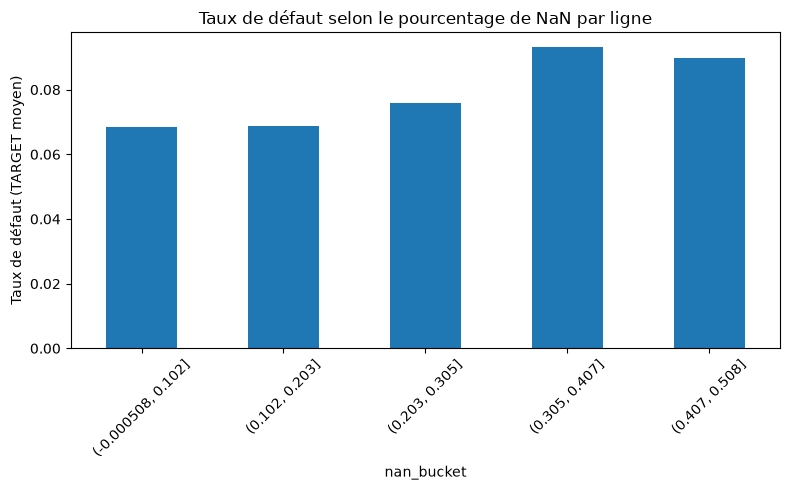

In [38]:
# Calcul du % de NaN par ligne (sur toutes les colonnes sauf TARGET/SK_ID_CURR)
cols_to_check = [col for col in app_train.columns if col not in ['SK_ID_CURR', 'TARGET']]
app_train['pct_nan_row'] = app_train[cols_to_check].isnull().mean(axis=1)

# Distribution générale
print(app_train['pct_nan_row'].describe())

# Taux de défaut selon le niveau de NaN par ligne
app_train['nan_bucket'] = pd.cut(app_train['pct_nan_row'], bins=5)
defaut_par_bucket = app_train.groupby('nan_bucket')['TARGET'].agg(['mean', 'count'])
defaut_par_bucket.columns = ['taux_defaut', 'n_clients']
print(defaut_par_bucket)

# Visualisation
plt.figure(figsize=(8, 5))
defaut_par_bucket['taux_defaut'].plot(kind='bar')
plt.title('Taux de défaut selon le pourcentage de NaN par ligne')
plt.ylabel('Taux de défaut (TARGET moyen)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# Construire un compteur d'outliers par ligne, à partir des résultats déjà calculés
outlier_columns = results_app_train["outliers"]["column"].tolist()

outlier_count = pd.Series(0, index=app_train.index)
for col in outlier_columns:
    mask_both = results_app_train["row_level_flags"][col]["both"]
    # aligner l'index (le mask a été calculé sur .dropna(), donc pas forcément le même index complet)
    outlier_count = outlier_count.add(mask_both.reindex(app_train.index, fill_value=False).astype(int), fill_value=0)

app_train['n_outliers_row'] = outlier_count

print(app_train['n_outliers_row'].describe())
print(app_train['n_outliers_row'].value_counts().sort_index())

# Taux de défaut selon le nombre d'outliers par ligne
defaut_par_n_outliers = app_train.groupby('n_outliers_row')['TARGET'].agg(['mean', 'count'])
defaut_par_n_outliers.columns = ['taux_defaut', 'n_clients']
print(defaut_par_n_outliers)

count    307511.000000
mean          0.557043
std           1.710575
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          28.000000
Name: n_outliers_row, dtype: float64
n_outliers_row
0     223472
1      63362
2       2946
3       8549
4       2836
5        489
6       1318
7        854
8        257
9        354
10       601
11       242
12       203
13       560
14       229
15        58
16       545
17       164
18        28
19       240
20        60
21        17
22        83
23        25
24         3
25         7
26         6
27         2
28         1
Name: count, dtype: int64
                taux_defaut  n_clients
n_outliers_row                        
0                  0.089975     223472
1                  0.055570      63362
2                  0.051595       2946
3                  0.068312       8549
4                  0.046544       2836
5                  0.040900        489
6                  0.058422       1318
7         

## Bloc 4 : Data-cleaning

### 4.1 Cleaning des colonnes constantes ou quasi constantes.

In [40]:
# Taux de la valeur la plus fréquente (dominante), pour TOUTES les colonnes, triées
dominant_freq_all = {}
for col in app_train.columns:
    if col in ['SK_ID_CURR', 'TARGET']:
        continue
    freq = app_train[col].value_counts(normalize=True, dropna=True)
    if len(freq) > 0:
        dominant_freq_all[col] = freq.iloc[0]

dominant_freq_series = pd.Series(dominant_freq_all).sort_values(ascending=False)

print("Top 30 colonnes par taux de valeur dominante :")
print(dominant_freq_series.head(30))

Top 30 colonnes par taux de valeur dominante :
FLAG_MOBIL                      0.999997
FLAG_DOCUMENT_12                0.999993
FLAG_DOCUMENT_10                0.999977
FLAG_DOCUMENT_2                 0.999958
FLAG_DOCUMENT_4                 0.999919
FLAG_DOCUMENT_7                 0.999808
FLAG_DOCUMENT_17                0.999733
FLAG_DOCUMENT_21                0.999665
FLAG_DOCUMENT_20                0.999493
FLAG_DOCUMENT_19                0.999405
FLAG_DOCUMENT_15                0.998790
FLAG_CONT_MOBILE                0.998133
FLAG_DOCUMENT_14                0.997064
FLAG_DOCUMENT_13                0.996475
FLAG_DOCUMENT_9                 0.996104
FLAG_DOCUMENT_11                0.996088
AMT_INCOME_TOTAL_CAPPED_FLAG    0.995298
AMT_REQ_CREDIT_BUREAU_DAY       0.994402
AMT_REQ_CREDIT_BUREAU_HOUR      0.993887
FLAG_DOCUMENT_18                0.991870
FLAG_DOCUMENT_16                0.990072
EMERGENCYSTATE_MODE             0.985608
FLAG_DOCUMENT_5                 0.984885
REG_REGION

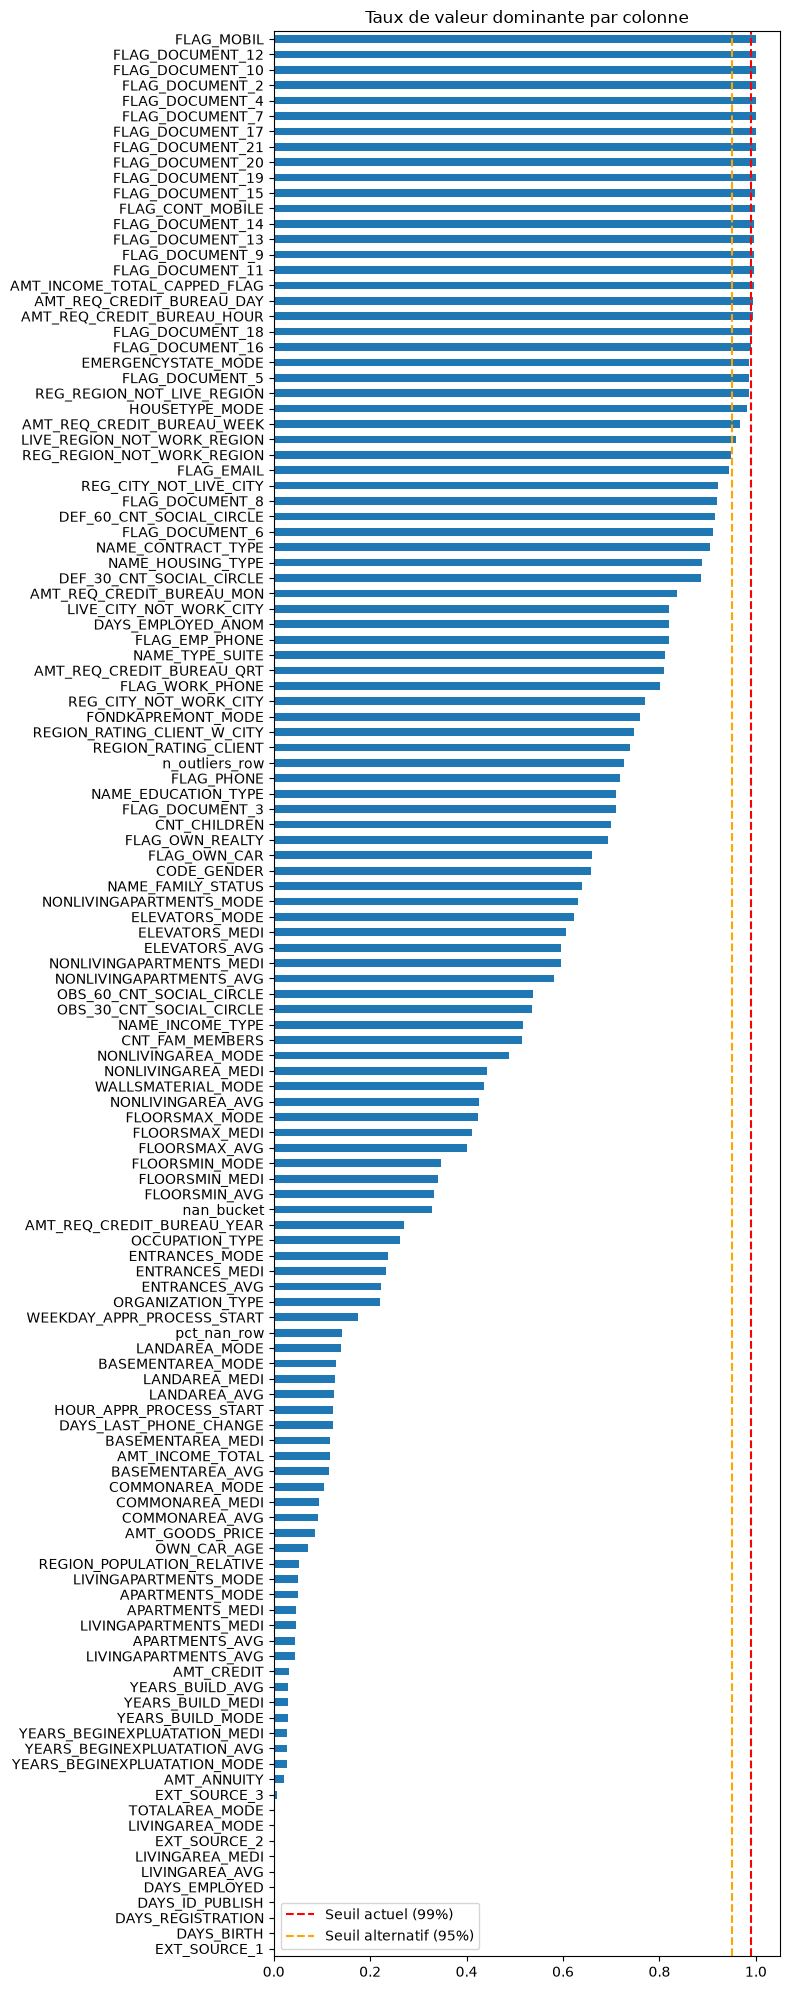

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
dominant_freq_series.sort_values(ascending=True).plot(kind='barh', figsize=(8, 20))
plt.axvline(x=0.99, color='red', linestyle='--', label='Seuil actuel (99%)')
plt.axvline(x=0.95, color='orange', linestyle='--', label='Seuil alternatif (95%)')
plt.legend()
plt.title('Taux de valeur dominante par colonne')
plt.tight_layout()
plt.show()

In [42]:
# --- 1. Suppression pure ---
cols_to_drop_pure = ['FLAG_MOBIL', 'FLAG_CONT_MOBILE',
                      'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY']

# --- 2. Regroupement des FLAG_DOCUMENT_* quasi-constants (16 colonnes, avec FLAG_DOCUMENT_5) ---
flag_document_quasi_constant = [
    'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17',
    'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
]

def apply_document_grouping(df, flag_cols):
    df = df.copy()
    df['TOTAL_DOCUMENTS_PROVIDED'] = df[flag_cols].sum(axis=1)
    df = df.drop(columns=flag_cols)
    return df

app_train = apply_document_grouping(app_train, flag_document_quasi_constant)
app_test = apply_document_grouping(app_test, flag_document_quasi_constant)

app_train = app_train.drop(columns=cols_to_drop_pure)
app_test = app_test.drop(columns=cols_to_drop_pure)

# --- 3. Nettoyage de la colonne temporaire d'analyse ---
app_train = app_train.drop(columns=['nan_bucket'])

# --- Vérifications ---
print("Nouvelle shape app_train :", app_train.shape)
print("Nouvelle shape app_test :", app_test.shape)

print("\nDistribution de TOTAL_DOCUMENTS_PROVIDED :")
print(app_train['TOTAL_DOCUMENTS_PROVIDED'].value_counts().sort_index())

print("\nTaux de défaut selon TOTAL_DOCUMENTS_PROVIDED :")
print(app_train.groupby('TOTAL_DOCUMENTS_PROVIDED')['TARGET'].agg(['mean', 'count']))

Nouvelle shape app_train : (307511, 106)
Nouvelle shape app_test : (48744, 103)

Distribution de TOTAL_DOCUMENTS_PROVIDED :
TOTAL_DOCUMENTS_PROVIDED
0    292148
1     15136
2       226
3         1
Name: count, dtype: int64

Taux de défaut selon TOTAL_DOCUMENTS_PROVIDED :
                              mean   count
TOTAL_DOCUMENTS_PROVIDED                  
0                         0.081852  292148
1                         0.058998   15136
2                         0.079646     226
3                         1.000000       1


### 4.2 Correction du bloc longement pour diminuer la redondance d'information

In [43]:
# Récupérer toutes les colonnes numériques encore présentes dans app_train
numeric_cols_current = app_train.select_dtypes(include=[np.number]).columns.tolist()

# Repérer les colonnes qui se terminent par _AVG, _MODE, ou _MEDI (le bloc logement)
suffixes = ['_AVG', '_MODE', '_MEDI']
housing_cols = [col for col in numeric_cols_current if any(col.endswith(s) for s in suffixes)]

# Extraire le "nom de base" en retirant le suffixe (ex: FLOORSMAX_AVG -> FLOORSMAX)
base_names = set()
for col in housing_cols:
    for s in suffixes:
        if col.endswith(s):
            base_names.add(col[:-len(s)])

print(f"Nombre de colonnes du bloc logement détectées : {len(housing_cols)}")
print(f"Nombre de variables de base (avant triplement) : {len(base_names)}")
print(f"Exemples de noms de base : {sorted(list(base_names))[:5]}")

Nombre de colonnes du bloc logement détectées : 43
Nombre de variables de base (avant triplement) : 15
Exemples de noms de base : ['APARTMENTS', 'BASEMENTAREA', 'COMMONAREA', 'ELEVATORS', 'ENTRANCES']


In [44]:
# Recalculer la corrélation avec TARGET pour les colonnes du bloc logement encore présentes
housing_target_corr = app_train[housing_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')

print("Corrélations individuelles (valeur absolue), triées :")
print(housing_target_corr.abs().sort_values(ascending=False).head(15))

Corrélations individuelles (valeur absolue), triées :
FLOORSMAX_AVG      0.044003
FLOORSMAX_MEDI     0.043768
FLOORSMAX_MODE     0.043226
ELEVATORS_AVG      0.034199
ELEVATORS_MEDI     0.033863
FLOORSMIN_AVG      0.033614
FLOORSMIN_MEDI     0.033394
LIVINGAREA_AVG     0.032997
LIVINGAREA_MEDI    0.032739
FLOORSMIN_MODE     0.032698
TOTALAREA_MODE     0.032596
ELEVATORS_MODE     0.032131
LIVINGAREA_MODE    0.030685
APARTMENTS_AVG     0.029498
APARTMENTS_MEDI    0.029184
Name: TARGET, dtype: float64


In [45]:
comparison_rows = []
for base in sorted(base_names):
    row = {'base_variable': base}
    for s in suffixes:
        col_name = base + s
        if col_name in housing_target_corr.index:
            row[s] = housing_target_corr[col_name]
        else:
            row[s] = np.nan  # cette version n'existe pas pour cette variable
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('base_variable')

# Identifier quelle version a la corrélation la plus forte (en valeur absolue) pour chaque variable
comparison_df['best_suffix'] = comparison_df[suffixes].abs().idxmax(axis=1)

display(comparison_df)

print("\nRépartition du 'meilleur' suffixe à travers toutes les variables du bloc logement :")
print(comparison_df['best_suffix'].value_counts())

,_AVG,_MODE,_MEDI,best_suffix
base_variable,,,,
APARTMENTS,-0.029498,-0.027284,-0.029184,_AVG
BASEMENTAREA,-0.022746,-0.019952,-0.022081,_AVG
COMMONAREA,-0.018550,-0.016340,-0.018573,_MEDI
ELEVATORS,-0.034199,-0.032131,-0.033863,_AVG
ENTRANCES,-0.019172,-0.017387,-0.019025,_AVG
FLOORSMAX,-0.044003,-0.043226,-0.043768,_AVG
FLOORSMIN,-0.033614,-0.032698,-0.033394,_AVG
LANDAREA,-0.010885,-0.010174,-0.011256,_MEDI
LIVINGAPARTMENTS,-0.025031,-0.023393,-0.024621,_AVG



Répartition du 'meilleur' suffixe à travers toutes les variables du bloc logement :
best_suffix
_AVG     10
_MEDI     4
_MODE     1
Name: count, dtype: int64


In [46]:
# --- Règle : garder _AVG pour toutes les variables du bloc logement (sauf exception) ---
# Exception : TOTALAREA n'a que _MODE (pas de version _AVG ni _MEDI), on la garde telle quelle

cols_to_drop_housing = []
for base in base_names:
    if base == 'TOTALAREA':
        continue  # on garde TOTALAREA_MODE tel quel, pas d'autre version disponible
    for s in ['_MODE', '_MEDI']:
        col_name = base + s
        if col_name in app_train.columns:
            cols_to_drop_housing.append(col_name)

print(f"Nombre de colonnes à supprimer (bloc logement) : {len(cols_to_drop_housing)}")
print(cols_to_drop_housing)

app_train = app_train.drop(columns=cols_to_drop_housing)
app_test = app_test.drop(columns=[c for c in cols_to_drop_housing if c in app_test.columns])

print("\nNouvelle shape app_train :", app_train.shape)
print("Nouvelle shape app_test :", app_test.shape)

Nombre de colonnes à supprimer (bloc logement) : 28
['LANDAREA_MODE', 'LANDAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_MEDI', 'LIVINGAREA_MODE', 'LIVINGAREA_MEDI', 'FLOORSMAX_MODE', 'FLOORSMAX_MEDI', 'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'APARTMENTS_MODE', 'APARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_MEDI', 'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI']

Nouvelle shape app_train : (307511, 78)
Nouvelle shape app_test : (48744, 75)


### 4.3  Revérification des corrélations après nettoyage des df

In [47]:
# Recalculer les colonnes numériques actuelles (après suppression du bloc logement)
numeric_cols_updated = app_train.select_dtypes(include=[np.number]).columns

pearson_corr_updated = app_train[numeric_cols_updated].corr(method='pearson')

pearson_high_updated = get_high_correlation_pairs(pearson_corr_updated, threshold=0.7)
print(f"Nombre de paires restantes avec |corrélation| >= 0.7 : {len(pearson_high_updated)}")
display(pearson_high_updated)

Nombre de paires restantes avec |corrélation| >= 0.7 : 20


,var_1,var_2,abs_corr
0,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998490
1,AMT_CREDIT,AMT_GOODS_PRICE,0.986968
2,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.950842
3,APARTMENTS_AVG,LIVINGAPARTMENTS_AVG,0.943952
4,LIVINGAREA_AVG,TOTALAREA_MODE,0.925039
5,APARTMENTS_AVG,LIVINGAREA_AVG,0.913619
6,APARTMENTS_AVG,TOTALAREA_MODE,0.892627
7,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,0.880798
8,CNT_CHILDREN,CNT_FAM_MEMBERS,0.879161
9,ELEVATORS_AVG,LIVINGAREA_AVG,0.867776


In [48]:
import networkx as nx

def find_correlation_clusters(high_corr_pairs):
    """
    Regroupe les variables en clusters connexes à partir des paires fortement corrélées.
    Deux variables sont dans le même cluster si elles sont reliées directement
    OU indirectement par une chaîne de corrélations fortes.
    """
    G = nx.Graph()
    G.add_edges_from(zip(high_corr_pairs['var_1'], high_corr_pairs['var_2']))
    clusters = list(nx.connected_components(G))
    return sorted(clusters, key=len, reverse=True)

clusters = find_correlation_clusters(pearson_high_updated)

print(f"Nombre de clusters : {len(clusters)}\n")
for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1} ({len(cluster)} variables) : {sorted(cluster)}")

Nombre de clusters : 9

Cluster 1 (5 variables) : ['APARTMENTS_AVG', 'ELEVATORS_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'TOTALAREA_MODE']
Cluster 2 (3 variables) : ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE']
Cluster 3 (2 variables) : ['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE']
Cluster 4 (2 variables) : ['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']
Cluster 5 (2 variables) : ['CNT_CHILDREN', 'CNT_FAM_MEMBERS']
Cluster 6 (2 variables) : ['LIVE_REGION_NOT_WORK_REGION', 'REG_REGION_NOT_WORK_REGION']
Cluster 7 (2 variables) : ['DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']
Cluster 8 (2 variables) : ['LIVE_CITY_NOT_WORK_CITY', 'REG_CITY_NOT_WORK_CITY']
Cluster 9 (2 variables) : ['FLOORSMAX_AVG', 'FLOORSMIN_AVG']


In [49]:
clusters_list = [
    ['APARTMENTS_AVG', 'ELEVATORS_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'TOTALAREA_MODE'],
    ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE'],
    ['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE'],
    ['REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY'],
    ['CNT_CHILDREN', 'CNT_FAM_MEMBERS'],
    ['LIVE_REGION_NOT_WORK_REGION', 'REG_REGION_NOT_WORK_REGION'],
    ['DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE'],
    ['LIVE_CITY_NOT_WORK_CITY', 'REG_CITY_NOT_WORK_CITY'],
    ['FLOORSMAX_AVG', 'FLOORSMIN_AVG'],
]

target_corr_all = app_train[numeric_cols_updated].corr()['TARGET']

for i, cluster in enumerate(clusters_list):
    print(f"\nCluster {i+1} :")
    for var in cluster:
        print(f"  {var} : corr avec TARGET = {target_corr_all[var]:.4f}")


Cluster 1 :
  APARTMENTS_AVG : corr avec TARGET = -0.0295
  ELEVATORS_AVG : corr avec TARGET = -0.0342
  LIVINGAPARTMENTS_AVG : corr avec TARGET = -0.0250
  LIVINGAREA_AVG : corr avec TARGET = -0.0330
  TOTALAREA_MODE : corr avec TARGET = -0.0326

Cluster 2 :
  AMT_ANNUITY : corr avec TARGET = -0.0128
  AMT_CREDIT : corr avec TARGET = -0.0304
  AMT_GOODS_PRICE : corr avec TARGET = -0.0396

Cluster 3 :
  OBS_30_CNT_SOCIAL_CIRCLE : corr avec TARGET = 0.0091
  OBS_60_CNT_SOCIAL_CIRCLE : corr avec TARGET = 0.0090

Cluster 4 :
  REGION_RATING_CLIENT : corr avec TARGET = 0.0589
  REGION_RATING_CLIENT_W_CITY : corr avec TARGET = 0.0609

Cluster 5 :
  CNT_CHILDREN : corr avec TARGET = 0.0192
  CNT_FAM_MEMBERS : corr avec TARGET = 0.0093

Cluster 6 :
  LIVE_REGION_NOT_WORK_REGION : corr avec TARGET = 0.0028
  REG_REGION_NOT_WORK_REGION : corr avec TARGET = 0.0069

Cluster 7 :
  DEF_30_CNT_SOCIAL_CIRCLE : corr avec TARGET = 0.0322
  DEF_60_CNT_SOCIAL_CIRCLE : corr avec TARGET = 0.0313

Cluster 

Là où les corrélations sont quasi-identiques entre les variables d'un même cluster (donc vraiment redondantes), on garde celle qui a la corrélation la plus forte en valeur absolue. Là où les variables sont conceptuellement différentes malgré leur corrélation croisée, on les garde toutes les deux — la redondance statistique ne veut pas dire redondance de sens.

In [50]:
cols_to_drop_clusters = [
    # Cluster 1 : garder ELEVATORS_AVG
    'APARTMENTS_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'TOTALAREA_MODE',
    # Cluster 3 : garder OBS_30
    'OBS_60_CNT_SOCIAL_CIRCLE',
    # Cluster 4 : garder REGION_RATING_CLIENT_W_CITY
    'REGION_RATING_CLIENT',
    # Cluster 6 : garder REG_REGION_NOT_WORK_REGION
    'LIVE_REGION_NOT_WORK_REGION',
    # Cluster 7 : garder DEF_30
    'DEF_60_CNT_SOCIAL_CIRCLE',
    # Cluster 8 : garder REG_CITY_NOT_WORK_CITY
    'LIVE_CITY_NOT_WORK_CITY',
]

app_train = app_train.drop(columns=cols_to_drop_clusters)
app_test = app_test.drop(columns=[c for c in cols_to_drop_clusters if c in app_test.columns])

print(f"Colonnes supprimées : {len(cols_to_drop_clusters)}")
print("Nouvelle shape app_train :", app_train.shape)
print("Nouvelle shape app_test :", app_test.shape)

Colonnes supprimées : 9
Nouvelle shape app_train : (307511, 69)
Nouvelle shape app_test : (48744, 66)


In [51]:
numeric_cols_final = app_train.select_dtypes(include=[np.number]).columns
pearson_corr_final = app_train[numeric_cols_final].corr(method='pearson')
pearson_high_final = get_high_correlation_pairs(pearson_corr_final, threshold=0.7)
print(f"Paires restantes avec |corrélation| >= 0.7 : {len(pearson_high_final)}")
display(pearson_high_final)

Paires restantes avec |corrélation| >= 0.7 : 5


,var_1,var_2,abs_corr
0,AMT_CREDIT,AMT_GOODS_PRICE,0.986968
1,CNT_CHILDREN,CNT_FAM_MEMBERS,0.879161
2,AMT_ANNUITY,AMT_GOODS_PRICE,0.775109
3,AMT_CREDIT,AMT_ANNUITY,0.770138
4,FLOORSMAX_AVG,FLOORSMIN_AVG,0.742437


## Bloc 4 : Synthèse des décisions de nettoyage (data cleaning)

Démarche : identifier les colonnes peu informatives ou redondantes, décider au cas par cas
en vérifiant systématiquement leur lien avec TARGET avant toute suppression — jamais de
suppression automatique sur un seul critère statistique.

### 4.1 — Colonnes quasi-constantes (>99% de valeur dominante)

| Colonne(s) | Décision | Justification |
|---|---|---|
| FLAG_MOBIL, FLAG_CONT_MOBILE | Suppression | Quasi-constantes, sans lien plausible avec le risque de crédit |
| AMT_REQ_CREDIT_BUREAU_HOUR, AMT_REQ_CREDIT_BUREAU_DAY | Suppression | Redondantes avec les fenêtres temporelles plus larges conservées (_WEEK, _MON, _QRT, _YEAR) |
| 16 colonnes FLAG_DOCUMENT_* quasi-constantes | Regroupées en `TOTAL_DOCUMENTS_PROVIDED` | Individuellement quasi-constantes, mais leur somme révèle un vrai signal (5.9% de défaut si ≥1 document fourni vs 8.2% si 0) |
| EMERGENCYSTATE_MODE, HOUSETYPE_MODE, REG_REGION_NOT_LIVE_REGION | Conservées telles quelles | Malgré leur déséquilibre (>98% dominante), écart de taux de défaut significatif entre modalités (jusqu'à +46% relatif) |
| FLAG_DOCUMENT_3 | Conservée telle quelle | Pas quasi-constante (71%/29%), variable bien équilibrée |

### 4.2 — Réduction du bloc logement (redondance _AVG / _MODE / _MEDI)

| Décision | Détail | Justification |
|---|---|---|
| Garder uniquement `_AVG` par variable | 28 colonnes `_MODE`/`_MEDI` supprimées (14 variables × 2) | Corrélation à TARGET quasi-identique entre les 3 versions (écarts de 0.0002 à 0.0008) ; `_AVG` majoritairement la meilleure (10/15) |
| TOTALAREA_MODE conservée | Seule version disponible pour cette variable | Pas de redondance à traiter |

### 4.3 — Clusters de variables corrélées restants (hors logement)

| Cluster | Décision | Variable(s) gardée(s) | Justification |
|---|---|---|---|
| Bloc logement résiduel (5 var. dont ELEVATORS_AVG) | Garder 1 seule | ELEVATORS_AVG | Meilleure corrélation à TARGET du cluster (-0.0342) |
| OBS_30 / OBS_60_CNT_SOCIAL_CIRCLE | Garder 1 seule | OBS_30_CNT_SOCIAL_CIRCLE | Corrélation quasi parfaite entre les deux (0.998), OBS_30 légèrement meilleure |
| DEF_30 / DEF_60_CNT_SOCIAL_CIRCLE | Garder 1 seule | DEF_30_CNT_SOCIAL_CIRCLE | Même logique (fenêtres 30j/60j quasi redondantes) |
| REGION_RATING_CLIENT / _W_CITY | Garder 1 seule | REGION_RATING_CLIENT_W_CITY | Version plus granulaire (intègre la ville), meilleure corrélation |
| LIVE_REGION_NOT_WORK_REGION / REG_REGION_NOT_WORK_REGION | Garder 1 seule | REG_REGION_NOT_WORK_REGION | Quasi doublons (0.86), REG légèrement meilleure |
| LIVE_CITY_NOT_WORK_CITY / REG_CITY_NOT_WORK_CITY | Garder 1 seule | REG_CITY_NOT_WORK_CITY | Quasi doublons (0.83), REG nettement meilleure (0.051 vs 0.033) |
| AMT_ANNUITY / AMT_CREDIT / AMT_GOODS_PRICE | Garder les 3 | — | Corrélées entre elles mais conceptuellement différentes (mensualité, montant total, prix du bien) ; candidates à des ratios en feature engineering |
| CNT_CHILDREN / CNT_FAM_MEMBERS | Garder les 2 | — | Nombre d'enfants ≠ taille du foyer, malgré corrélation (0.88) |
| FLOORSMAX_AVG / FLOORSMIN_AVG | Garder les 2 | — | Max ≠ min structurellement, corrélation modérée (0.74) |

### Bilan chiffré

| Étape | Nb colonnes (app_train) |
|---|---|
| Après Bloc 2 (anomalies) | 122 |
| Après 4.1 (quasi-constantes) | 106 |
| Après 4.2 (bloc logement) | 78 |
| Après 4.3 (clusters restants) | 68 |

**Décisions volontairement écartées** (avec preuve à l'appui, cf. discussion) :
- Suppression des lignes à fort taux de NaN → non retenue, le taux de défaut varie avec le taux de NaN (6.9% à 9.3%), signal conservé via la feature `pct_nan_row`
- Suppression des lignes à outliers multiples → non retenue, pas de lien avec un risque accru (plutôt l'inverse)
- Suppression des variables très corrélées à TARGET → non applicable, confusion à éviter entre corrélation à la target (souhaitable) et multicolinéarité entre variables (à réduire)

## Bloc 5 : Agrégation des tabels annexes

### 5.1 agréger bureau_balance au niveau SK_ID_BUREAU

In [52]:
# Rappel de la structure : bureau_balance a 3 colonnes -> SK_ID_BUREAU, MONTHS_BALANCE, STATUS
# STATUS = état du crédit ce mois-là (0-5 = retard en mois, C = clôturé, X = inconnu)

# One-hot encoding de STATUS avant agrégation (variable catégorielle)
bureau_balance_dummies = pd.get_dummies(bureau_balance['STATUS'], prefix='STATUS')
bureau_balance_encoded = pd.concat([bureau_balance[['SK_ID_BUREAU', 'MONTHS_BALANCE']], bureau_balance_dummies], axis=1)

# Agrégation au niveau SK_ID_BUREAU
bureau_balance_agg = bureau_balance_encoded.groupby('SK_ID_BUREAU').agg(
    MONTHS_BALANCE_min=('MONTHS_BALANCE', 'min'),
    MONTHS_BALANCE_max=('MONTHS_BALANCE', 'max'),
    MONTHS_BALANCE_count=('MONTHS_BALANCE', 'count'),
    **{f'{col}_mean': (col, 'mean') for col in bureau_balance_dummies.columns}
).reset_index()

print("Shape bureau_balance_agg :", bureau_balance_agg.shape)
display(bureau_balance_agg.head())

Shape bureau_balance_agg : (817395, 12)


,SK_ID_BUREAU,MONTHS_BALANCE_min,MONTHS_BALANCE_max,MONTHS_BALANCE_count,STATUS_0_mean,STATUS_1_mean,STATUS_2_mean,STATUS_3_mean,STATUS_4_mean,STATUS_5_mean,STATUS_C_mean,STATUS_X_mean
0,5001709,-96,0,97,0.000000,0.0,0.0,0.0,0.0,0.0,0.886598,0.113402
1,5001710,-82,0,83,0.060241,0.0,0.0,0.0,0.0,0.0,0.578313,0.361446
2,5001711,-3,0,4,0.750000,0.0,0.0,0.0,0.0,0.0,0.000000,0.250000
3,5001712,-18,0,19,0.526316,0.0,0.0,0.0,0.0,0.0,0.473684,0.000000
4,5001713,-21,0,22,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000


### 5.2 fusionner bureau_balance_agg dans bureau

In [53]:
# Fusion : chaque ligne de bureau (1 crédit) récupère son résumé mensuel
bureau_enriched = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')

print("Shape bureau avant fusion :", bureau.shape)
print("Shape bureau_enriched après fusion :", bureau_enriched.shape)

# Vérification : combien de crédits bureau n'ont AUCUNE ligne dans bureau_balance ?
print(f"\nCrédits sans historique mensuel (bureau_balance) : {bureau_enriched['MONTHS_BALANCE_count'].isnull().sum()} sur {len(bureau_enriched)}")

Shape bureau avant fusion : (1716428, 17)
Shape bureau_enriched après fusion : (1716428, 28)

Crédits sans historique mensuel (bureau_balance) : 942074 sur 1716428


In [54]:
# --- 1. Encoder les variables catégorielles de bureau (CORRIGÉ : dtype=int au lieu de bool) ---
bureau_cat_cols = ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
bureau_dummies = pd.get_dummies(bureau_enriched[bureau_cat_cols], prefix=bureau_cat_cols, dtype=int)
bureau_enriched_encoded = pd.concat(
    [bureau_enriched.drop(columns=bureau_cat_cols), bureau_dummies],
    axis=1
)

# --- 2. Définir les agrégations ---
numeric_cols_bureau = bureau_enriched_encoded.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_bureau = [c for c in numeric_cols_bureau if c not in ['SK_ID_CURR', 'SK_ID_BUREAU']]

agg_dict = {}
for col in numeric_cols_bureau:
    if col in bureau_dummies.columns:
        agg_dict[col] = ['mean']
    else:
        agg_dict[col] = ['min', 'max', 'mean', 'sum']

# --- 3. Agrégation au niveau SK_ID_CURR ---
bureau_agg = bureau_enriched_encoded.groupby('SK_ID_CURR').agg(agg_dict)
bureau_agg.columns = ['_'.join(col).strip() for col in bureau_agg.columns.values]
bureau_agg = bureau_agg.reset_index()

# --- 4. Nombre de crédits par client ---
bureau_agg['BUREAU_CREDIT_COUNT'] = bureau_enriched_encoded.groupby('SK_ID_CURR').size().values

print("Shape bureau_agg :", bureau_agg.shape)
print("\nColonnes issues de CREDIT_ACTIVE/CREDIT_TYPE/CREDIT_CURRENCY présentes :")
print([c for c in bureau_agg.columns if 'CREDIT_ACTIVE' in c or 'CREDIT_TYPE' in c or 'CREDIT_CURRENCY' in c])

Shape bureau_agg : (305811, 117)

Colonnes issues de CREDIT_ACTIVE/CREDIT_TYPE/CREDIT_CURRENCY présentes :
['CREDIT_ACTIVE_Active_mean', 'CREDIT_ACTIVE_Bad debt_mean', 'CREDIT_ACTIVE_Closed_mean', 'CREDIT_ACTIVE_Sold_mean', 'CREDIT_CURRENCY_currency 1_mean', 'CREDIT_CURRENCY_currency 2_mean', 'CREDIT_CURRENCY_currency 3_mean', 'CREDIT_CURRENCY_currency 4_mean', 'CREDIT_TYPE_Another type of loan_mean', 'CREDIT_TYPE_Car loan_mean', 'CREDIT_TYPE_Cash loan (non-earmarked)_mean', 'CREDIT_TYPE_Consumer credit_mean', 'CREDIT_TYPE_Credit card_mean', 'CREDIT_TYPE_Interbank credit_mean', 'CREDIT_TYPE_Loan for business development_mean', 'CREDIT_TYPE_Loan for purchase of shares (margin lending)_mean', 'CREDIT_TYPE_Loan for the purchase of equipment_mean', 'CREDIT_TYPE_Loan for working capital replenishment_mean', 'CREDIT_TYPE_Microloan_mean', 'CREDIT_TYPE_Mobile operator loan_mean', 'CREDIT_TYPE_Mortgage_mean', 'CREDIT_TYPE_Real estate loan_mean', 'CREDIT_TYPE_Unknown type of loan_mean']


In [55]:
app_train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')
app_test = app_test.merge(bureau_agg, on='SK_ID_CURR', how='left')

print("Shape app_train après fusion bureau_agg :", app_train.shape)
print("Shape app_test après fusion bureau_agg :", app_test.shape)

# Vérification : combien de clients n'ont aucun crédit bureau (donc NaN sur toutes les nouvelles colonnes) ?
no_bureau_clients = app_train['BUREAU_CREDIT_COUNT'].isnull().sum()
print(f"\nClients sans crédit bureau : {no_bureau_clients} sur {len(app_train)} ({100*no_bureau_clients/len(app_train):.1f}%)")

Shape app_train après fusion bureau_agg : (307511, 185)
Shape app_test après fusion bureau_agg : (48744, 182)

Clients sans crédit bureau : 44020 sur 307511 (14.3%)


### 5.3 fusion de previous_application

In [56]:
# --- 0. Convertir les flags booléens en entiers AVANT toute chose ---
anom_cols_previous = [c for c in previous_app.columns if c.endswith('_ANOM')]
print("Colonnes _ANOM détectées :", anom_cols_previous)

previous_app[anom_cols_previous] = previous_app[anom_cols_previous].astype(int)

# --- 1. Encoder les variables catégorielles ---
previous_cat_cols = previous_app.select_dtypes(include=['object']).columns.tolist()
previous_dummies = pd.get_dummies(previous_app[previous_cat_cols], prefix=previous_cat_cols, dtype=int)
previous_encoded = pd.concat(
    [previous_app.drop(columns=previous_cat_cols), previous_dummies],
    axis=1
)

# --- 2. Définir les agrégations ---
numeric_cols_previous = previous_encoded.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_previous = [c for c in numeric_cols_previous if c not in ['SK_ID_CURR', 'SK_ID_PREV']]

agg_dict_previous = {}
for col in numeric_cols_previous:
    if col in previous_dummies.columns:
        agg_dict_previous[col] = ['mean']
    else:
        agg_dict_previous[col] = ['min', 'max', 'mean', 'sum']

# --- 3. Agrégation au niveau SK_ID_CURR ---
previous_agg = previous_encoded.groupby('SK_ID_CURR').agg(agg_dict_previous)
previous_agg.columns = ['PREV_' + '_'.join(col).strip() for col in previous_agg.columns.values]
previous_agg = previous_agg.reset_index()

# --- 4. Nombre de demandes de crédit précédentes par client ---
previous_agg['PREV_APPLICATION_COUNT'] = previous_encoded.groupby('SK_ID_CURR').size().values

print("Shape previous_agg :", previous_agg.shape)
print("\nColonnes ANOM bien présentes cette fois :")
print([c for c in previous_agg.columns if 'ANOM' in c])

Colonnes _ANOM détectées : ['DAYS_FIRST_DRAWING_ANOM', 'DAYS_FIRST_DUE_ANOM', 'DAYS_LAST_DUE_1ST_VERSION_ANOM', 'DAYS_LAST_DUE_ANOM', 'DAYS_TERMINATION_ANOM']
Shape previous_agg : (338857, 241)

Colonnes ANOM bien présentes cette fois :
['PREV_DAYS_FIRST_DRAWING_ANOM_min', 'PREV_DAYS_FIRST_DRAWING_ANOM_max', 'PREV_DAYS_FIRST_DRAWING_ANOM_mean', 'PREV_DAYS_FIRST_DRAWING_ANOM_sum', 'PREV_DAYS_FIRST_DUE_ANOM_min', 'PREV_DAYS_FIRST_DUE_ANOM_max', 'PREV_DAYS_FIRST_DUE_ANOM_mean', 'PREV_DAYS_FIRST_DUE_ANOM_sum', 'PREV_DAYS_LAST_DUE_1ST_VERSION_ANOM_min', 'PREV_DAYS_LAST_DUE_1ST_VERSION_ANOM_max', 'PREV_DAYS_LAST_DUE_1ST_VERSION_ANOM_mean', 'PREV_DAYS_LAST_DUE_1ST_VERSION_ANOM_sum', 'PREV_DAYS_LAST_DUE_ANOM_min', 'PREV_DAYS_LAST_DUE_ANOM_max', 'PREV_DAYS_LAST_DUE_ANOM_mean', 'PREV_DAYS_LAST_DUE_ANOM_sum', 'PREV_DAYS_TERMINATION_ANOM_min', 'PREV_DAYS_TERMINATION_ANOM_max', 'PREV_DAYS_TERMINATION_ANOM_mean', 'PREV_DAYS_TERMINATION_ANOM_sum']


In [57]:
app_train = app_train.merge(previous_agg, on='SK_ID_CURR', how='left')
app_test = app_test.merge(previous_agg, on='SK_ID_CURR', how='left')

print("Shape app_train après fusion previous_agg :", app_train.shape)
print("Shape app_test après fusion previous_agg :", app_test.shape)

no_previous_clients = app_train['PREV_APPLICATION_COUNT'].isnull().sum()
print(f"\nClients sans demande de crédit précédente : {no_previous_clients} sur {len(app_train)} ({100*no_previous_clients/len(app_train):.1f}%)")

Shape app_train après fusion previous_agg : (307511, 425)
Shape app_test après fusion previous_agg : (48744, 422)

Clients sans demande de crédit précédente : 16454 sur 307511 (5.4%)


### 5.4 aggregation des 3 df restants

In [58]:
def aggregate_table(df, group_key, prefix, exclude_cols=None):
    """
    Agrège une table annexe au niveau `group_key` (typiquement SK_ID_CURR).
    - Encode les variables catégorielles en dtype=int (évite le bug bool/select_dtypes)
    - Convertit les colonnes _ANOM (bool) en int avant l'agrégation
    - Colonnes one-hot -> mean uniquement (proportion)
    - Colonnes numériques originales -> min, max, mean, sum
    - Préfixe toutes les colonnes résultantes pour éviter les collisions de noms
    """
    df = df.copy()
    exclude_cols = exclude_cols or []

    # Convertir les éventuelles colonnes bool (_ANOM ou autres) en int
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
    if bool_cols:
        df[bool_cols] = df[bool_cols].astype(int)

    # Encoder les catégorielles
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    if cat_cols:
        dummies = pd.get_dummies(df[cat_cols], prefix=cat_cols, dtype=int)
        df_encoded = pd.concat([df.drop(columns=cat_cols), dummies], axis=1)
    else:
        dummies = pd.DataFrame()
        df_encoded = df

    # Construire le dictionnaire d'agrégation
    numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in exclude_cols + [group_key]]

    agg_dict = {}
    for col in numeric_cols:
        if col in dummies.columns:
            agg_dict[col] = ['mean']
        else:
            agg_dict[col] = ['min', 'max', 'mean', 'sum']

    # Agréger
    agg_result = df_encoded.groupby(group_key).agg(agg_dict)
    agg_result.columns = [prefix + '_' + '_'.join(col).strip() for col in agg_result.columns.values]
    agg_result = agg_result.reset_index()

    # Compter le nombre de lignes par client
    agg_result[f'{prefix}_COUNT'] = df_encoded.groupby(group_key).size().values

    return agg_result

In [59]:
# credit_card_balance : exclure aussi SK_ID_PREV
cc_agg = aggregate_table(credit_card_balance, group_key='SK_ID_CURR', prefix='CC',
                          exclude_cols=['SK_ID_PREV'])
print("Shape cc_agg :", cc_agg.shape)

# installments_payments
inst_agg = aggregate_table(installments_payments, group_key='SK_ID_CURR', prefix='INST',
                            exclude_cols=['SK_ID_PREV'])
print("Shape inst_agg :", inst_agg.shape)

# pos_cash_balance
pos_agg = aggregate_table(pos_cash_balance, group_key='SK_ID_CURR', prefix='POS',
                           exclude_cols=['SK_ID_PREV'])
print("Shape pos_agg :", pos_agg.shape)

Shape cc_agg : (103558, 89)
Shape inst_agg : (339587, 26)
Shape pos_agg : (337252, 31)


### 5.5 Merge final 

In [60]:
for name, agg_df in [('cc_agg', cc_agg), ('inst_agg', inst_agg), ('pos_agg', pos_agg)]:
    n_rows_before = len(app_train)
    app_train = app_train.merge(agg_df, on='SK_ID_CURR', how='left')
    app_test = app_test.merge(agg_df, on='SK_ID_CURR', how='left')
    assert len(app_train) == n_rows_before, f"ATTENTION : le nombre de lignes a changé après la fusion de {name} !"
    print(f"Fusion {name} OK — shape app_train : {app_train.shape}")

print("\nShape finale app_train :", app_train.shape)
print("Shape finale app_test :", app_test.shape)

Fusion cc_agg OK — shape app_train : (307511, 513)
Fusion inst_agg OK — shape app_train : (307511, 538)
Fusion pos_agg OK — shape app_train : (307511, 568)

Shape finale app_train : (307511, 568)
Shape finale app_test : (48744, 565)


In [61]:
# Taux de NaN moyen sur l'ensemble du dataset final
total_nan_pct = app_train.isnull().mean().mean() * 100
print(f"Taux de NaN moyen sur toutes les colonnes : {total_nan_pct:.1f}%")

# Colonnes avec le plus de NaN désormais (probablement les tables les moins couvertes)
nan_summary = app_train.isnull().mean().sort_values(ascending=False)
print("\nTop 20 colonnes avec le plus de NaN :")
print(nan_summary.head(20))

Taux de NaN moyen sur toutes les colonnes : 24.4%

Top 20 colonnes avec le plus de NaN :
PREV_RATE_INTEREST_PRIMARY_mean       0.985012
PREV_RATE_INTEREST_PRIVILEGED_min     0.985012
PREV_RATE_INTEREST_PRIMARY_max        0.985012
PREV_RATE_INTEREST_PRIVILEGED_max     0.985012
PREV_RATE_INTEREST_PRIVILEGED_mean    0.985012
PREV_RATE_INTEREST_PRIMARY_min        0.985012
PREV_DAYS_FIRST_DRAWING_max           0.826504
PREV_DAYS_FIRST_DRAWING_min           0.826504
PREV_DAYS_FIRST_DRAWING_mean          0.826504
CC_AMT_PAYMENT_CURRENT_min            0.801438
CC_AMT_PAYMENT_CURRENT_mean           0.801438
CC_AMT_PAYMENT_CURRENT_max            0.801438
CC_AMT_DRAWINGS_POS_CURRENT_mean      0.801178
CC_CNT_DRAWINGS_POS_CURRENT_min       0.801178
CC_CNT_DRAWINGS_ATM_CURRENT_max       0.801178
CC_CNT_DRAWINGS_ATM_CURRENT_min       0.801178
CC_CNT_DRAWINGS_ATM_CURRENT_mean      0.801178
CC_AMT_DRAWINGS_POS_CURRENT_min       0.801178
CC_AMT_DRAWINGS_POS_CURRENT_max       0.801178
CC_CNT_DRAWINGS_OT

In [62]:
for col in ['PREV_RATE_INTEREST_PRIMARY_mean', 'PREV_RATE_INTEREST_PRIVILEGED_mean']:
    valid = app_train[app_train[col].notna()]
    print(f"\n{col} — {len(valid)} clients avec donnée valide")
    print(valid.groupby(pd.qcut(valid[col], 4, duplicates='drop'))['TARGET'].mean())


PREV_RATE_INTEREST_PRIMARY_mean — 4609 clients avec donnée valide
PREV_RATE_INTEREST_PRIMARY_mean
(0.0338, 0.161]    0.070684
(0.161, 0.189]     0.097603
(0.189, 0.193]     0.086071
(0.193, 1.0]       0.082368
Name: TARGET, dtype: float64

PREV_RATE_INTEREST_PRIVILEGED_mean — 4609 clients avec donnée valide
PREV_RATE_INTEREST_PRIVILEGED_mean
(0.372, 0.716]    0.070582
(0.716, 0.835]    0.088775
(0.835, 0.853]    0.081662
(0.853, 1.0]      0.093931
Name: TARGET, dtype: float64


In [63]:
cols_to_drop_rate_interest = [
    'PREV_RATE_INTEREST_PRIMARY_min', 'PREV_RATE_INTEREST_PRIMARY_max',
    'PREV_RATE_INTEREST_PRIMARY_mean', 'PREV_RATE_INTEREST_PRIMARY_sum',
    'PREV_RATE_INTEREST_PRIVILEGED_min', 'PREV_RATE_INTEREST_PRIVILEGED_max',
    'PREV_RATE_INTEREST_PRIVILEGED_mean', 'PREV_RATE_INTEREST_PRIVILEGED_sum',
]

app_train = app_train.drop(columns=['PREV_NAME_CASH_LOAN_PURPOSE_XAP_mean'])
app_test = app_test.drop(columns=['PREV_NAME_CASH_LOAN_PURPOSE_XAP_mean'])

print("Nouvelle shape app_train :", app_train.shape)
print("Nouvelle shape app_test :", app_test.shape)

Nouvelle shape app_train : (307511, 567)
Nouvelle shape app_test : (48744, 564)


Nous allons reregarder les corrélations avec un seuil plus strict au vu du nombre de colonne des df.

In [64]:
# Recalculer les paires restantes après ces 2 suppressions
numeric_cols_full = app_train.select_dtypes(include=[np.number]).columns
numeric_cols_full = [c for c in numeric_cols_full if c not in ['SK_ID_CURR', 'TARGET']]
pearson_corr_full = app_train[numeric_cols_full].corr(method='pearson')
pearson_high_full = get_high_correlation_pairs(pearson_corr_full, threshold=0.8)

clusters_full = find_correlation_clusters(pearson_high_full)
print(f"Nombre de clusters : {len(clusters_full)}")
for i, cluster in enumerate(clusters_full):
    print(f"Cluster {i+1} ({len(cluster)} variables)")

Nombre de clusters : 81
Cluster 1 (23 variables)
Cluster 2 (16 variables)
Cluster 3 (11 variables)
Cluster 4 (10 variables)
Cluster 5 (9 variables)
Cluster 6 (8 variables)
Cluster 7 (8 variables)
Cluster 8 (6 variables)
Cluster 9 (6 variables)
Cluster 10 (5 variables)
Cluster 11 (5 variables)
Cluster 12 (4 variables)
Cluster 13 (4 variables)
Cluster 14 (4 variables)
Cluster 15 (4 variables)
Cluster 16 (4 variables)
Cluster 17 (4 variables)
Cluster 18 (4 variables)
Cluster 19 (4 variables)
Cluster 20 (4 variables)
Cluster 21 (4 variables)
Cluster 22 (3 variables)
Cluster 23 (3 variables)
Cluster 24 (3 variables)
Cluster 25 (3 variables)
Cluster 26 (3 variables)
Cluster 27 (3 variables)
Cluster 28 (3 variables)
Cluster 29 (3 variables)
Cluster 30 (3 variables)
Cluster 31 (3 variables)
Cluster 32 (3 variables)
Cluster 33 (3 variables)
Cluster 34 (3 variables)
Cluster 35 (3 variables)
Cluster 36 (3 variables)
Cluster 37 (3 variables)
Cluster 38 (3 variables)
Cluster 39 (3 variables)
Cluste

In [65]:
def reduce_clusters(df, clusters, target_col='TARGET'):
    """
    Pour chaque cluster de variables corrélées, garde uniquement celle
    la plus corrélée (en valeur absolue) à target_col, et retourne
    la liste des variables à garder et à supprimer.
    """
    keep_list = []
    drop_list = []
    audit_rows = []

    for cluster in clusters:
        cluster = list(cluster)
        corrs = df[cluster + [target_col]].corr()[target_col].drop(target_col).abs()
        best_var = corrs.idxmax()
        best_corr = corrs.max()

        keep_list.append(best_var)
        drop_list.extend([c for c in cluster if c != best_var])

        audit_rows.append({
            'cluster_size': len(cluster),
            'variable_gardee': best_var,
            'corr_target': round(best_corr, 4),
            'variables_supprimees': [c for c in cluster if c != best_var]
        })

    audit_df = pd.DataFrame(audit_rows).sort_values('cluster_size', ascending=False)
    return keep_list, drop_list, audit_df


keep_list, drop_list, audit_df = reduce_clusters(app_train, clusters_full)

print(f"Variables à supprimer au total : {len(drop_list)}")
print(f"\nDétail des 15 plus gros clusters (variable gardée + corrélation à TARGET) :")
pd.set_option('display.max_colwidth', None)
display(audit_df.head(15))

Variables à supprimer au total : 204

Détail des 15 plus gros clusters (variable gardée + corrélation à TARGET) :


,cluster_size,variable_gardee,corr_target,variables_supprimees
0,23,PREV_DAYS_FIRST_DRAWING_max,0.0962,"[CC_CNT_INSTALMENT_MATURE_CUM_max, INST_DAYS_ENTRY_PAYMENT_sum, CC_CNT_INSTALMENT_MATURE_CUM_mean, INST_NUM_INSTALMENT_NUMBER_sum, CC_CNT_INSTALMENT_MATURE_CUM_sum, CC_AMT_RECEIVABLE_PRINCIPAL_sum, INST_NUM_INSTALMENT_NUMBER_max, PREV_DAYS_FIRST_DRAWING_mean, CC_AMT_BALANCE_sum, PREV_DAYS_FIRST_DRAWING_min, CC_CNT_INSTALMENT_MATURE_CUM_min, CC_COUNT, CC_AMT_RECIVABLE_sum, CC_AMT_TOTAL_RECEIVABLE_sum, PREV_DAYS_FIRST_DRAWING_sum, INST_NUM_INSTALMENT_NUMBER_mean, CC_AMT_INST_MIN_REGULARITY_sum, CC_MONTHS_BALANCE_min, INST_DAYS_INSTALMENT_sum, CC_MONTHS_BALANCE_mean, INST_COUNT, CC_MONTHS_BALANCE_sum]"
1,16,INST_DAYS_ENTRY_PAYMENT_min,0.0588,"[PREV_DAYS_LAST_DUE_1ST_VERSION_min, PREV_DAYS_DECISION_min, PREV_DAYS_LAST_DUE_min, PREV_DAYS_TERMINATION_mean, PREV_DAYS_DECISION_mean, INST_DAYS_ENTRY_PAYMENT_mean, INST_DAYS_INSTALMENT_mean, PREV_DAYS_FIRST_DUE_mean, POS_MONTHS_BALANCE_min, PREV_DAYS_LAST_DUE_1ST_VERSION_mean, PREV_DAYS_FIRST_DUE_min, INST_DAYS_INSTALMENT_min, POS_MONTHS_BALANCE_mean, PREV_DAYS_LAST_DUE_mean, PREV_DAYS_TERMINATION_min]"
2,11,CC_AMT_BALANCE_mean,0.0872,"[CC_AMT_RECEIVABLE_PRINCIPAL_max, CC_AMT_TOTAL_RECEIVABLE_mean, CC_AMT_TOTAL_RECEIVABLE_max, CC_AMT_INST_MIN_REGULARITY_max, CC_AMT_RECIVABLE_mean, CC_AMT_DRAWINGS_CURRENT_max, CC_AMT_BALANCE_max, CC_AMT_RECIVABLE_max, CC_AMT_INST_MIN_REGULARITY_mean, CC_AMT_RECEIVABLE_PRINCIPAL_mean]"
3,10,PREV_DAYS_LAST_DUE_1ST_VERSION_sum,0.0519,"[POS_CNT_INSTALMENT_FUTURE_sum, PREV_DAYS_LAST_DUE_sum, PREV_DAYS_FIRST_DUE_sum, PREV_DAYS_FIRST_DRAWING_ANOM_sum, POS_COUNT, POS_CNT_INSTALMENT_sum, POS_MONTHS_BALANCE_sum, PREV_DAYS_DECISION_sum, PREV_DAYS_TERMINATION_sum]"
4,9,PREV_NAME_PORTFOLIO_POS_mean,0.0343,"[PREV_NAME_CONTRACT_TYPE_Cash loans_mean, PREV_NAME_SELLER_INDUSTRY_XNA_mean, PREV_NAME_GOODS_CATEGORY_XNA_mean, PREV_NAME_PRODUCT_TYPE_XNA_mean, PREV_NAME_CASH_LOAN_PURPOSE_XNA_mean, PREV_NAME_PORTFOLIO_Cash_mean, PREV_CHANNEL_TYPE_Credit and cash offices_mean, PREV_NAME_CONTRACT_TYPE_Consumer loans_mean]"
5,8,PREV_AMT_ANNUITY_mean,0.0349,"[PREV_AMT_ANNUITY_max, PREV_AMT_APPLICATION_max, PREV_AMT_GOODS_PRICE_max, PREV_AMT_CREDIT_max, PREV_AMT_CREDIT_mean, PREV_AMT_APPLICATION_mean, PREV_AMT_GOODS_PRICE_mean]"
6,8,DAYS_CREDIT_mean,0.0897,"[DAYS_ENDDATE_FACT_mean, MONTHS_BALANCE_count_max, DAYS_CREDIT_min, MONTHS_BALANCE_min_mean, MONTHS_BALANCE_min_min, DAYS_ENDDATE_FACT_min, MONTHS_BALANCE_count_mean]"
7,6,PREV_DAYS_DECISION_max,0.0164,"[PREV_DAYS_FIRST_DUE_max, POS_MONTHS_BALANCE_max, INST_DAYS_ENTRY_PAYMENT_max, PREV_DAYS_LAST_DUE_1ST_VERSION_max, INST_DAYS_INSTALMENT_max]"
8,6,CC_CNT_DRAWINGS_CURRENT_max,0.1014,"[CC_CNT_DRAWINGS_CURRENT_mean, CC_CNT_DRAWINGS_POS_CURRENT_max, CC_CNT_DRAWINGS_POS_CURRENT_sum, CC_CNT_DRAWINGS_POS_CURRENT_mean, CC_CNT_DRAWINGS_CURRENT_sum]"
9,5,PREV_CNT_PAYMENT_sum,0.0277,"[PREV_AMT_APPLICATION_sum, PREV_AMT_ANNUITY_sum, PREV_AMT_CREDIT_sum, PREV_AMT_GOODS_PRICE_sum]"


In [66]:
# --- Exclure en plus les statistiques _sum, trop sujettes au biais "volume d'historique" ---
protected_cols = [c for c in numeric_cols_full if c.endswith('_COUNT') or 'ANOM' in c or c.endswith('_sum')]
print(f"Colonnes protégées (COUNT, ANOM, _sum) : {len(protected_cols)}")

numeric_cols_for_clustering = [c for c in numeric_cols_full if c not in protected_cols]

pearson_corr_restricted = app_train[numeric_cols_for_clustering].corr(method='pearson')
pearson_high_restricted = get_high_correlation_pairs(pearson_corr_restricted, threshold=0.8)

clusters_restricted = find_correlation_clusters(pearson_high_restricted)
print(f"\nNombre de clusters (sans COUNT/ANOM/_sum) : {len(clusters_restricted)}")
for i, cluster in enumerate(clusters_restricted[:10]):
    print(f"Cluster {i+1} ({len(cluster)} variables)")

keep_list_restricted, drop_list_restricted, audit_df_restricted = reduce_clusters(app_train, clusters_restricted)
print(f"\nVariables à supprimer : {len(drop_list_restricted)}")
display(audit_df_restricted.head(15))

print("\nContenu du cluster 1 :")
print(sorted(clusters_restricted[0]))

Colonnes protégées (COUNT, ANOM, _sum) : 98

Nombre de clusters (sans COUNT/ANOM/_sum) : 57
Cluster 1 (16 variables)
Cluster 2 (11 variables)
Cluster 3 (10 variables)
Cluster 4 (9 variables)
Cluster 5 (8 variables)
Cluster 6 (8 variables)
Cluster 7 (6 variables)
Cluster 8 (4 variables)
Cluster 9 (4 variables)
Cluster 10 (4 variables)

Variables à supprimer : 131


,cluster_size,variable_gardee,corr_target,variables_supprimees
0,16,INST_DAYS_ENTRY_PAYMENT_min,0.0588,"[PREV_DAYS_LAST_DUE_1ST_VERSION_min, PREV_DAYS_DECISION_min, PREV_DAYS_LAST_DUE_min, PREV_DAYS_TERMINATION_mean, PREV_DAYS_DECISION_mean, INST_DAYS_ENTRY_PAYMENT_mean, INST_DAYS_INSTALMENT_mean, PREV_DAYS_FIRST_DUE_mean, POS_MONTHS_BALANCE_min, PREV_DAYS_LAST_DUE_1ST_VERSION_mean, PREV_DAYS_FIRST_DUE_min, INST_DAYS_INSTALMENT_min, POS_MONTHS_BALANCE_mean, PREV_DAYS_LAST_DUE_mean, PREV_DAYS_TERMINATION_min]"
1,11,CC_AMT_BALANCE_mean,0.0872,"[CC_AMT_RECEIVABLE_PRINCIPAL_max, CC_AMT_TOTAL_RECEIVABLE_mean, CC_AMT_TOTAL_RECEIVABLE_max, CC_AMT_INST_MIN_REGULARITY_max, CC_AMT_RECIVABLE_mean, CC_AMT_DRAWINGS_CURRENT_max, CC_AMT_BALANCE_max, CC_AMT_RECIVABLE_max, CC_AMT_INST_MIN_REGULARITY_mean, CC_AMT_RECEIVABLE_PRINCIPAL_mean]"
2,10,PREV_DAYS_FIRST_DRAWING_max,0.0962,"[INST_NUM_INSTALMENT_NUMBER_max, CC_CNT_INSTALMENT_MATURE_CUM_max, CC_MONTHS_BALANCE_mean, CC_CNT_INSTALMENT_MATURE_CUM_mean, PREV_DAYS_FIRST_DRAWING_mean, CC_CNT_INSTALMENT_MATURE_CUM_min, INST_NUM_INSTALMENT_NUMBER_mean, PREV_DAYS_FIRST_DRAWING_min, CC_MONTHS_BALANCE_min]"
3,9,PREV_NAME_PORTFOLIO_POS_mean,0.0343,"[PREV_NAME_CONTRACT_TYPE_Cash loans_mean, PREV_NAME_SELLER_INDUSTRY_XNA_mean, PREV_NAME_GOODS_CATEGORY_XNA_mean, PREV_NAME_PRODUCT_TYPE_XNA_mean, PREV_NAME_CASH_LOAN_PURPOSE_XNA_mean, PREV_NAME_PORTFOLIO_Cash_mean, PREV_CHANNEL_TYPE_Credit and cash offices_mean, PREV_NAME_CONTRACT_TYPE_Consumer loans_mean]"
4,8,PREV_AMT_ANNUITY_mean,0.0349,"[PREV_AMT_ANNUITY_max, PREV_AMT_APPLICATION_max, PREV_AMT_GOODS_PRICE_max, PREV_AMT_CREDIT_max, PREV_AMT_CREDIT_mean, PREV_AMT_APPLICATION_mean, PREV_AMT_GOODS_PRICE_mean]"
5,8,DAYS_CREDIT_mean,0.0897,"[DAYS_ENDDATE_FACT_mean, MONTHS_BALANCE_count_max, DAYS_CREDIT_min, MONTHS_BALANCE_min_mean, MONTHS_BALANCE_min_min, DAYS_ENDDATE_FACT_min, MONTHS_BALANCE_count_mean]"
6,6,PREV_DAYS_DECISION_max,0.0164,"[PREV_DAYS_FIRST_DUE_max, POS_MONTHS_BALANCE_max, INST_DAYS_ENTRY_PAYMENT_max, PREV_DAYS_LAST_DUE_1ST_VERSION_max, INST_DAYS_INSTALMENT_max]"
7,4,CC_AMT_BALANCE_min,0.0642,"[CC_AMT_RECIVABLE_min, CC_AMT_RECEIVABLE_PRINCIPAL_min, CC_AMT_TOTAL_RECEIVABLE_min]"
8,4,POS_CNT_INSTALMENT_FUTURE_mean,0.0278,"[POS_CNT_INSTALMENT_mean, POS_CNT_INSTALMENT_FUTURE_max, POS_CNT_INSTALMENT_max]"
9,4,CC_CNT_DRAWINGS_CURRENT_max,0.1014,"[CC_CNT_DRAWINGS_CURRENT_mean, CC_CNT_DRAWINGS_POS_CURRENT_max, CC_CNT_DRAWINGS_POS_CURRENT_mean]"



Contenu du cluster 1 :
['INST_DAYS_ENTRY_PAYMENT_mean', 'INST_DAYS_ENTRY_PAYMENT_min', 'INST_DAYS_INSTALMENT_mean', 'INST_DAYS_INSTALMENT_min', 'POS_MONTHS_BALANCE_mean', 'POS_MONTHS_BALANCE_min', 'PREV_DAYS_DECISION_mean', 'PREV_DAYS_DECISION_min', 'PREV_DAYS_FIRST_DUE_mean', 'PREV_DAYS_FIRST_DUE_min', 'PREV_DAYS_LAST_DUE_1ST_VERSION_mean', 'PREV_DAYS_LAST_DUE_1ST_VERSION_min', 'PREV_DAYS_LAST_DUE_mean', 'PREV_DAYS_LAST_DUE_min', 'PREV_DAYS_TERMINATION_mean', 'PREV_DAYS_TERMINATION_min']


In [67]:
app_train = app_train.drop(columns=drop_list_restricted)
app_test = app_test.drop(columns=[c for c in drop_list_restricted if c in app_test.columns])

print("Shape finale app_train :", app_train.shape)
print("Shape finale app_test :", app_test.shape)

Shape finale app_train : (307511, 436)
Shape finale app_test : (48744, 433)


In [68]:
# Vérifier qu'on n'a perdu aucune colonne _ANOM ni _COUNT au passage
remaining_anom = [c for c in app_train.columns if 'ANOM' in c]
remaining_count = [c for c in app_train.columns if c.endswith('_COUNT')]
print(f"Colonnes ANOM restantes : {len(remaining_anom)}")
print(f"Colonnes COUNT restantes : {len(remaining_count)}")

Colonnes ANOM restantes : 21
Colonnes COUNT restantes : 5


Nous avons donc correctement mergé l'ensemble des dataframes, nous nous sommes assuré de conserver les flags créer dans le Bloc 2 tout en supprimant les variables trop corrélés et pas nécéssairement utile (redondance, d'infos, trop de NaN, etc..).

## Bloc 6 Feature Engineering

In [69]:
print(list(app_train.columns))

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',

In [70]:
app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].corr()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
EXT_SOURCE_1,1.000000,0.213982,0.186846
EXT_SOURCE_2,0.213982,1.000000,0.109167
EXT_SOURCE_3,0.186846,0.109167,1.000000


In [71]:
liste_ext_source = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

app_train['EXT_SOURCE_combined_min'] = app_train[liste_ext_source].min(axis=1)
app_train['EXT_SOURCE_combined_max'] = app_train[liste_ext_source].max(axis=1)
app_train['EXT_SOURCE_combined_count_available'] = (~app_train[liste_ext_source].isnull()).sum(axis=1)

app_test['EXT_SOURCE_combined_min'] = app_test[liste_ext_source].min(axis=1)
app_test['EXT_SOURCE_combined_max'] = app_test[liste_ext_source].max(axis=1)
app_test['EXT_SOURCE_combined_count_available'] = (~app_test[liste_ext_source].isnull()).sum(axis=1)

print(app_train['EXT_SOURCE_combined_count_available'].value_counts())

EXT_SOURCE_combined_count_available
2    161013
3    109589
1     36737
0       172
Name: count, dtype: int64


In [72]:
# Recharger uniquement SK_ID_CURR et AMT_CREDIT depuis les CSV sources
credit_train = pd.read_csv('../data/application_train.csv', usecols=['SK_ID_CURR', 'AMT_CREDIT'])
credit_test = pd.read_csv('../data/application_test.csv', usecols=['SK_ID_CURR', 'AMT_CREDIT'])

# Réinjecter dans app_train / app_test
app_train = app_train.merge(credit_train, on='SK_ID_CURR', how='left')
app_test = app_test.merge(credit_test, on='SK_ID_CURR', how='left')

# Vérifications
print('AMT_CREDIT' in app_train.columns)
print(app_train['AMT_CREDIT'].isnull().sum())
print(app_train.shape, app_test.shape)

True
0
(307511, 440) (48744, 437)


In [73]:
# CREDIT_TERM : nombre de mensualités pour rembourser (pratique standard, sans conversion d'unité)
app_train['CREDIT_TERM'] = app_train['AMT_CREDIT'] / app_train['AMT_ANNUITY']
app_test['CREDIT_TERM'] = app_test['AMT_CREDIT'] / app_test['AMT_ANNUITY']

# AGE_AT_LOAN_END : âge approximatif en fin de prêt (CREDIT_TERM converti en années)
app_train['AGE_AT_LOAN_END'] = (app_train['DAYS_BIRTH'] / -365) + (app_train['CREDIT_TERM'] / 12)
app_test['AGE_AT_LOAN_END'] = (app_test['DAYS_BIRTH'] / -365) + (app_test['CREDIT_TERM'] / 12)

# ANNUITY_INCOME_PERCENT : ratio brut standard (remplace INCOME_MINUS_ANNUITY_YEARLY)
app_train['ANNUITY_INCOME_PERCENT'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']
app_test['ANNUITY_INCOME_PERCENT'] = app_test['AMT_ANNUITY'] / app_test['AMT_INCOME_TOTAL']

# CREDIT_INCOME_PERCENT : montant emprunté / revenu
app_train['CREDIT_INCOME_PERCENT'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']
app_test['CREDIT_INCOME_PERCENT'] = app_test['AMT_CREDIT'] / app_test['AMT_INCOME_TOTAL']

print(app_train[['CREDIT_TERM', 'AGE_AT_LOAN_END', 'ANNUITY_INCOME_PERCENT', 'CREDIT_INCOME_PERCENT']].describe())

         CREDIT_TERM  AGE_AT_LOAN_END  ANNUITY_INCOME_PERCENT  \
count  307499.000000    307499.000000           307499.000000   
mean       21.612322        45.738162                0.181020   
std         7.823823        12.044264                0.094504   
min         8.036674        21.483907                0.008700   
25%        15.614496        35.737364                0.114820   
50%        20.000000        44.997038                0.162879   
75%        27.099985        55.852609                0.229080   
max        45.305079        70.649881                1.875965   

       CREDIT_INCOME_PERCENT  
count          307511.000000  
mean                3.959370  
std                 2.688395  
min                 0.083333  
25%                 2.021055  
50%                 3.267273  
75%                 5.160000  
max                84.736842  


In [74]:
# Récupération depuis les CSV sources (même méthode que pour AMT_CREDIT)
fam_train = pd.read_csv('../data/application_train.csv', usecols=['SK_ID_CURR', 'CNT_FAM_MEMBERS'])
fam_test = pd.read_csv('../data/application_test.csv', usecols=['SK_ID_CURR', 'CNT_FAM_MEMBERS'])

app_train = app_train.merge(fam_train, on='SK_ID_CURR', how='left')
app_test = app_test.merge(fam_test, on='SK_ID_CURR', how='left')

print('CNT_FAM_MEMBERS' in app_train.columns)
print(app_train.shape, app_test.shape)

True
(307511, 445) (48744, 442)


In [75]:
# INCOME_PER_PERSON : revenu du foyer réparti par membre (parent + enfants)
app_train['INCOME_PER_PERSON'] = app_train['AMT_INCOME_TOTAL'] / app_train['CNT_FAM_MEMBERS']
app_test['INCOME_PER_PERSON'] = app_test['AMT_INCOME_TOTAL'] / app_test['CNT_FAM_MEMBERS']

# DEBT_TO_INCOME : dette totale déclarée au bureau de crédit / revenu du client
app_train['DEBT_TO_INCOME'] = app_train['AMT_CREDIT_SUM_DEBT_sum'] / app_train['AMT_INCOME_TOTAL']
app_test['DEBT_TO_INCOME'] = app_test['AMT_CREDIT_SUM_DEBT_sum'] / app_test['AMT_INCOME_TOTAL']

print(app_train[['INCOME_PER_PERSON', 'DEBT_TO_INCOME']].describe())
print("\nNaN CNT_FAM_MEMBERS :", app_train['CNT_FAM_MEMBERS'].isnull().sum())
print("NaN AMT_CREDIT_SUM_DEBT_sum :", app_train['AMT_CREDIT_SUM_DEBT_sum'].isnull().sum())

       INCOME_PER_PERSON  DEBT_TO_INCOME
count      307509.000000   263491.000000
mean        92317.699106        3.601827
std         65481.640099        8.062786
min          2812.500000      -15.514574
25%         47250.000000        0.000000
50%         75000.000000        1.176540
75%        112500.000000        4.279843
max        630000.000000     1651.843611

NaN CNT_FAM_MEMBERS : 2
NaN AMT_CREDIT_SUM_DEBT_sum : 44020


In [76]:
print((app_train['AMT_CREDIT_SUM_DEBT_sum'] < 0).sum())
print(app_train['DEBT_TO_INCOME'].sort_values(ascending=False).head(5))
print(app_train['DEBT_TO_INCOME'].sort_values(ascending=True).head(5))

1296
227126    1651.843611
180111     388.000000
79981      367.838489
298684     276.528680
105719     270.946200
Name: DEBT_TO_INCOME, dtype: float64
186371   -15.514574
75108    -13.833161
145019   -11.061676
40571    -10.702367
52462     -7.405476
Name: DEBT_TO_INCOME, dtype: float64


In [77]:
# Cap au 99e percentile pour les valeurs hautes (ratio dette/revenu extrême)
cap_debt = app_train['DEBT_TO_INCOME'].quantile(0.99)
print(f"Seuil de capping (99e percentile) : {cap_debt}")

app_train['DEBT_TO_INCOME_CAPPED_FLAG'] = (
    (app_train['DEBT_TO_INCOME'] > cap_debt) | (app_train['DEBT_TO_INCOME'] < 0)
)
app_test['DEBT_TO_INCOME_CAPPED_FLAG'] = (
    (app_test['DEBT_TO_INCOME'] > cap_debt) | (app_test['DEBT_TO_INCOME'] < 0)
)

# Clip : borne basse à 0 (une dette ne peut pas être négative), borne haute au 99e percentile
app_train['DEBT_TO_INCOME'] = app_train['DEBT_TO_INCOME'].clip(lower=0, upper=cap_debt)
app_test['DEBT_TO_INCOME'] = app_test['DEBT_TO_INCOME'].clip(lower=0, upper=cap_debt)

print(app_train['DEBT_TO_INCOME'].describe())
print("Lignes flaguées :", app_train['DEBT_TO_INCOME_CAPPED_FLAG'].sum())

Seuil de capping (99e percentile) : 34.999056666666746
count    263491.000000
mean          3.404096
std           5.755607
min           0.000000
25%           0.000000
50%           1.176540
75%           4.279843
max          34.999057
Name: DEBT_TO_INCOME, dtype: float64
Lignes flaguées : 3931


In [78]:
# --- Calculs au niveau ligne, sur la table brute ---
installments_payments['PAYMENT_DIFF'] = installments_payments['AMT_INSTALMENT'] - installments_payments['AMT_PAYMENT']
installments_payments['DAYS_PAST_DUE'] = installments_payments['DAYS_ENTRY_PAYMENT'] - installments_payments['DAYS_INSTALMENT']
installments_payments['LATE_PAYMENT_FLAG'] = (installments_payments['DAYS_PAST_DUE'] > 0).astype(int)

# --- Agrégation au niveau client ---
payment_behavior_agg = installments_payments.groupby('SK_ID_CURR').agg(
    PAYMENT_DIFF_mean=('PAYMENT_DIFF', 'mean'),
    PAYMENT_DIFF_sum=('PAYMENT_DIFF', 'sum'),
    DAYS_PAST_DUE_mean=('DAYS_PAST_DUE', 'mean'),
    DAYS_PAST_DUE_max=('DAYS_PAST_DUE', 'max'),
    LATE_PAYMENT_RATE=('LATE_PAYMENT_FLAG', 'mean'),
    LATE_PAYMENT_COUNT=('LATE_PAYMENT_FLAG', 'sum'),
).reset_index()

app_train = app_train.merge(payment_behavior_agg, on='SK_ID_CURR', how='left')
app_test = app_test.merge(payment_behavior_agg, on='SK_ID_CURR', how='left')

print(app_train[['PAYMENT_DIFF_mean', 'DAYS_PAST_DUE_mean', 'LATE_PAYMENT_RATE']].describe())

       PAYMENT_DIFF_mean  DAYS_PAST_DUE_mean  LATE_PAYMENT_RATE
count      291635.000000       291635.000000      291643.000000
mean         -363.855971          -11.201740           0.075792
std          5210.967601           13.149489           0.116030
min       -337496.805000         -295.000000           0.000000
25%             0.000000          -14.831077           0.000000
50%             0.000000           -9.541667           0.018519
75%           446.761288           -5.854545           0.111111
max        146145.900000         1884.204545           1.000000


In [79]:
# CREDIT_GOODS_RATIO : part du bien financée par le crédit (proche de 1 = pas d'apport personnel)
app_train['CREDIT_GOODS_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_GOODS_PRICE']
app_test['CREDIT_GOODS_RATIO'] = app_test['AMT_CREDIT'] / app_test['AMT_GOODS_PRICE']

# EMPLOYED_BIRTH_RATIO : proportion de la vie du client passée dans son emploi actuel
app_train['EMPLOYED_BIRTH_RATIO'] = app_train['DAYS_EMPLOYED'] / app_train['DAYS_BIRTH']
app_test['EMPLOYED_BIRTH_RATIO'] = app_test['DAYS_EMPLOYED'] / app_test['DAYS_BIRTH']

print(app_train[['CREDIT_GOODS_RATIO', 'EMPLOYED_BIRTH_RATIO']].describe())
print("\nValeurs infinies CREDIT_GOODS_RATIO :", np.isinf(app_train['CREDIT_GOODS_RATIO']).sum())
print("AMT_GOODS_PRICE à 0 :", (app_train['AMT_GOODS_PRICE'] == 0).sum())

       CREDIT_GOODS_RATIO  EMPLOYED_BIRTH_RATIO
count       307233.000000         252137.000000
mean             1.122995              0.156861
std              0.124045              0.133549
min              0.150000             -0.000000
25%              1.000000              0.056099
50%              1.118800              0.118733
75%              1.198000              0.219170
max              6.000000              0.728811

Valeurs infinies CREDIT_GOODS_RATIO : 0
AMT_GOODS_PRICE à 0 : 0


In [80]:
app_train['PAYMENT_RATE'] = app_train['AMT_ANNUITY'] / app_train['AMT_CREDIT']

Liste complète des variables créées, par groupe

Scores externes combinés :

EXT_SOURCE_combined_min, EXT_SOURCE_combined_max, EXT_SOURCE_combined_count_available

Ratios crédit/durée :

CREDIT_TERM = AMT_CREDIT / AMT_ANNUITY
AGE_AT_LOAN_END = âge actuel + CREDIT_TERM/12
ANNUITY_INCOME_PERCENT = AMT_ANNUITY / AMT_INCOME_TOTAL
CREDIT_INCOME_PERCENT = AMT_CREDIT / AMT_INCOME_TOTAL

Revenu et endettement :

INCOME_PER_PERSON = AMT_INCOME_TOTAL / CNT_FAM_MEMBERS
DEBT_TO_INCOME + DEBT_TO_INCOME_CAPPED_FLAG

Comportement de paiement :

PAYMENT_DIFF_mean, PAYMENT_DIFF_sum, DAYS_PAST_DUE_mean, DAYS_PAST_DUE_max, LATE_PAYMENT_RATE, LATE_PAYMENT_COUNT

Autres ratios métier :

CREDIT_GOODS_RATIO = AMT_CREDIT / AMT_GOODS_PRICE
EMPLOYED_BIRTH_RATIO = DAYS_EMPLOYED / DAYS_BIRTH
PAYMENT_RATE = AMT_ANNUITY / AMT_CREDIT

Variables antérieures :

TOTAL_DOCUMENTS_PROVIDED (regroupement des FLAG_DOCUMENT_*)
pct_nan_row (% de NaN par client)
AMT_INCOME_TOTAL_CAPPED_FLAG, DAYS_EMPLOYED_ANOM, et les 5 flags _ANOM de previous_application

# Modélisation

## Initialisation de l'experiment tracking avec MLFlow

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

nominal_columns = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 
                    'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 
                    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 
                    'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 
                    'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

ordinal_columns = ['NAME_EDUCATION_TYPE']
education_order = ['Lower secondary', 'Secondary / secondary special', 'Incomplete higher',
                    'Higher education', 'Academic degree']

numeric_columns = [c for c in app_train.columns if c not in nominal_columns + ordinal_columns + ['SK_ID_CURR', 'TARGET']]

def build_preprocessor(with_scaling: bool):
    """
    Construit le ColumnTransformer. with_scaling=True pour les modèles
    sensibles à l'échelle (LogisticRegression, SVC, MLP),
    False pour les modèles à base d'arbres (+ Dummy).
    """
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if with_scaling:
        numeric_steps.append(('scaler', StandardScaler()))
    numeric_pipeline = Pipeline(numeric_steps)

    nominal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    ordinal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(categories=[education_order]))
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, numeric_columns),
        ('nom', nominal_pipeline, nominal_columns),
        ('ord', ordinal_pipeline, ordinal_columns),
    ])
    return preprocessor

In [90]:
import json
import joblib
import mlflow
import mlflow.lightgbm
import pandas as pd
from lightgbm import LGBMClassifier
from mlflow.models.signature import infer_signature

# 1. Préprocesseur : construit et ajusté sur app_train
preprocessor = build_preprocessor(with_scaling=False)
X_train = app_train.drop(columns=['SK_ID_CURR', 'TARGET'])
y_train = app_train['TARGET']
X_train_transformed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)

import re
X_train_transformed_df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in X_train_transformed_df.columns]

# 2. Réentraînement avec les meilleurs hyperparamètres déjà trouvés (pas de nouvelle recherche Optuna)
best_params = {
    "max_depth": 9,
    "num_leaves": 36,
    "n_estimators": 971,
    "learning_rate": 0.0207,
    "min_child_samples": 96,
    "scale_pos_weight": 3.82,
    "random_state": 42,
}
model = LGBMClassifier(**best_params)
model.fit(X_train_transformed_df, y_train)

# 3. Artefacts de prétraitement figés
preprocessing_params = {
    "amt_income_total_cap": float(cap_value),
    "debt_to_income_cap": float(cap_debt),
    "cols_to_drop_pure": cols_to_drop_pure,
    "flag_document_quasi_constant": flag_document_quasi_constant,
    "cols_to_drop_housing": cols_to_drop_housing,
    "cols_to_drop_clusters": cols_to_drop_clusters,
    "cols_to_drop_rate_interest": cols_to_drop_rate_interest,
    "drop_list_restricted": drop_list_restricted,
    "previous_days_cols": previous_days_cols,
}
with open("preprocessing_params.json", "w") as f:
    json.dump(preprocessing_params, f, indent=2)
joblib.dump(preprocessor, "preprocessor.joblib")

# 4. Signature + exemple
signature = infer_signature(X_train_transformed_df, model.predict(X_train_transformed_df))
input_example = X_train_transformed_df.iloc[[0]]

# 5. Nouveau run MLflow propre
mlflow.set_tracking_uri("http://127.0.0.1:5001")
mlflow.set_experiment("home_credit_scoring_baseline")

with mlflow.start_run(run_name="v_retrained_with_signature") as run:
    mlflow.lightgbm.log_model(model, artifact_path="model", signature=signature, input_example=input_example)
    mlflow.log_params(best_params)
    mlflow.log_artifact("preprocessing_params.json")
    mlflow.log_artifact("preprocessor.joblib")
    run_id = run.info.run_id

result = mlflow.register_model(model_uri=f"runs:/{run_id}/model", name="home_credit_scoring_model")
print(f"Nouvelle version enregistrée : {result.version}")

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 59919
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 536
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


2026/08/25 17:00:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 17:00:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'home_credit_scoring_model' already exists. Creating a new version of this model...
2026/08/25 17:00:15 WARNING mlflow.tracking._model_registry.fluent: Run with id d9a62982bb794879a96408ec6c132e15 has no artifacts at artifact path 'model', registering model based on models:/m-0c502eff57094014ac9472ec13c9f398 instead
2026/08/25 17:00:15 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: home_credit_scoring_model, version 4


🏃 View run v_retrained_with_signature at: http://127.0.0.1:5001/#/experiments/1/runs/d9a62982bb794879a96408ec6c132e15
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
Nouvelle version enregistrée : 4


Created version '4' of model 'home_credit_scoring_model'.


In [85]:
mlflow.set_tracking_uri("http://127.0.0.1:5001")
mlflow.set_experiment("home_credit_scoring_baseline")

with mlflow.start_run(run_name="v_retrained_with_signature") as run:
    mlflow.lightgbm.log_model(model, artifact_path="model", signature=signature, input_example=input_example)
    mlflow.log_params(best_params)
    mlflow.log_artifact("preprocessing_params.json")
    mlflow.log_artifact("preprocessor.joblib")
    run_id = run.info.run_id

result = mlflow.register_model(model_uri=f"runs:/{run_id}/model", name="home_credit_scoring_model")
print(f"Nouvelle version enregistrée : {result.version}")

2026/08/25 16:18:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:18:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'home_credit_scoring_model' already exists. Creating a new version of this model...
2026/08/25 16:18:18 WARNING mlflow.tracking._model_registry.fluent: Run with id a3fd9d6e26254c8c99ac77352ad7d646 has no artifacts at artifact path 'model', registering model based on models:/m-ea253df948b949409fb9bc5c8bbba98c instead
2026/08/25 16:18:18 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: home_credit_scoring_model, version 3


🏃 View run v_retrained_with_signature at: http://127.0.0.1:5001/#/experiments/1/runs/a3fd9d6e26254c8c99ac77352ad7d646
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
Nouvelle version enregistrée : 3


Created version '3' of model 'home_credit_scoring_model'.


In [91]:
test_model = mlflow.lightgbm.load_model("models:/home_credit_scoring_model/4")
print("OK, modèle chargé :", type(test_model))

OK, modèle chargé : <class 'lightgbm.sklearn.LGBMClassifier'>


In [ ]:
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score, f1_score, fbeta_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('http://127.0.0.1:5001')
mlflow.set_experiment('home_credit_scoring_baseline')

X = app_train.drop(columns=['SK_ID_CURR', 'TARGET'])
y = app_train['TARGET']

class_ratio = (y == 0).sum() / (y == 1).sum()
print(f"Ratio classe majoritaire / minoritaire : {class_ratio:.4f}")

def business_cost(y_true, y_pred, cost_fn=10, cost_fp=1):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return cost_fn * fn + cost_fp * fp

def evaluate_model_single_cv(pipeline, X, y, cv, sample_weight_full=None):
    """
    Un seul passage de CV : calcule l'AUC par fold ET les prédictions
    out-of-fold en même temps (pas de double entraînement).
    sample_weight_full : array aligné sur X/y en entier (sera sous-échantillonné
    par fold), utilisé uniquement pour MLPClassifier.
    """
    auc_per_fold = []
    y_pred_proba_oof = np.zeros(len(y))
    y_array = y.values if hasattr(y, 'values') else y

    for train_idx, val_idx in cv.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        fold_pipeline = clone(pipeline)
        fit_kwargs = {}
        if sample_weight_full is not None:
            fit_kwargs['classifier__sample_weight'] = sample_weight_full[train_idx]

        fold_pipeline.fit(X_train_fold, y_train_fold, **fit_kwargs)

        val_proba = fold_pipeline.predict_proba(X_val_fold)[:, 1]
        y_pred_proba_oof[val_idx] = val_proba
        auc_per_fold.append(roc_auc_score(y_val_fold, val_proba))

    return np.array(auc_per_fold), y_pred_proba_oof

# MLPClassifier : activation 'relu' choisie car standard pour des couches cachées
# sur données tabulaires mixtes (évite la saturation/vanishing gradient de
# sigmoid/tanh, calcul rapide) ; pas de class_weight natif -> sample_weight utilisé
models = {
    'DummyClassifier': (
        DummyClassifier(strategy='stratified', random_state=42), False),
    'LogisticRegression': (
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'), True),
    'RandomForestClassifier': (
        RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'), False),
    'XGBClassifier': (
        XGBClassifier(random_state=42, eval_metric='auc', scale_pos_weight=class_ratio), False),
    'CatBoostClassifier': (
        CatBoostClassifier(random_state=42, verbose=0, scale_pos_weight=class_ratio), False),
    'LGBMClassifier': (
        LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced'), False),
    'MLPClassifier': (
        MLPClassifier(random_state=42, max_iter=300, activation='relu'), True),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, (model, with_scaling) in models.items():
    preprocessor = build_preprocessor(with_scaling)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    sample_weight_full = None
    if model_name == 'MLPClassifier':
        sample_weight_full = np.where(y.values == 1, class_ratio, 1.0)

    with mlflow.start_run(run_name=model_name):
        mlflow.set_tag('model_name', model_name)
        mlflow.set_tag('tuning_stage', 'baseline')
        mlflow.set_tag('mlflow.note.content',
                        f'Baseline {model_name}, CV 5 folds stratifiée, pondération de classe appliquée.')
        mlflow.log_param('with_scaling', with_scaling)
        mlflow.log_param('threshold_used_for_class_metrics', 0.5)
        mlflow.log_param('class_balancing', 'none' if model_name == 'DummyClassifier' else 'applied')
        if model_name == 'MLPClassifier':
            mlflow.log_param('mlp_activation', 'relu')

        auc_scores, y_pred_proba_oof = evaluate_model_single_cv(
            pipeline, X, y, cv, sample_weight_full=sample_weight_full
        )
        mlflow.log_metric('auc_mean', auc_scores.mean())
        mlflow.log_metric('auc_std', auc_scores.std())

        y_pred_class_oof = (y_pred_proba_oof >= 0.5).astype(int)
        recall_minority = recall_score(y, y_pred_class_oof, pos_label=1)
        f1 = f1_score(y, y_pred_class_oof, pos_label=1)
        f2 = fbeta_score(y, y_pred_class_oof, beta=2, pos_label=1)
        cost = business_cost(y, y_pred_class_oof)

        mlflow.log_metric('recall_minority_class', recall_minority)
        mlflow.log_metric('f1_score', f1)
        mlflow.log_metric('f2_score', f2)
        mlflow.log_metric('business_cost', cost)

        # Entraînement final sur tout app_train, pour le modèle à sauvegarder
        final_fit_kwargs = {}
        if sample_weight_full is not None:
            final_fit_kwargs['classifier__sample_weight'] = sample_weight_full
        pipeline.fit(X, y, **final_fit_kwargs)

        # --- Feature importance native ---
        try:
            feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
            classifier = pipeline.named_steps['classifier']

            if hasattr(classifier, 'feature_importances_'):
                importances = classifier.feature_importances_
            elif hasattr(classifier, 'coef_'):
                importances = np.abs(classifier.coef_[0])
            else:
                importances = None

            if importances is not None:
                importance_df = pd.DataFrame({
                    'feature': feature_names,
                    'importance': importances
                }).sort_values('importance', ascending=False)

                importance_path = f"/tmp/{model_name}_feature_importance.csv"
                importance_df.head(30).to_csv(importance_path, index=False)
                mlflow.log_artifact(importance_path)
        except Exception as e:
            print(f"Feature importance non calculée pour {model_name} : {e}")

        mlflow.sklearn.log_model(pipeline, artifact_path='model', serialization_format='cloudpickle')

        print(f"{model_name} : AUC = {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f}) | "
              f"Recall(1) = {recall_minority:.4f} | F1 = {f1:.4f} | F2 = {f2:.4f} | Coût métier = {cost}")

print("\n✅ Tous les modèles ont été entraînés et loggés dans MLflow.")

Ratio classe majoritaire / minoritaire : 11.3872


2026/08/12 15:17:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 15:17:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/12 15:17:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


DummyClassifier : AUC = 0.5013 (+/- 0.0016) | Recall(1) = 0.0822 | F1 = 0.0826 | F2 = 0.0824 | Coût métier = 250370
🏃 View run DummyClassifier at: http://127.0.0.1:5001/#/experiments/1/runs/fb85d9e3bbf8454cbf8fab946f9e1c3d
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/08/12 15:19:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 15:19:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/12 15:19:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LogisticRegression : AUC = 0.7753 (+/- 0.0034) | Recall(1) = 0.7027 | F1 = 0.2809 | F2 = 0.4391 | Coût métier = 155716
🏃 View run LogisticRegression at: http://127.0.0.1:5001/#/experiments/1/runs/96dd3c58b99842359050de025c306538
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


...

CatBoostClassifier : AUC = 0.7809 (+/- 0.0023) | Recall(1) = 0.6149 | F1 = 0.3117 | F2 = 0.4427 | Coût métier = 153455
🏃 View run CatBoostClassifier at: http://127.0.0.1:5001/#/experiments/1/runs/cb531f426fbf4250b917d8d79bb59667
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073890 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 59934
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 549
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of tes

2026/08/12 15:34:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 15:34:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/12 15:34:02 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LGBMClassifier : AUC = 0.7828 (+/- 0.0040) | Recall(1) = 0.6963 | F1 = 0.2919 | F2 = 0.4481 | Coût métier = 151702
🏃 View run LGBMClassifier at: http://127.0.0.1:5001/#/experiments/1/runs/e701b19d9a5e4295b12317082ca6e60d
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/08/12 15:52:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 15:52:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/12 15:52:22 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MLPClassifier : AUC = 0.6621 (+/- 0.0050) | Recall(1) = 0.2857 | F1 = 0.2131 | F2 = 0.2514 | Coût métier = 211983
🏃 View run MLPClassifier at: http://127.0.0.1:5001/#/experiments/1/runs/f92eecaa5d9043309d0a6260ea21a60a
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1

✅ Tous les modèles ont été entraînés et loggés dans MLflow.


In [ ]:
mlp_activations = ['relu', 'tanh', 'logistic']
mlp_results = {}

preprocessor_mlp = build_preprocessor(with_scaling=True)
sample_weight_full = np.where(y.values == 1, class_ratio, 1.0)

for activation in mlp_activations:
    model = MLPClassifier(random_state=42, max_iter=300, activation=activation)
    pipeline = Pipeline([('preprocessor', preprocessor_mlp), ('classifier', model)])

    with mlflow.start_run(run_name=f'MLPClassifier_{activation}'):
        mlflow.set_tag('model_name', 'MLPClassifier')
        mlflow.set_tag('tuning_stage', 'activation_comparison')
        mlflow.log_param('activation', activation)

        auc_scores, _ = evaluate_model_single_cv(
            pipeline, X, y, cv, sample_weight_full=sample_weight_full
        )
        mlflow.log_metric('auc_mean', auc_scores.mean())
        mlflow.log_metric('auc_std', auc_scores.std())

        mlp_results[activation] = auc_scores.mean()
        print(f"MLP activation={activation} : AUC = {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f})")

best_activation = max(mlp_results, key=mlp_results.get)
print(f"\nMeilleure fonction d'activation : {best_activation} (AUC = {mlp_results[best_activation]:.4f})")

MLP activation=relu : AUC = 0.6621 (+/- 0.0050)
🏃 View run MLPClassifier_relu at: http://127.0.0.1:5001/#/experiments/1/runs/67b13696acfc425c864278376bfdfb1f
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
MLP activation=tanh : AUC = 0.6560 (+/- 0.0041)
🏃 View run MLPClassifier_tanh at: http://127.0.0.1:5001/#/experiments/1/runs/7775de2bdbce42bf9708eb700b71e767
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
MLP activation=logistic : AUC = 0.6607 (+/- 0.0038)
🏃 View run MLPClassifier_logistic at: http://127.0.0.1:5001/#/experiments/1/runs/3d0ecc26e59d4421903c03ed93bed694
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1

Meilleure fonction d'activation : relu (AUC = 0.6621)


In [ ]:
import optuna
from optuna.pruners import MedianPruner
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 150),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 15),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    preprocessor = build_preprocessor(with_scaling=False)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LGBMClassifier(**params))
        ])
        pipeline.fit(X_train_fold, y_train_fold)

        y_pred_proba = pipeline.predict_proba(X_val_fold)[:, 1]
        fold_auc = roc_auc_score(y_val_fold, y_pred_proba)
        fold_scores.append(fold_auc)

        trial.report(np.mean(fold_scores), fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_scores)


study = optuna.create_study(
    direction='maximize',
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2)
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Meilleurs hyperparamètres :", study.best_params)
print("Meilleur AUC :", study.best_value)

[I 2026-08-03 19:47:23,352] A new study created in memory with name: no-name-0f2e1cd8-d7c4-4bea-af2c-ee42253c94af
Best trial: 0. Best value: 0.784759:   1%|          | 1/100 [03:30<5:47:47, 210.78s/it]

[I 2026-08-03 19:50:54,130] Trial 0 finished with value: 0.7847594476836127 and parameters: {'max_depth': 11, 'num_leaves': 73, 'n_estimators': 573, 'learning_rate': 0.011952595206216842, 'min_child_samples': 60, 'scale_pos_weight': 3.710057194397132}. Best is trial 0 with value: 0.7847594476836127.


Best trial: 1. Best value: 0.784829:   2%|▏         | 2/100 [05:52<4:37:42, 170.02s/it]

[I 2026-08-03 19:53:15,625] Trial 1 finished with value: 0.7848289150821085 and parameters: {'max_depth': 7, 'num_leaves': 17, 'n_estimators': 541, 'learning_rate': 0.02619030271854386, 'min_child_samples': 96, 'scale_pos_weight': 10.705912688749518}. Best is trial 1 with value: 0.7848289150821085.


Best trial: 1. Best value: 0.784829:   3%|▎         | 3/100 [08:42<4:35:05, 170.16s/it]

...

[I 2026-08-04 04:26:42,705] Trial 97 finished with value: 0.787456857239623 and parameters: {'max_depth': 10, 'num_leaves': 60, 'n_estimators': 1000, 'learning_rate': 0.022148105354494258, 'min_child_samples': 90, 'scale_pos_weight': 3.1851195992391164}. Best is trial 77 with value: 0.7878995516321942.


Best trial: 77. Best value: 0.7879:  99%|█████████▉| 99/100 [9:13:42<45:19, 2719.99s/it]  

[I 2026-08-04 05:01:06,234] Trial 98 finished with value: 0.787281137300474 and parameters: {'max_depth': 10, 'num_leaves': 31, 'n_estimators': 897, 'learning_rate': 0.018590288643730267, 'min_child_samples': 86, 'scale_pos_weight': 2.76211696169047}. Best is trial 77 with value: 0.7878995516321942.


Best trial: 77. Best value: 0.7879: 100%|██████████| 100/100 [9:14:47<00:00, 332.88s/it] 

[I 2026-08-04 05:02:10,966] Trial 99 pruned. 
Meilleurs hyperparamètres : {'max_depth': 9, 'num_leaves': 36, 'n_estimators': 971, 'learning_rate': 0.020671972085687516, 'min_child_samples': 96, 'scale_pos_weight': 3.8187894135879756}
Meilleur AUC : 0.7878995516321942


In [ ]:
import mlflow
import mlflow.sklearn
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('http://127.0.0.1:5001')
mlflow.set_experiment('home_credit_scoring_baseline')

# Meilleurs hyperparamètres trouvés par Optuna (100 trials, cf. étude complète loggée dans MLflow)
# Recalculés en dur ici pour éviter de relancer les ~9h d'optimisation à chaque redémarrage du kernel

best_params = {
    'max_depth': 9,
    'num_leaves': 36,
    'n_estimators': 971,
    'learning_rate': 0.020671972085687516,
    'min_child_samples': 96,
    'scale_pos_weight': 3.8187894135879756,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

preprocessor = build_preprocessor(with_scaling=False)
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(**best_params))
])

with mlflow.start_run(run_name='LGBMClassifier_optuna_tuned') as run:
    mlflow.set_tag('model_name', 'LGBMClassifier')
    mlflow.set_tag('tuning_stage', 'tuned')
    mlflow.set_tag('tuning_method', 'optuna')
    mlflow.set_tag('mlflow.note.content',
                    'LightGBM optimisé via Optuna (100 trials, pruning MedianPruner), '
                    'sélectionné après comparaison de 7 modèles en baseline (AUC, Recall, '
                    'F1, F2, coût métier). Meilleur trial : 77.')

    for param_name, param_value in best_params.items():
        mlflow.log_param(param_name, param_value)

    mlflow.log_param('n_trials', 100)
    mlflow.log_param('n_pruned_trials', 23) 
    mlflow.log_param('n_complete_trials', 77)

    mlflow.log_metric('auc_mean', 0.7878995516321942)

    final_pipeline.fit(X, y)

    # --- Feature importance ---
    feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = final_pipeline.named_steps['classifier'].feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    importance_path = "/tmp/LGBMClassifier_tuned_feature_importance.csv"
    importance_df.head(30).to_csv(importance_path, index=False)
    mlflow.log_artifact(importance_path)

    mlflow.sklearn.log_model(final_pipeline, artifact_path='model', serialization_format='cloudpickle')

    run_id = run.info.run_id
    best_auc = 0.7878995516321942
    print(f"Modèle loggé — AUC = {best_auc:.4f}")
    print(f"Run ID : {run_id}")

# --- Enregistrement dans le Model Registry ---
model_uri = f"runs:/{run_id}/model"
registered_model = mlflow.register_model(model_uri, "home_credit_scoring_model")
print(f"Modèle enregistré dans le Registry : {registered_model.name}, version {registered_model.version}")

2026/08/12 16:53:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/12 16:53:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/12 16:53:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'home_credit_scoring_model' already exists. Creating a new version of this model...
2026/08/12 16:53:15 WARNING mlflow.tracking._model_registry.fluent: Run with id e6b3e472ef9547b3b103bd28dffe4746 has no artifacts at artifact path 'model', registering model based on models:/m-7afa9dd0a09f4e1b8b12e

Modèle loggé — AUC = 0.7879
Run ID : e6b3e472ef9547b3b103bd28dffe4746
🏃 View run LGBMClassifier_optuna_tuned at: http://127.0.0.1:5001/#/experiments/1/runs/e6b3e472ef9547b3b103bd28dffe4746
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
Modèle enregistré dans le Registry : home_credit_scoring_model, version 2


Created version '2' of model 'home_credit_scoring_model'.


AUC (rappel, modèle optimisé) : 0.7879 (+/- 0.0034)

--- Au seuil 0.5 (référence, comme la baseline) ---
Recall(1) = 0.3112 | F1 = 0.3209 | F2 = 0.3150 | Coût métier = 186593

--- Seuil optimal ---
Seuil optimal : 0.24
Coût métier minimal : 149725


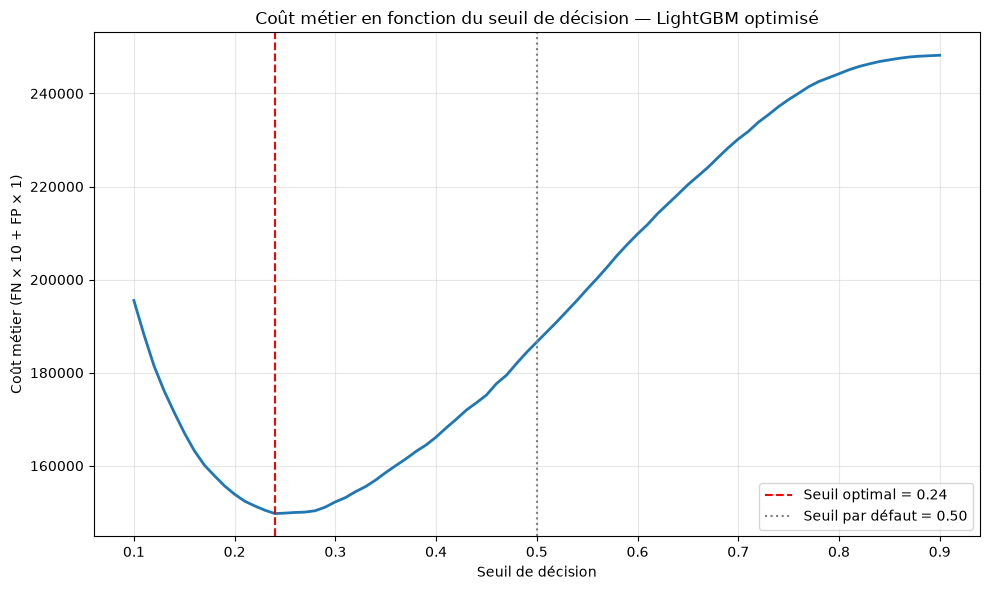


--- Au seuil optimal (0.24) ---
AUC (vraie, sur probabilités) = 0.7879
Accuracy  = 0.7238
Précision = 0.1848
Recall(1) = 0.7100
F1        = 0.2933
F2        = 0.4527
Coût métier = 149725


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                               f1_score, fbeta_score, accuracy_score)

# --- 1. Reconstruire le pipeline optimal et récupérer les probabilités out-of-fold ---
best_params = best_params = {
    'max_depth': 9,
    'num_leaves': 36,
    'n_estimators': 971,
    'learning_rate': 0.020671972085687516,
    'min_child_samples': 96,
    'scale_pos_weight': 3.8187894135879756,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

preprocessor = build_preprocessor(with_scaling=False)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(**best_params))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores, y_pred_proba_oof = evaluate_model_single_cv(pipeline, X, y, cv)

print(f"AUC (rappel, modèle optimisé) : {auc_scores.mean():.4f} (+/- {auc_scores.std():.4f})")

# --- 2. Métriques au seuil 0.5, pour compléter ce qui manquait ---
y_pred_05 = (y_pred_proba_oof >= 0.5).astype(int)
print(f"\n--- Au seuil 0.5 (référence, comme la baseline) ---")
print(f"Recall(1) = {recall_score(y, y_pred_05):.4f} | "
      f"F1 = {f1_score(y, y_pred_05):.4f} | "
      f"F2 = {fbeta_score(y, y_pred_05, beta=2):.4f} | "
      f"Coût métier = {business_cost(y, y_pred_05)}")

# --- 3. Tester les seuils de 0.10 à 0.90, par pas de 0.01 ---
thresholds = np.arange(0.10, 0.91, 0.01)
costs = []

for t in thresholds:
    y_pred_t = (y_pred_proba_oof >= t).astype(int)
    costs.append(business_cost(y, y_pred_t))

costs = np.array(costs)
best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

print(f"\n--- Seuil optimal ---")
print(f"Seuil optimal : {best_threshold:.2f}")
print(f"Coût métier minimal : {best_cost}")

# --- 4. Tracer la courbe coût vs seuil ---
plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Seuil optimal = {best_threshold:.2f}')
plt.axvline(0.5, color='grey', linestyle=':', label='Seuil par défaut = 0.50')
plt.xlabel('Seuil de décision')
plt.ylabel('Coût métier (FN × 10 + FP × 1)')
plt.title('Coût métier en fonction du seuil de décision — LightGBM optimisé')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/cost_vs_threshold.png', dpi=150)
plt.show()

# --- 5. Métriques complètes au seuil optimal ---
y_pred_optimal = (y_pred_proba_oof >= best_threshold).astype(int)
print(f"\n--- Au seuil optimal ({best_threshold:.2f}) ---")
print(f"AUC (vraie, sur probabilités) = {roc_auc_score(y, y_pred_proba_oof):.4f}")
print(f"Accuracy  = {accuracy_score(y, y_pred_optimal):.4f}")
print(f"Précision = {precision_score(y, y_pred_optimal):.4f}")
print(f"Recall(1) = {recall_score(y, y_pred_optimal):.4f}")
print(f"F1        = {f1_score(y, y_pred_optimal):.4f}")
print(f"F2        = {fbeta_score(y, y_pred_optimal, beta=2):.4f}")
print(f"Coût métier = {business_cost(y, y_pred_optimal)}")

Lien entre performance technique et performance métier

L'optimisation des hyperparamètres via Optuna (100 essais, pruning médian) a amélioré l'AUC de 0.7828 à 0.7879 — un gain technique mesurable, mais qui masque un effet secondaire important : le meilleur trial retient une pondération de classe (scale_pos_weight = 3.82) nettement inférieure au ratio réel du déséquilibre (11.39). Cette pondération plus faible déplace la distribution des probabilités prédites vers le bas pour la classe minoritaire, ce qui dégrade fortement les métriques calculées au seuil par défaut de 0.5 (Recall passant de 0.70 à 0.31, coût métier grimpant de 151 702 à 186 593) — une amélioration de l'AUC ne garantit donc pas, à elle seule, une meilleure décision opérationnelle si le seuil n'est pas recalibré en conséquence.

L'optimisation du seuil de décision, effectuée en balayant l'intervalle [0.10, 0.90] par pas de 0.01 sur les probabilités out-of-fold, révèle un seuil optimal à 0.24 (loin du 0.5 par défaut), minimisant le coût métier à 149 725 — un gain de 24.6% par rapport à une utilisation naïve du seuil par défaut sur ce même modèle, et même légèrement inférieur au coût de la baseline non optimisée. La courbe coût/seuil (forme en U) illustre ce compromis : en dessous de 0.24, le coût explose rapidement (trop de faux positifs, bons clients refusés) ; au-dessus, il augmente plus progressivement mais reste pénalisé par le poids ×10 des faux négatifs (défauts non détectés).

Conclusion : la performance technique brute (AUC) et la performance métier (coût) ne se lisent pas au même niveau — un modèle plus performant en AUC peut avoir un coût métier dégradé si son seuil n'est pas ajusté à sa propre calibration. C'est la combinaison optimisation d'hyperparamètres + optimisation du seuil, et non l'une des deux isolément, qui apporte le gain final le plus solide.

In [ ]:
def evaluate_train_vs_val(pipeline, X, y, cv):
    """
    Même CV que d'habitude, mais calcule l'AUC à la fois sur le train
    ET sur la validation de chaque fold, pour détecter un éventuel
    surapprentissage (écart important = le modèle mémorise plutôt qu'il généralise).
    """
    train_auc_per_fold = []
    val_auc_per_fold = []

    for train_idx, val_idx in cv.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        fold_pipeline = clone(pipeline)
        fold_pipeline.fit(X_train_fold, y_train_fold)

        train_proba = fold_pipeline.predict_proba(X_train_fold)[:, 1]
        val_proba = fold_pipeline.predict_proba(X_val_fold)[:, 1]

        train_auc_per_fold.append(roc_auc_score(y_train_fold, train_proba))
        val_auc_per_fold.append(roc_auc_score(y_val_fold, val_proba))

    return np.array(train_auc_per_fold), np.array(val_auc_per_fold)


# --- Application sur le modèle final optimisé ---
# best_params doit déjà exister (issu d'Optuna) — voir la remarque plus bas si tu repars de zéro
preprocessor = build_preprocessor(with_scaling=False)
pipeline_check = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(**best_params))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_auc, val_auc = evaluate_train_vs_val(pipeline_check, X, y, cv)
overfitting_gap = train_auc.mean() - val_auc.mean()

print(f"AUC train      : {train_auc.mean():.4f} (+/- {train_auc.std():.4f})")
print(f"AUC validation : {val_auc.mean():.4f} (+/- {val_auc.std():.4f})")
print(f"Écart (gap)    : {overfitting_gap:.4f}")

with mlflow.start_run(run_id=run_id):  # run_id du modèle LGBM optimisé
    mlflow.log_metric('train_auc_mean', train_auc.mean())
    mlflow.log_metric('val_auc_mean', val_auc.mean())
    mlflow.log_metric('overfitting_gap', overfitting_gap)

AUC train      : 0.8753 (+/- 0.0005)
AUC validation : 0.7879 (+/- 0.0034)
Écart (gap)    : 0.0874
🏃 View run LGBMClassifier_optuna_tuned at: http://127.0.0.1:5001/#/experiments/1/runs/e6b3e472ef9547b3b103bd28dffe4746
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


Le modèle final présente un écart de généralisation modéré (AUC train = 0.875, AUC validation = 0.788, gap = 0.087), révélant un certain surapprentissage. Ce résultat est cohérent avec la capacité du modèle retenue par optuna (num_leaves=36, n_estimators=971) : l'espace de recherche n'intégrait pas de pénalisation explicite de ce gap, seule l'AUC de validation étant optimisée. Ce point constitue une piste d'amélioration identifiée pour une itération future — par exemple en ajoutant une contrainte de régularisation supplémentaire (reg_alpha, reg_lambda) à l'espace de recherche Ooptuna, ou en réduisant num_leaves/n_estimators a posteriori pour vérifier l'impact sur ce gap.

Taille de l'échantillon : 5000
Proportion de défauts : 0.0808


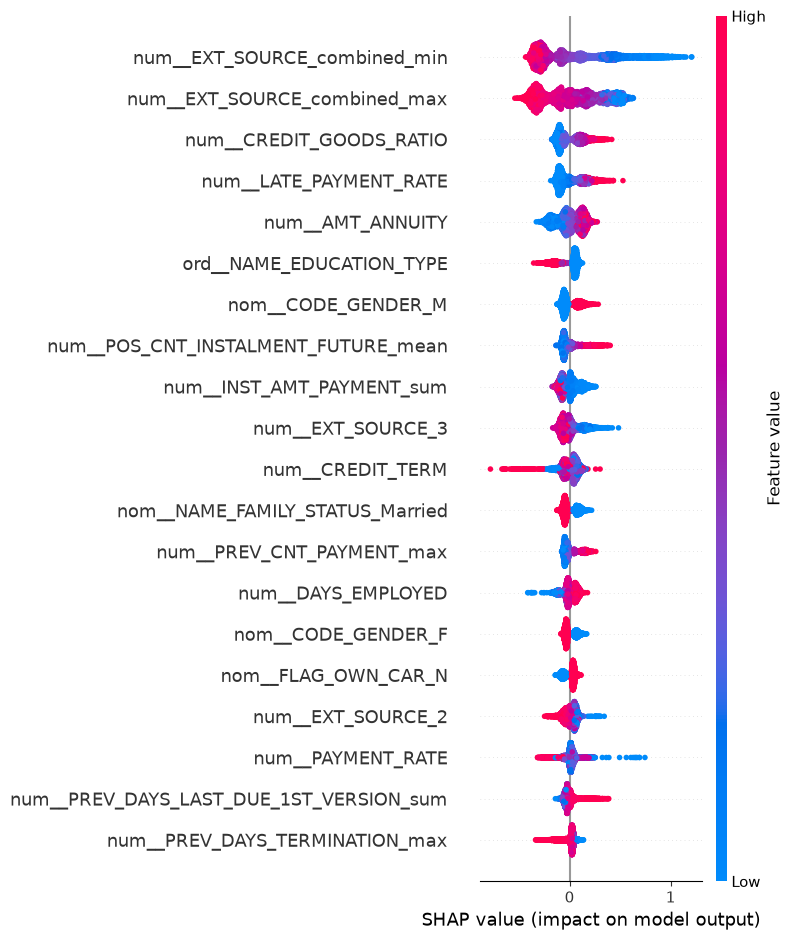

In [ ]:
from sklearn.model_selection import train_test_split
import shap

# --- 1. Échantillon stratifié (5000 clients, ~8%/92% respecté) ---
sample_idx, _ = train_test_split(
    np.arange(len(X)), train_size=5000, stratify=y, random_state=42
)
X_sample = X.iloc[sample_idx].reset_index(drop=True)
y_sample = y.iloc[sample_idx].reset_index(drop=True)

print(f"Taille de l'échantillon : {len(X_sample)}")
print(f"Proportion de défauts : {y_sample.mean():.4f}")

# --- 2. Préparer les données transformées ---
X_sample_transformed = final_pipeline.named_steps['preprocessor'].transform(X_sample)
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
X_sample_df = pd.DataFrame(X_sample_transformed, columns=feature_names)

# --- 3. Calcul des valeurs SHAP ---
explainer = shap.TreeExplainer(final_pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(X_sample_df)

# --- 4. Feature importance globale via SHAP ---
shap.summary_plot(shap_values, X_sample_df, show=False, max_display=20)
plt.tight_layout()
plt.savefig('/tmp/shap_summary_global.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Récupérer les probabilités prédites sur l'échantillon ---
proba_sample = final_pipeline.named_steps['classifier'].predict_proba(X_sample_df)[:, 1]

# --- Sélectionner un client à risque élevé et un client à risque faible ---
idx_high_risk = np.argmax(proba_sample)
idx_low_risk = np.argmin(proba_sample)

print(f"Client à risque élevé : index {idx_high_risk}, probabilité de défaut = {proba_sample[idx_high_risk]:.4f}")
print(f"Client à risque faible : index {idx_low_risk}, probabilité de défaut = {proba_sample[idx_low_risk]:.4f}")

Client à risque élevé : index 4369, probabilité de défaut = 0.9045
Client à risque faible : index 4727, probabilité de défaut = 0.0090


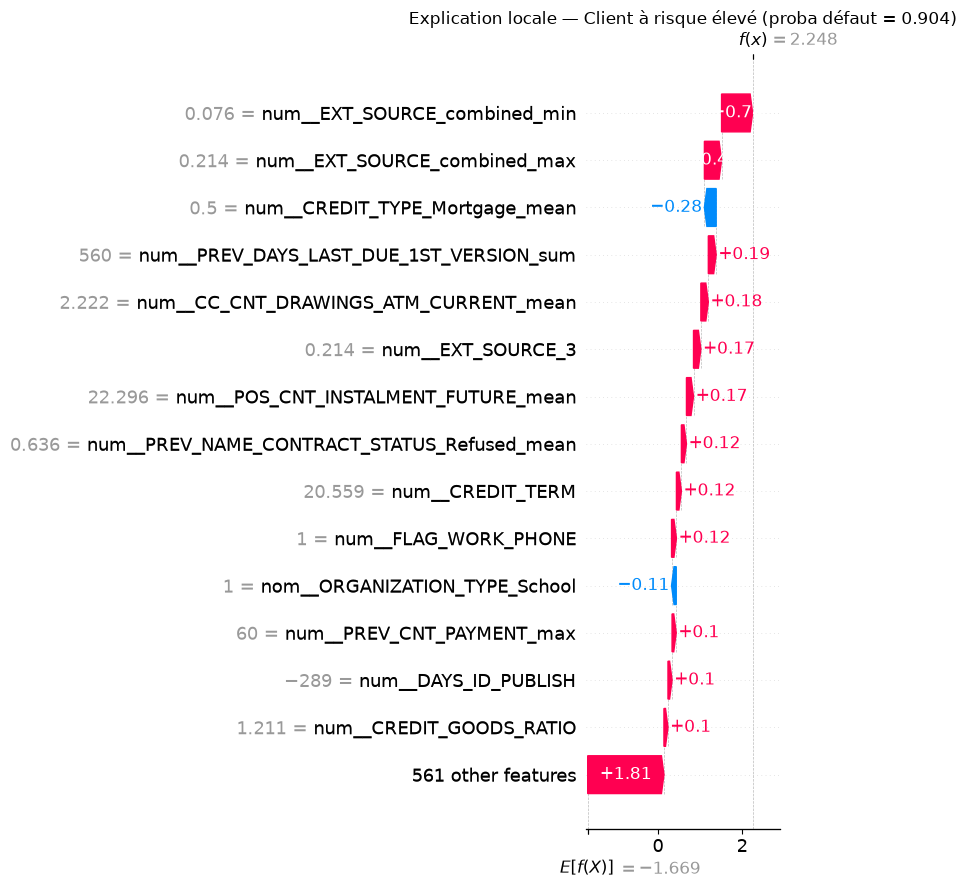

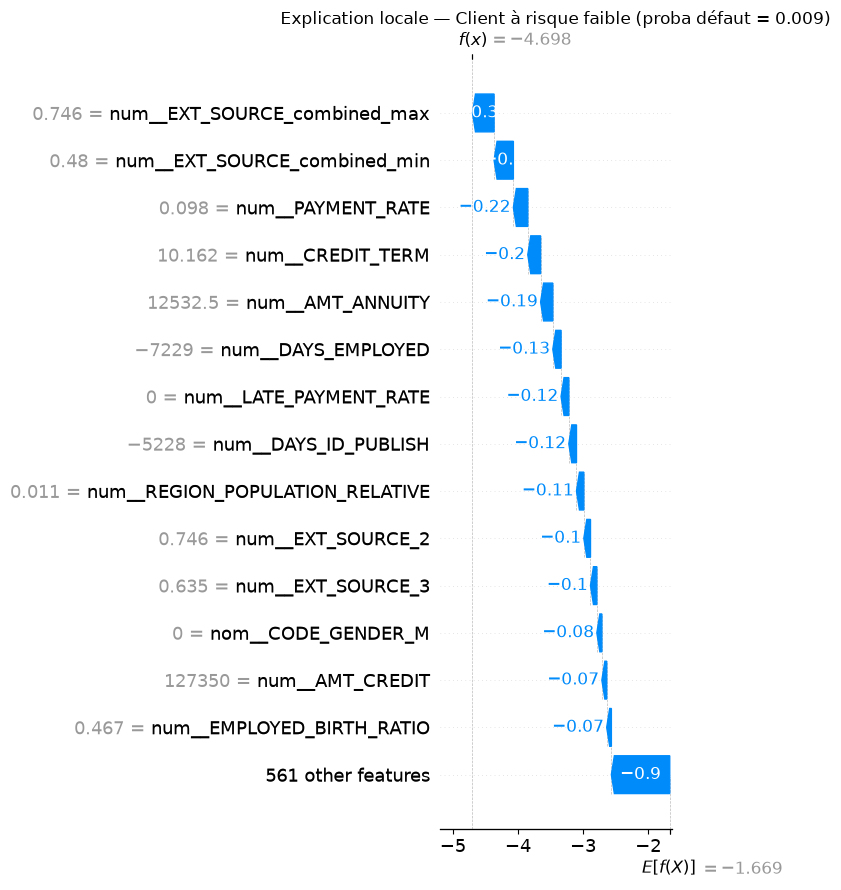

In [ ]:
import shap

# --- Client à risque élevé ---
explanation_high = shap.Explanation(
    values=shap_values[idx_high_risk],
    base_values=explainer.expected_value,
    data=X_sample_df.iloc[idx_high_risk],
    feature_names=feature_names
)
shap.plots.waterfall(explanation_high, max_display=15, show=False)
plt.title(f"Explication locale — Client à risque élevé (proba défaut = {proba_sample[idx_high_risk]:.3f})")
plt.tight_layout()
plt.savefig('/tmp/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Client à risque faible ---
explanation_low = shap.Explanation(
    values=shap_values[idx_low_risk],
    base_values=explainer.expected_value,
    data=X_sample_df.iloc[idx_low_risk],
    feature_names=feature_names
)
shap.plots.waterfall(explanation_low, max_display=15, show=False)
plt.title(f"Explication locale — Client à risque faible (proba défaut = {proba_sample[idx_low_risk]:.3f})")
plt.tight_layout()
plt.savefig('/tmp/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Vérifier le sens exact des 3 premières contributions du client à risque élevé
for i in np.argsort(np.abs(shap_values[idx_high_risk]))[::-1][:5]:
    print(f"{feature_names[i]} : SHAP value = {shap_values[idx_high_risk][i]:.4f}, valeur réelle = {X_sample_df.iloc[idx_high_risk][i]:.4f}")

num__EXT_SOURCE_combined_min : SHAP value = 0.7375, valeur réelle = 0.0757
num__EXT_SOURCE_combined_max : SHAP value = 0.4078, valeur réelle = 0.2140
num__CREDIT_TYPE_Mortgage_mean : SHAP value = -0.2797, valeur réelle = 0.5000
num__PREV_DAYS_LAST_DUE_1ST_VERSION_sum : SHAP value = 0.1864, valeur réelle = 560.0000
num__CC_CNT_DRAWINGS_ATM_CURRENT_mean : SHAP value = 0.1771, valeur réelle = 2.2222


L'analyse SHAP locale confirme la cohérence du modèle avec l'intuition métier. Pour le client au risque le plus élevé (probabilité de défaut = 0.904), la contribution dominante provient des scores de solvabilité externes : EXT_SOURCE_combined_min (+0.74) et EXT_SOURCE_combined_max (+0.41) — les trois bureaux externes s'accordent sur un profil de risque, sans signal contradictoire entre eux. Ces deux variables construites lors du feature engineering expliquent à elles seules plus de la moitié de l'écart entre le score moyen du portefeuille et le score de ce client. À l'inverse, le client au risque le plus faible (probabilité = 0.009) présente un historique de paiement irréprochable et des scores externes élevés et convergents. Cette granularité d'explication, complémentaire à la feature importance globale, permet de justifier individuellement chaque décision du modèle — répondant à l'exigence de transparence formulée par la direction.

In [ ]:
import mlflow

mlflow.set_tracking_uri('http://127.0.0.1:5001')

# Récupérer le run du modèle optimisé pour y rattacher les artefacts SHAP
run_id = "16bb610f229d45caa45091c0f76cc9d6"  # run LGBMClassifier_optuna_tuned

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact('/tmp/shap_summary_global.png', artifact_path='shap_explanations')
    mlflow.log_artifact('/tmp/shap_waterfall_high_risk.png', artifact_path='shap_explanations')
    mlflow.log_artifact('/tmp/shap_waterfall_low_risk.png', artifact_path='shap_explanations')

    mlflow.log_param('shap_sample_size', 5000)
    mlflow.log_param('shap_explainer_type', 'TreeExplainer')
    mlflow.log_metric('shap_high_risk_client_proba', float(proba_sample[idx_high_risk]))
    mlflow.log_metric('shap_low_risk_client_proba', float(proba_sample[idx_low_risk]))

print("Artefacts SHAP loggés avec succès sur le run", run_id)

🏃 View run LGBMClassifier_optuna_tuned at: http://127.0.0.1:5001/#/experiments/1/runs/16bb610f229d45caa45091c0f76cc9d6
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
Artefacts SHAP loggés avec succès sur le run 16bb610f229d45caa45091c0f76cc9d6


In [ ]:
from mlflow import MlflowClient

client = MlflowClient(tracking_uri='http://127.0.0.1:5001')

client.update_model_version(
    name="home_credit_scoring_model",
    version=1,
    description=(
        "Modèle LightGBM optimisé via Optuna (100 trials) pour le scoring crédit "
        "Home Credit Default Risk. AUC=0.7879, seuil de décision optimisé à 0.24 "
        "(coût métier minimal=149725, FN pondéré x10 vs FP). "
        "Pipeline complet incluant imputation, encodage et gestion du déséquilibre "
        "de classe (scale_pos_weight)."
    )
)

client.set_model_version_tag(
    name="home_credit_scoring_model",
    version=1,
    key="stage_validation",
    value="baseline_ready"
)
client.set_model_version_tag(
    name="home_credit_scoring_model",
    version=1,
    key="business_cost",
    value="149725"
)